# BT4012 Kaggle Group 10: Health Insurance Fraud Detection
**Author:** (e1122416), Quek Ying Han Clare (e1156061), Eunice Gong Shi Min (e1155847)  
**Course:** BT4012  
**Institution:** National University of Singapore  
**Date:** November 2025

## Project Overview

This notebook presents a comprehensive approach to healthcare provider fraud detection using machine learning techniques. The goal is to classify healthcare providers as either fraudulent or non-fraudulent based on claims, beneficiary, and provider data.

**Dataset Context:**
- **Training data**: Historical claims, provider information, and beneficiary details with fraud labels  
- **Test data**: Unlabeled provider or claim records requiring fraud prediction  
- **Target variable**: Binary (0 = Non-Fraudulent, 1 = Fraudulent)  
- **Evaluation metric**: ROC AUC (Area Under the Curve), Precision, Recall, and F1-Score  

**Key Features:**
- Provider demographic and specialty information  
- Claims data (inpatient/outpatient claims, claim amounts, procedure codes)  
- Beneficiary information (age, gender, chronic conditions, number of visits)  
- Aggregated statistics per provider (average claim amount, claim frequency, diagnosis/procedure diversity)  

**Project Goals:**
1. Perform exploratory data analysis (EDA) to understand patterns and detect anomalies in claims and provider behavior.  
2. Engineer meaningful features to capture provider behavior trends and risk factors.  
3. Train and evaluate supervised machine learning models (e.g., Logistic Regression, Random Forest, XGBoost) to predict provider fraud.  
4. Implement interpretability techniques (e.g., SHAP values) to identify key features driving fraud predictions.  
5. Explore anomaly detection and unsupervised approaches to detect potential fraud not labeled in the dataset.  
6. Provide actionable insights for healthcare providers and insurers to mitigate fraudulent activities.

## Computational Dependencies & Dependencies

In [19]:
# Data manipulation
import numpy as np
import pandas as pd

# Machine learning models and preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Visualization
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Configure matplotlib to avoid font warnings
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans', 'sans-serif']
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')
warnings.filterwarnings('ignore', message='.*findfont.*')

# Utilities
from tqdm import tqdm
import joblib
from pathlib import Path


## Load datasets
### Taken from Kaggle
**A) Inpatient Data**

This data provides insights about the claims filed for those patients who are admitted in the hospitals. It also provides additional details like their admission and discharge dates and admit d diagnosis code.

**B) Outpatient Data**

This data provides details about the claims filed for those patients who visit hospitals and not admitted in it.

**C) Beneficiary Details Data**

This data contains beneficiary KYC details like health conditions,regioregion they belong to etc.

In [45]:
print("=" * 80)
print("LOADING DATASETS")
print("=" * 80)

data_dir = Path("data")

# Define file paths
train_bene_path = data_dir / "Train_Beneficiarydata-1542865627584.csv"
train_inp_path  = data_dir / "Train_Inpatientdata-1542865627584.csv"
train_out_path  = data_dir / "Train_Outpatientdata-1542865627584.csv"
train_lbl_path  = data_dir / "Train-1542865627584.csv"

test_bene_path  = data_dir / "Test_Beneficiarydata-1542969243754.csv"
test_inp_path   = data_dir / "Test_Inpatientdata-1542969243754.csv"
test_out_path   = data_dir / "Test_Outpatientdata-1542969243754.csv"
test_lbl_path   = data_dir / "Test-1542969243754.csv"

print("\n Loading Training Data...")
train_beneficiary = pd.read_csv(train_bene_path)
print(f"   ✓ Beneficiary: {train_beneficiary.shape}")
train_inpatient = pd.read_csv(train_inp_path)
print(f"   ✓ Inpatient: {train_inpatient.shape}")
train_outpatient = pd.read_csv(train_out_path)
print(f"   ✓ Outpatient: {train_outpatient.shape}")
train_labels = pd.read_csv(train_lbl_path)
print(f"   ✓ Labels: {train_labels.shape}")

print("\n Loading Test Data...")
test_beneficiary = pd.read_csv(test_bene_path)
print(f"   ✓ Beneficiary: {test_beneficiary.shape}")
test_inpatient = pd.read_csv(test_inp_path)
print(f"   ✓ Inpatient: {test_inpatient.shape}")
test_outpatient = pd.read_csv(test_out_path)
print(f"   ✓ Outpatient: {test_outpatient.shape}")
test_labels = pd.read_csv(test_lbl_path)
print(f"   ✓ Labels: {test_labels.shape}")

print("\n" + "=" * 80)
print("✅ ALL DATASETS LOADED SUCCESSFULLY")
print("=" * 80)

LOADING DATASETS

 Loading Training Data...
   ✓ Beneficiary: (138556, 25)
   ✓ Inpatient: (40474, 30)
   ✓ Outpatient: (517737, 27)
   ✓ Labels: (5410, 2)

 Loading Test Data...
   ✓ Beneficiary: (63968, 25)
   ✓ Inpatient: (9551, 30)
   ✓ Outpatient: (125841, 27)
   ✓ Labels: (1353, 1)

✅ ALL DATASETS LOADED SUCCESSFULLY


## Data Cleaning

Cleaned data into 2 final datasets -> `train_merged` and `test_merged`


### Imports and Helpers

In [21]:
# --- general cleaning helpers ---
def normalize_columns(df):
    df = df.copy()
    df.columns = (
        df.columns.str.strip()
        .str.replace(r"\s+", "_", regex=True)
        .str.replace(r"[^\w_]", "", regex=True)
        .str.lower()
    )
    return df

def parse_dates_in_df(df):
    """Convert any column with 'date', 'dt', 'dob', 'dod', etc. to datetime."""
    df = df.copy()
    date_like = ["dt", "date", "dob", "dod", "claimstart", "claimend", "admission", "discharge"]
    for col in df.columns:
        if any(k in col for k in date_like):
            # Modern pandas: infer format automatically (no need for infer_datetime_format)
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df


def strip_strings(df):
    df = df.copy()
    for c in df.select_dtypes(include="object"):
        df[c] = df[c].astype(str).str.strip().replace({"": np.nan, "nan": np.nan, "NaN": np.nan})
    return df

def convert_binary_to_numeric(df):
    """Convert binary Yes/No, Y/N values to 1/0 for machine learning."""
    df = df.copy()
    binary_mapping = {
        'Yes': 1, 'yes': 1, 'YES': 1, 'Y': 1, 'y': 1,
        'No': 0, 'no': 0, 'NO': 0, 'N': 0, 'n': 0
    }
    
    converted_cols = []
    for col in df.columns:
        if df[col].dtype == 'object':
            # Check if column contains only Yes/No values (ignoring NaN)
            unique_vals = df[col].dropna().unique()
            if len(unique_vals) > 0 and all(str(val).strip() in binary_mapping for val in unique_vals):
                df[col] = df[col].map(lambda x: binary_mapping.get(str(x).strip(), x) if pd.notna(x) else x)
                converted_cols.append(col)
    
    if converted_cols:
        print(f"  ✓ Converted {len(converted_cols)} binary columns to 1/0: {', '.join(converted_cols[:5])}{('...' if len(converted_cols) > 5 else '')}")
    
    return df

def coerce_numeric(df):
    df = df.copy()
    for c in df.columns:
        if df[c].dtype == "object":
            s = df[c].dropna().astype(str).head(100)
            if len(s) and (s.str.match(r"^-?\d+(\.\d+)?$").mean() > 0.7):
                df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def deduplicate(df, key_cols=None):
    df = df.copy()
    before = len(df)
    if key_cols:
        df = df.drop_duplicates(subset=key_cols, keep="first")
    else:
        df = df.drop_duplicates(keep="first")
    print(f"Removed {before-len(df)} duplicates")
    return df


### Clean Individual Files

How we cleaned:
- `normalize_columns(df)` -> Standardise column names for consistency and easy reference
    - Removes leading/training spaces in column names
    - Replaces spaces with underscores ('Claim Start Date' -> 'claim_start_date')
    - Removes special characters (like /, -, (, ))
    - Converts everything to lowercase
- `parse_dates_in_df(df)` -> Detect and convert all date-like columns into proper datetime objects
    - Looks for the respective columns and uses pd.to_datetime, to convert them
- `strip_strings(df)` -> Clean up messy text columns
    - Trims extra spaces from the start/end of strings
    - Converts empty strings ot text versions of NaN into real missy values
- `convert_binary_to_numeric(df)` -> Convert binary Yes/No values to 1/0
    - Detects columns containing only Yes/No (and variations like YES/yes/Y/y/N/n)
    - Maps Yes → 1, No → 0 for machine learning compatibility
    - Preserves NaN values
- `coerce_numeric(df)` -> Find columns that look numeric but are stored as strings, and convert them
    - Sees if most values match a numeric regex
    - If more than 70% look numeric, convert the whole column to float or int
-  `deduplicate(df)` -> Remove duplicate rows

In [ ]:
def clean_dataframe(df, key_cols=None):
    print(f"\n{'=' * 70}")
    print(f"🧹 Cleaning DataFrame")
    print(f"{'=' * 70}")
    print(f"Input shape: {df.shape}")
    
    print(f"Normalizing column names...")
    df = normalize_columns(df)
    
    print(f"Stripping string whitespace...")
    df = strip_strings(df)
    
    print(f"Parsing date columns...")
    df = parse_dates_in_df(df)
    
    print(f"Converting binary Yes/No to 1/0...")
    df = convert_binary_to_numeric(df)
    
    print(f"Converting numeric columns...")
    df = coerce_numeric(df)
    
    print(f"Removing duplicates...")
    df = deduplicate(df, key_cols)
    
    print(f"Output shape: {df.shape}")
    print(f"{'=' * 70}\n")
    return df

print("\n" + "=" * 80)
print("DATA CLEANING PROCESS")
print("=" * 80)

print("\n"  + "-" * 35 + " TRAINING DATA " + "-" * 35)
train_bene = clean_dataframe(train_beneficiary, ["beneid"])
train_inp  = clean_dataframe(train_inpatient, ["claimid"])
train_out  = clean_dataframe(train_outpatient, ["claimid"])
train_lbl  = clean_dataframe(train_labels)

print("\n" + "-" * 35 + " TEST DATA " + "-" * 38)
test_bene  = clean_dataframe(test_beneficiary, ["beneid"])
test_inp   = clean_dataframe(test_inpatient, ["claimid"])
test_out   = clean_dataframe(test_outpatient, ["claimid"])
test_lbl   = clean_dataframe(test_labels)

print("\n" + "=" * 80)
print("✅ DATA CLEANING COMPLETE")
print("=" * 80)


🔧 DATA CLEANING PROCESS

🚂 ----------------------------------- TRAINING DATA -----------------------------------

🧹 Cleaning DataFrame
📥 Input shape: (138556, 25)
  ⚙️  Normalizing column names...
  ⚙️  Stripping string whitespace...
  ⚙️  Parsing date columns...
  ⚙️  Converting binary Yes/No to 1/0...
  ⚙️  Converting numeric columns...
  ⚙️  Removing duplicates...
Removed 0 duplicates
📤 Output shape: (138556, 25)


🧹 Cleaning DataFrame
📥 Input shape: (40474, 30)
  ⚙️  Normalizing column names...
  ⚙️  Stripping string whitespace...
  ⚙️  Parsing date columns...
  ⚙️  Converting binary Yes/No to 1/0...
  ⚙️  Converting numeric columns...
  ⚙️  Removing duplicates...
Removed 0 duplicates
📤 Output shape: (40474, 30)


🧹 Cleaning DataFrame
📥 Input shape: (517737, 27)
  ⚙️  Normalizing column names...
  ⚙️  Stripping string whitespace...
  ⚙️  Parsing date columns...
  ⚙️  Converting binary Yes/No to 1/0...
  ⚙️  Converting numeric columns...
  ⚙️  Removing duplicates...
Removed 0 dupli

### Merge train/test claims with beneficiaries

In [ ]:
def _normalize_cols(df):
    """Lowercase & strip all column names for consistent joins."""
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower()
    return df

def _clean_key(s):
    """Make join keys consistent (string, trimmed)."""
    return s.astype(str).str.strip()

def safe_merge(left, right, on, how="left", validate=None):
    """Wrapper to merge with safe suffix and optional validation."""
    return left.merge(
        right,
        on=on,
        how=how,
        suffixes=("", "_r"),
        validate=validate
    )

def merge_claims(inp, out, bene, prov_labels=None):
    """
    Create a unified claims dataframe:
      - concat inpatient & outpatient rows
      - left-join beneficiary on 'beneid'
      - (optional) left-join provider labels on 'provider' (many claims -> one label)

    Expected keys (lowercase): 'claimid', 'beneid', 'provider'
    """
    # --- normalize columns ---
    inp  = _normalize_cols(inp)
    out  = _normalize_cols(out)
    bene = _normalize_cols(bene)
    if prov_labels is not None:
        prov_labels = _normalize_cols(prov_labels)

    # --- build claims: union of columns, row-wise concat ---
    claims = pd.concat([inp, out], ignore_index=True, sort=False)

    # --- clean join keys present ---
    for key in ['claimid', 'beneid', 'provider']:
        if key in claims.columns:
            claims[key] = _clean_key(claims[key])
        if key in bene.columns:
            bene[key] = _clean_key(bene[key])
        if prov_labels is not None and key in getattr(prov_labels, 'columns', []):
            prov_labels[key] = _clean_key(prov_labels[key])

    # --- join beneficiary ---
    if 'beneid' in claims.columns and 'beneid' in bene.columns:
        claims = safe_merge(claims, bene, on=['beneid'], how='left', validate='many_to_one')

    # --- join provider labels (train only) ---
    if prov_labels is not None:
        # keep only provider + label, drop dups (one label per provider)
        label_cols = ['provider', 'potentialfraud']
        missing = [c for c in label_cols if c not in prov_labels.columns]
        if missing:
            raise ValueError(f"prov_labels is missing required columns: {missing}")

        prov_lab = (
            prov_labels[label_cols]
            .drop_duplicates(subset=['provider'])
        )
        claims = safe_merge(
            claims, prov_lab,
            on=['provider'],
            how='left',
            validate='many_to_one'  # many claims map to one provider label
        )

    return claims

print("\n" + "=" * 80)
print("MERGING CLAIMS WITH BENEFICIARIES")
print("=" * 80)

# === Use it correctly ===
# Train gets labels; Test does NOT.
print("\nCreating merged training dataset...")
train_merged = merge_claims(train_inp, train_out, train_bene, prov_labels=train_lbl)
print(f"✓ train_merged shape: {train_merged.shape[0]:,} rows × {train_merged.shape[1]} columns")

print("\nCreating merged test dataset...")
test_merged  = merge_claims(test_inp,  test_out,  test_bene,  prov_labels=None)
print(f"✓ test_merged shape: {test_merged.shape[0]:,} rows × {test_merged.shape[1]} columns")

# Quick sanity: do we have labels only in train?
print("\n" + "-" * 80)
print("Sanity Checks:")
print("-" * 80)
print(f"✓ PotentialFraud in train_merged? {('potentialfraud' in train_merged.columns)}")
if 'potentialfraud' in train_merged.columns:
    print(f"\nTarget Distribution in Training Data:")
    fraud_counts = train_merged['potentialfraud'].value_counts(dropna=False)
    for label, count in fraud_counts.items():
        pct = (count / len(train_merged) * 100)
        print(f"   {label}: {count:,} ({pct:.2f}%)")

print(f"\n✓ PotentialFraud in test_merged? {('potentialfraud' in test_merged.columns)}")

print("\nColumns in merged dataset:")
print(f"   {', '.join(train_merged.columns.tolist()[:10])}...")
print(f"   (Total: {len(train_merged.columns)} columns)")

print("\n" + "=" * 80)
print("MERGE COMPLETE")
print("=" * 80)


🔗 MERGING CLAIMS WITH BENEFICIARIES

📊 Creating merged training dataset...
✓ train_merged shape: 558,211 rows × 55 columns

📊 Creating merged test dataset...
✓ test_merged shape: 135,392 rows × 54 columns

--------------------------------------------------------------------------------
🔍 Sanity Checks:
--------------------------------------------------------------------------------
✓ PotentialFraud in train_merged? True

📈 Target Distribution in Training Data:
   0: 345,415 (61.88%)
   1: 212,796 (38.12%)

✓ PotentialFraud in test_merged? False

📋 Columns in merged dataset:
   beneid, claimid, claimstartdt, claimenddt, provider, inscclaimamtreimbursed, attendingphysician, operatingphysician, otherphysician, admissiondt...
   (Total: 55 columns)

✅ MERGE COMPLETE


## EDA

### Set up and helpers

In [ ]:
# EDA helpers: no extra installs; uses pandas + matplotlib only
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

def print_header(text, width=80, char="="):
    """Print a centered, decorated header."""
    padding = (width - len(text) - 2) // 2
    print(f"\n{char * padding} {text} {char * padding}")

def print_subheader(text, width=80, char="-"):
    """Print a sub-section header."""
    print(f"\n{char * 10} {text} {char * 10}")

def pct_missing(s: pd.Series) -> float:
    return 100.0 * s.isna().mean()

def top_missing(df: pd.DataFrame, k: int = 20) -> pd.DataFrame:
    miss = df.isna().mean().sort_values(ascending=False)*100
    return miss.round(2).head(k).rename("missing_%").to_frame()

def date_ranges(df: pd.DataFrame) -> pd.DataFrame:
    # scan for datetime64 cols and return min/max
    dates = [c for c in df.columns if np.issubdtype(df[c].dtype, np.datetime64)]
    rows = []
    for c in dates:
        rows.append({
            "column": c,
            "min": df[c].min(),
            "max": df[c].max(),
            "missing_%": round(pct_missing(df[c]), 2),
        })
    return pd.DataFrame(rows).sort_values("column") if rows else pd.DataFrame(columns=["column","min","max","missing_%"])

def dtype_summary(df: pd.DataFrame) -> pd.DataFrame:
    dtypes = df.dtypes.astype(str).value_counts().rename("count").to_frame()
    dtypes["pct"] = (100 * dtypes["count"] / dtypes["count"].sum()).round(1)
    return dtypes

def categorical_columns(df: pd.DataFrame, max_unique: int = 30) -> list:
    cats = []
    for c in df.columns:
        if df[c].dtype == "object" or (df[c].dtype.name.startswith("category")):
            cats.append(c)
        else:
            # treat low-cardinality numerics as categorical too
            nun = df[c].nunique(dropna=True)
            if pd.api.types.is_integer_dtype(df[c]) and nun <= max_unique:
                cats.append(c)
    return cats

def numeric_columns(df: pd.DataFrame) -> list:
    return [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

def eda_report(df: pd.DataFrame, name: str, sample_hist: int = 12):
    print_header(f"{name.upper()}", width=80, char="=")
    print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
    print(f"Duplicate rows: {df.duplicated().sum()}")

    # dtypes overview
    print_subheader("Data Types Summary")
    display(dtype_summary(df))

    # missingness
    print_subheader("Top Missing Columns (Top 20)")
    display(top_missing(df, k=20))

    # date ranges
    dr = date_ranges(df)
    if len(dr):
        print_subheader("Date Ranges")
        display(dr)

    # basic describe
    num_cols = numeric_columns(df)
    if num_cols:
        print_subheader("Numeric Variables Summary")
        display(df[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

    cat_cols = categorical_columns(df)
    if cat_cols:
        print_subheader("Categorical Variables (Top 10 Columns)")
        for c in cat_cols[:10]:
            vc = df[c].value_counts(dropna=False).head(10)
            print(f"\n[{c}] - Top Values:")
            display(vc)

    # correlation (quick)
    if len(num_cols) >= 2:
        print_subheader("Numeric Correlation Matrix (Pearson)")
        corr = df[num_cols].corr(numeric_only=True)
        display(corr)

        # small heatmap for top-k numeric cols by variance
        topk = df[num_cols].var().sort_values(ascending=False).head(min(15, len(num_cols))).index
        plt.figure(figsize=(6, 5))
        plt.imshow(df[topk].corr(), interpolation="nearest", cmap="coolwarm")
        plt.title(f"{name}: Correlation Heatmap (Top Variance Features)", fontsize=12, fontweight='bold')
        plt.xticks(range(len(topk)), topk, rotation=90, fontsize=8)
        plt.yticks(range(len(topk)), topk, fontsize=8)
        plt.colorbar(label='Correlation')
        plt.tight_layout()
        plt.show()
    
    print("=" * 80 + "\n")

def target_report(df: pd.DataFrame, target_col: str = "potentialfraud"):
    if target_col in df.columns:
        print_header(f"TARGET VARIABLE: {target_col.upper()}", width=80, char="=")
        vc = df[target_col].value_counts(dropna=False)
        pct = (vc / vc.sum() * 100).round(2)
        target_df = pd.DataFrame({"count": vc, "percentage (%)": pct})
        print(f"\nDistribution of {target_col}:")
        display(target_df)
        
        plt.figure(figsize=(8, 5))
        ax = vc.plot(kind="bar", color=['#2ecc71', '#e74c3c'])
        plt.title(f"Distribution of {target_col}", fontsize=14, fontweight='bold', pad=20)
        plt.xlabel(target_col, fontsize=11)
        plt.ylabel("Count", fontsize=11)
        plt.xticks(rotation=0)
        
        # Add value labels on bars
        for i, v in enumerate(vc):
            ax.text(i, v + max(vc)*0.01, f'{v:,}\n({pct.iloc[i]}%)', 
                   ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        print("=" * 80 + "\n")
    else:
        print(f"⚠️  Target column '{target_col}' not found in dataframe")

### Run on the cleaned tables


🔬 EXPLORATORY DATA ANALYSIS - INDIVIDUAL TABLES

🚂 =================================== TRAINING DATA ===================================

============================== TRAIN_BENEFICIARY ==============================
📊 Shape: 138,556 rows x 25 columns
🔍 Duplicate rows: 0

---------- Data Types Summary ----------


,count,pct
int64,21,84.0
datetime64[ns],2,8.0
object,1,4.0
float64,1,4.0



---------- Top Missing Columns (Top 20) ----------


,missing_%
dod,98.97
renaldiseaseindicator,14.13
beneid,0.00
chroniccond_obstrpulmonary,0.00
opannualreimbursementamt,0.00
ipannualdeductibleamt,0.00
ipannualreimbursementamt,0.00
chroniccond_stroke,0.00
chroniccond_rheumatoidarthritis,0.00
chroniccond_osteoporasis,0.00



---------- Date Ranges ----------


...

chroniccond_cancer
2    121935
1     16621
Name: count, dtype: int64


📌 [chroniccond_obstrpulmonary] - Top Values:


chroniccond_obstrpulmonary
2    105697
1     32859
Name: count, dtype: int64


---------- Numeric Correlation Matrix (Pearson) ----------


,gender,race,renaldiseaseindicator,state,county,noofmonths_partacov,noofmonths_partbcov,chroniccond_alzheimer,chroniccond_heartfailure,chroniccond_kidneydisease,chroniccond_cancer,chroniccond_obstrpulmonary,chroniccond_depression,chroniccond_diabetes,chroniccond_ischemicheart,chroniccond_osteoporasis,chroniccond_rheumatoidarthritis,chroniccond_stroke,ipannualreimbursementamt,ipannualdeductibleamt,opannualreimbursementamt,opannualdeductibleamt
gender,1.000000,0.002007,NaN,0.006893,0.004328,0.010458,0.010227,-0.017997,-0.008754,-0.005936,0.013080,-0.011717,-0.021261,-0.021193,-0.005754,-0.018978,-0.013450,-0.002649,0.001782,-0.000235,0.007061,0.007625
race,0.002007,1.000000,NaN,-0.049890,-0.003733,-0.005861,-0.002314,-0.000040,0.004511,-0.000500,0.013700,0.004945,-0.007103,0.002240,0.012074,0.007452,0.003813,0.003988,-0.003996,-0.004254,0.004534,0.001040
renaldiseaseindicator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,0.006893,-0.049890,NaN,1.000000,0.130760,-0.001929,0.002039,0.000013,-0.001845,-0.001041,0.005807,-0.001066,-0.001205,0.001263,-0.000245,0.001195,0.002377,0.001879,-0.000945,-0.004090,-0.001934,-0.002477
county,0.004328,-0.003733,NaN,0.130760,1.000000,0.008324,0.007647,-0.009674,-0.009122,-0.011088,-0.000427,-0.007865,-0.009197,-0.006310,-0.007747,-0.006901,-0.004349,-0.001237,0.001527,0.002320,0.005160,0.005083
noofmonths_partacov,0.010458,-0.005861,NaN,-0.001929,0.008324,1.000000,0.240054,-0.021567,-0.022369,-0.019437,-0.005501,-0.017210,-0.020395,-0.035544,-0.025002,-0.013483,-0.018906,-0.006938,-0.001053,0.004705,0.011525,0.013331
noofmonths_partbcov,0.010227,-0.002314,NaN,0.002039,0.007647,0.240054,1.000000,-0.021601,-0.031268,-0.027689,-0.013597,-0.021273,-0.023517,-0.045891,-0.043540,-0.024469,-0.023054,-0.012684,0.003607,0.008353,0.017700,0.020778
chroniccond_alzheimer,-0.017997,-0.000040,NaN,0.000013,-0.009674,-0.021567,-0.021601,1.000000,0.201979,0.197602,0.057621,0.181314,0.181980,0.205691,0.170700,0.090578,0.106438,0.133754,-0.126100,-0.157013,-0.091980,-0.097755
chroniccond_heartfailure,-0.008754,0.004511,NaN,-0.001845,-0.009122,-0.022369,-0.031268,0.201979,1.000000,0.309772,0.086930,0.264398,0.171250,0.289730,0.289732,0.101362,0.145553,0.141573,-0.181765,-0.195562,-0.147488,-0.152361
chroniccond_kidneydisease,-0.005936,-0.000500,NaN,-0.001041,-0.011088,-0.019437,-0.027689,0.197602,0.309772,1.000000,0.116531,0.261096,0.177609,0.314921,0.249356,0.104806,0.160158,0.151812,-0.270505,-0.271754,-0.206305,-0.214022


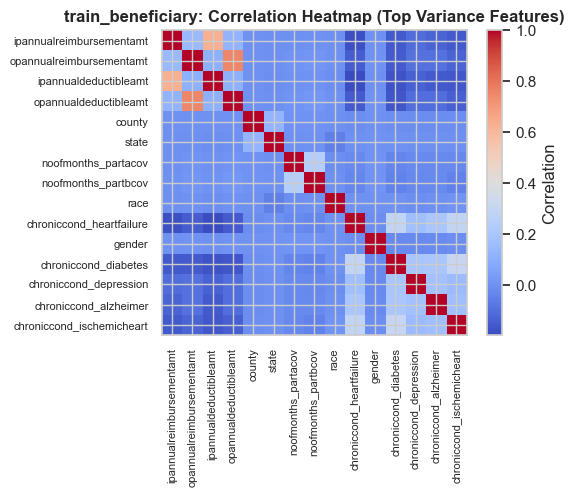



=============================== TRAIN_INPATIENT ===============================
📊 Shape: 40,474 rows x 30 columns
🔍 Duplicate rows: 0

---------- Data Types Summary ----------


,count,pct
float64,19,63.3
object,6,20.0
datetime64[ns],4,13.3
int64,1,3.3



---------- Top Missing Columns (Top 20) ----------


,missing_%
clmprocedurecode_6,100.00
clmprocedurecode_5,99.98
clmprocedurecode_4,99.71
clmprocedurecode_3,97.62
clmdiagnosiscode_10,91.43
otherphysician,88.41
clmprocedurecode_2,86.52
clmprocedurecode_1,42.81
operatingphysician,41.12
clmdiagnosiscode_9,40.58



---------- Date Ranges ----------


...

operatingphysician
NaN          16644
PHY429430      225
PHY341560      153
PHY411541      121
PHY352941      110
PHY314410      109
PHY362864      107
PHY429828      104
PHY430367      101
PHY395464      100
Name: count, dtype: int64


📌 [otherphysician] - Top Values:


otherphysician
NaN          35784
PHY416093       81
PHY333406       38
PHY429929       30
PHY423728       29
PHY361563       29
PHY328051       24
PHY361104       23
PHY399458       22
PHY392443       20
Name: count, dtype: int64


---------- Numeric Correlation Matrix (Pearson) ----------


,inscclaimamtreimbursed,clmadmitdiagnosiscode,deductibleamtpaid,diagnosisgroupcode,clmdiagnosiscode_1,clmdiagnosiscode_2,clmdiagnosiscode_3,clmdiagnosiscode_4,clmdiagnosiscode_5,clmdiagnosiscode_6,clmdiagnosiscode_7,clmdiagnosiscode_8,clmdiagnosiscode_9,clmdiagnosiscode_10,clmprocedurecode_1,clmprocedurecode_2,clmprocedurecode_3,clmprocedurecode_4,clmprocedurecode_5,clmprocedurecode_6
inscclaimamtreimbursed,1.000000,0.007322,NaN,0.027383,0.036256,0.018770,0.023157,0.023024,0.009320,0.007581,0.003827,0.017981,0.011712,-0.014252,-0.146004,0.108392,0.134871,-0.087345,0.662121,NaN
clmadmitdiagnosiscode,0.007322,1.000000,NaN,-0.039691,0.310436,0.003925,0.000674,0.001872,-0.005620,-0.006732,0.004926,-0.002498,0.007408,0.021244,0.035591,-0.028794,0.052884,0.137464,0.309607,NaN
deductibleamtpaid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
diagnosisgroupcode,0.027383,-0.039691,NaN,1.000000,-0.060163,0.029557,0.032784,0.030790,0.023863,0.032374,0.032091,0.024428,0.026737,0.039874,0.218572,0.024505,0.085571,0.044304,-0.388174,NaN
clmdiagnosiscode_1,0.036256,0.310436,NaN,-0.060163,1.000000,0.005083,-0.003888,-0.008632,-0.002561,0.006027,0.002315,0.004864,-0.004291,0.012080,0.057224,-0.033417,-0.025420,0.107581,-0.349633,NaN
clmdiagnosiscode_2,0.018770,0.003925,NaN,0.029557,0.005083,1.000000,-0.002056,-0.008662,-0.010594,-0.000087,-0.010791,-0.010584,-0.009939,-0.060813,0.016130,-0.013663,-0.013705,0.043713,0.052994,NaN
clmdiagnosiscode_3,0.023157,0.000674,NaN,0.032784,-0.003888,-0.002056,1.000000,-0.004924,-0.005403,-0.006853,-0.005751,0.004077,-0.014962,0.024991,0.006209,0.007862,0.028658,-0.093256,-0.652687,NaN
clmdiagnosiscode_4,0.023024,0.001872,NaN,0.030790,-0.008632,-0.008662,-0.004924,1.000000,-0.009932,0.005086,-0.000317,0.000695,-0.008113,-0.017062,0.021292,0.001181,0.003083,0.123911,0.949768,NaN
clmdiagnosiscode_5,0.009320,-0.005620,NaN,0.023863,-0.002561,-0.010594,-0.005403,-0.009932,1.000000,-0.011356,0.002331,-0.001600,-0.005279,-0.006154,0.013842,0.020551,-0.007777,0.144276,-0.398644,NaN
clmdiagnosiscode_6,0.007581,-0.006732,NaN,0.032374,0.006027,-0.000087,-0.006853,0.005086,-0.011356,1.000000,-0.008315,-0.002751,0.002929,-0.007112,0.005370,-0.008333,0.082229,-0.140549,-0.505542,NaN


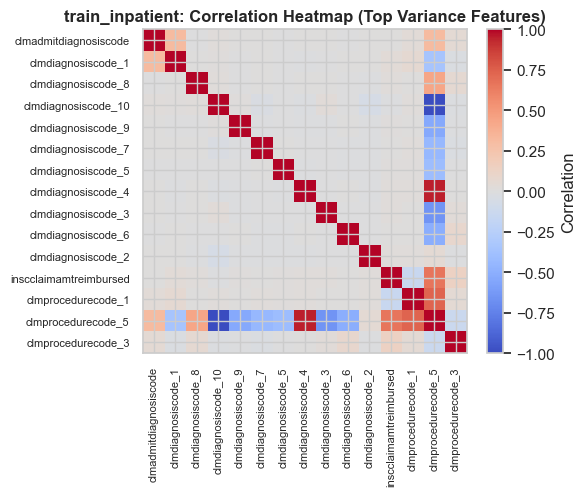



=============================== TRAIN_OUTPATIENT ===============================
📊 Shape: 517,737 rows x 27 columns
🔍 Duplicate rows: 0

---------- Data Types Summary ----------


,count,pct
float64,17,63.0
object,6,22.2
datetime64[ns],2,7.4
int64,2,7.4



---------- Top Missing Columns (Top 20) ----------


,missing_%
clmprocedurecode_6,100.00
clmprocedurecode_5,100.00
clmprocedurecode_4,100.00
clmprocedurecode_3,100.00
clmprocedurecode_2,99.99
clmprocedurecode_1,99.97
clmdiagnosiscode_10,99.84
clmdiagnosiscode_9,97.68
clmdiagnosiscode_8,96.41
clmdiagnosiscode_7,94.82



---------- Date Ranges ----------


...

otherphysician
NaN          322691
PHY412132      1247
PHY341578      1098
PHY338032      1070
PHY337425      1041
PHY347064       806
PHY322092       771
PHY409965       744
PHY313818       730
PHY350277       682
Name: count, dtype: int64


📌 [deductibleamtpaid] - Top Values:


deductibleamtpaid
0      496701
100      4582
70       2420
60       2065
40       2045
80       2024
50       1969
20       1406
30       1336
90       1245
Name: count, dtype: int64


---------- Numeric Correlation Matrix (Pearson) ----------


,inscclaimamtreimbursed,clmdiagnosiscode_1,clmdiagnosiscode_2,clmdiagnosiscode_3,clmdiagnosiscode_4,clmdiagnosiscode_5,clmdiagnosiscode_6,clmdiagnosiscode_7,clmdiagnosiscode_8,clmdiagnosiscode_9,clmdiagnosiscode_10,clmprocedurecode_1,clmprocedurecode_2,clmprocedurecode_3,clmprocedurecode_4,clmprocedurecode_5,clmprocedurecode_6,deductibleamtpaid,clmadmitdiagnosiscode
inscclaimamtreimbursed,1.000000,0.021513,0.013116,0.012192,0.012949,-0.005919,0.002783,0.006742,0.008937,-0.001603,-0.043718,-0.063064,0.190604,-0.651469,1.0,NaN,NaN,0.092015,0.027274
clmdiagnosiscode_1,0.021513,1.000000,0.062137,0.042831,0.044675,0.055360,0.042651,0.042245,0.046662,0.053388,0.014808,-0.105055,0.123215,-0.984551,1.0,NaN,NaN,0.008201,0.386478
clmdiagnosiscode_2,0.013116,0.062137,1.000000,0.012924,0.012888,0.009818,0.006369,0.014462,0.001732,0.028712,0.042345,0.116921,0.087729,-0.031136,-1.0,NaN,NaN,0.004597,0.043186
clmdiagnosiscode_3,0.012192,0.042831,0.012924,1.000000,0.002920,0.023827,0.012154,0.012297,0.018884,0.005575,0.043224,-0.105477,-0.084973,0.145692,1.0,NaN,NaN,0.002711,0.038958
clmdiagnosiscode_4,0.012949,0.044675,0.012888,0.002920,1.000000,0.008459,0.025108,0.006650,0.017660,0.016437,-0.024610,0.215191,0.057899,-0.683379,-1.0,NaN,NaN,0.003941,0.051835
clmdiagnosiscode_5,-0.005919,0.055360,0.009818,0.023827,0.008459,1.000000,0.012955,0.010594,0.018060,0.023700,-0.052071,-0.015954,0.198229,-0.837854,-1.0,NaN,NaN,0.000863,0.039211
clmdiagnosiscode_6,0.002783,0.042651,0.006369,0.012154,0.025108,0.012955,1.000000,0.008387,0.015199,0.031789,0.045826,-0.013372,0.181493,-0.941617,NaN,NaN,NaN,0.000646,0.047449
clmdiagnosiscode_7,0.006742,0.042245,0.014462,0.012297,0.006650,0.010594,0.008387,1.000000,0.000101,0.025032,0.056496,-0.119915,0.147395,0.296429,NaN,NaN,NaN,0.018731,0.050973
clmdiagnosiscode_8,0.008937,0.046662,0.001732,0.018884,0.017660,0.018060,0.015199,0.000101,1.000000,0.009580,0.064178,-0.080952,0.245183,NaN,NaN,NaN,NaN,0.006552,0.060482
clmdiagnosiscode_9,-0.001603,0.053388,0.028712,0.005575,0.016437,0.023700,0.031789,0.025032,0.009580,1.000000,-0.064899,0.063377,-0.131930,NaN,NaN,NaN,NaN,0.009574,-0.025450


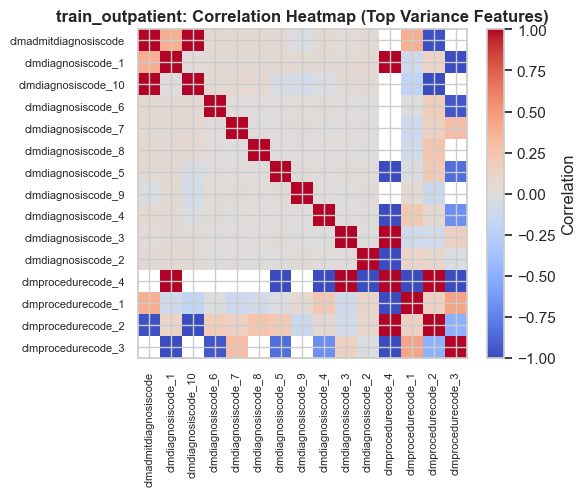



================================= TRAIN_LABELS =================================
📊 Shape: 5,410 rows x 2 columns
🔍 Duplicate rows: 0

---------- Data Types Summary ----------


,count,pct
object,1,50.0
int64,1,50.0



---------- Top Missing Columns (Top 20) ----------


,missing_%
provider,0.0
potentialfraud,0.0



---------- Numeric Variables Summary ----------


...

chroniccond_cancer
2    55176
1     8792
Name: count, dtype: int64


📌 [chroniccond_obstrpulmonary] - Top Values:


chroniccond_obstrpulmonary
2    46447
1    17521
Name: count, dtype: int64


---------- Numeric Correlation Matrix (Pearson) ----------


,gender,race,renaldiseaseindicator,state,county,noofmonths_partacov,noofmonths_partbcov,chroniccond_alzheimer,chroniccond_heartfailure,chroniccond_kidneydisease,chroniccond_cancer,chroniccond_obstrpulmonary,chroniccond_depression,chroniccond_diabetes,chroniccond_ischemicheart,chroniccond_osteoporasis,chroniccond_rheumatoidarthritis,chroniccond_stroke,ipannualreimbursementamt,ipannualdeductibleamt,opannualreimbursementamt,opannualdeductibleamt
gender,1.000000,0.005061,NaN,0.009510,0.007927,0.005554,0.007262,-0.017670,-0.005136,-0.005426,0.007811,-0.009430,-0.022473,-0.020966,-0.006320,-0.014517,-0.006053,-0.001869,0.004451,0.001865,0.006791,0.007728
race,0.005061,1.000000,NaN,-0.021600,0.001194,-0.009514,-0.005229,0.000052,0.001241,-0.003045,0.012714,0.002422,-0.007153,-0.000479,0.007602,0.008384,0.001746,0.000999,-0.002150,-0.003588,0.007950,0.005807
renaldiseaseindicator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,0.009510,-0.021600,NaN,1.000000,0.200432,-0.002270,0.006279,0.011387,0.005502,0.008383,0.008881,0.001817,0.004838,0.008027,0.008669,0.010041,0.008031,0.005333,-0.011019,-0.011470,-0.017574,-0.018532
county,0.007927,0.001194,NaN,0.200432,1.000000,0.007694,0.006991,-0.010880,-0.016224,-0.015027,0.002189,-0.009218,-0.009781,-0.013601,-0.013018,-0.006459,-0.004536,-0.003908,0.005907,0.003445,0.001686,0.002565
noofmonths_partacov,0.005554,-0.009514,NaN,-0.002270,0.007694,1.000000,0.220714,-0.025492,-0.020972,-0.018862,-0.007674,-0.017174,-0.017266,-0.035725,-0.020771,-0.010738,-0.016967,-0.009727,-0.001923,0.005644,0.011089,0.012992
noofmonths_partbcov,0.007262,-0.005229,NaN,0.006279,0.006991,0.220714,1.000000,-0.018056,-0.028540,-0.025356,-0.009638,-0.018734,-0.026881,-0.045587,-0.029812,-0.019821,-0.020156,-0.010798,0.008851,0.013812,0.017748,0.016373
chroniccond_alzheimer,-0.017670,0.000052,NaN,0.011387,-0.010880,-0.025492,-0.018056,1.000000,0.197663,0.192454,0.048456,0.176701,0.177238,0.191816,0.157842,0.084187,0.095343,0.132673,-0.126718,-0.154740,-0.081820,-0.089070
chroniccond_heartfailure,-0.005136,0.001241,NaN,0.005502,-0.016224,-0.020972,-0.028540,0.197663,1.000000,0.311378,0.084654,0.261046,0.166145,0.283235,0.277659,0.090601,0.132667,0.134909,-0.186859,-0.194952,-0.144540,-0.154212
chroniccond_kidneydisease,-0.005426,-0.003045,NaN,0.008383,-0.015027,-0.018862,-0.025356,0.192454,0.311378,1.000000,0.113253,0.258873,0.171737,0.310601,0.244458,0.099108,0.149151,0.148481,-0.279707,-0.273647,-0.217105,-0.225768


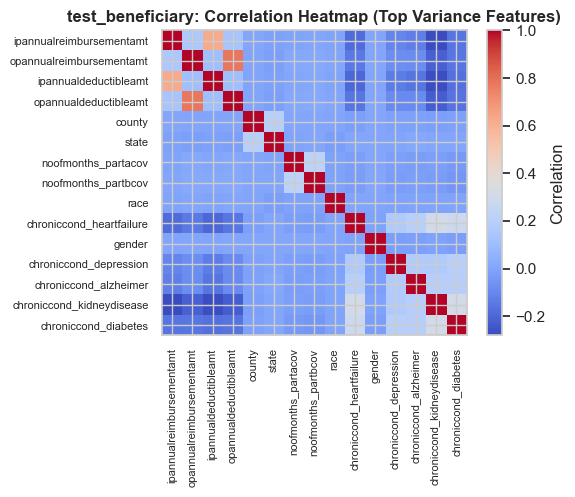



================================ TEST_INPATIENT ================================
📊 Shape: 9,551 rows x 30 columns
🔍 Duplicate rows: 0

---------- Data Types Summary ----------


,count,pct
float64,19,63.3
object,6,20.0
datetime64[ns],4,13.3
int64,1,3.3



---------- Top Missing Columns (Top 20) ----------


,missing_%
clmprocedurecode_6,100.00
clmprocedurecode_5,99.98
clmprocedurecode_4,99.70
clmprocedurecode_3,97.67
clmdiagnosiscode_10,91.90
otherphysician,89.39
clmprocedurecode_2,86.87
clmprocedurecode_1,43.12
operatingphysician,41.48
clmdiagnosiscode_9,40.90



---------- Date Ranges ----------


...

operatingphysician
NaN          3962
PHY350998     170
PHY356259     170
PHY335869     139
PHY411861     135
PHY356145     112
PHY424915     106
PHY324672      98
PHY374216      96
PHY414941      90
Name: count, dtype: int64


📌 [otherphysician] - Top Values:


otherphysician
NaN          8538
PHY335869      38
PHY400576      21
PHY334783      16
PHY421759      15
PHY408074      10
PHY426107       9
PHY321461       9
PHY351219       8
PHY428648       8
Name: count, dtype: int64


---------- Numeric Correlation Matrix (Pearson) ----------


,inscclaimamtreimbursed,clmadmitdiagnosiscode,deductibleamtpaid,diagnosisgroupcode,clmdiagnosiscode_1,clmdiagnosiscode_2,clmdiagnosiscode_3,clmdiagnosiscode_4,clmdiagnosiscode_5,clmdiagnosiscode_6,clmdiagnosiscode_7,clmdiagnosiscode_8,clmdiagnosiscode_9,clmdiagnosiscode_10,clmprocedurecode_1,clmprocedurecode_2,clmprocedurecode_3,clmprocedurecode_4,clmprocedurecode_5,clmprocedurecode_6
inscclaimamtreimbursed,1.000000,-0.005240,NaN,0.034529,0.024584,0.026730,0.011036,0.008847,0.021183,0.013275,-0.014582,0.026455,0.019745,-0.012533,-0.161168,0.105987,0.066883,0.139267,1.0,NaN
clmadmitdiagnosiscode,-0.005240,1.000000,NaN,-0.041888,0.287336,0.014381,0.021726,-0.000390,-0.015778,0.001865,0.010860,0.009748,0.005868,-0.030191,0.066915,-0.004641,-0.061727,0.119743,1.0,NaN
deductibleamtpaid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
diagnosisgroupcode,0.034529,-0.041888,NaN,1.000000,-0.061325,0.013667,0.039222,0.049292,0.044265,0.036858,0.031659,0.019690,0.021099,0.050493,0.198263,0.067109,0.094498,0.047565,1.0,NaN
clmdiagnosiscode_1,0.024584,0.287336,NaN,-0.061325,1.000000,-0.016678,0.013186,-0.005419,-0.019177,-0.000047,-0.000412,0.016724,0.019845,0.011968,0.070741,-0.027859,-0.030452,-0.004065,-1.0,NaN
clmdiagnosiscode_2,0.026730,0.014381,NaN,0.013667,-0.016678,1.000000,-0.001795,0.000790,-0.017430,0.017089,0.015486,-0.006066,-0.015879,0.006522,0.009674,-0.002935,-0.085925,0.095189,NaN,NaN
clmdiagnosiscode_3,0.011036,0.021726,NaN,0.039222,0.013186,-0.001795,1.000000,-0.015133,-0.011304,-0.018513,-0.001227,0.005086,-0.000589,-0.025411,0.027580,0.002658,0.032120,-0.132026,NaN,NaN
clmdiagnosiscode_4,0.008847,-0.000390,NaN,0.049292,-0.005419,0.000790,-0.015133,1.000000,-0.019655,-0.012066,0.028890,-0.004273,0.010399,-0.096423,0.016280,-0.011262,0.113593,-0.203199,-1.0,NaN
clmdiagnosiscode_5,0.021183,-0.015778,NaN,0.044265,-0.019177,-0.017430,-0.011304,-0.019655,1.000000,-0.016573,0.025215,-0.011188,-0.005876,0.001004,-0.004034,0.008735,0.020944,-0.096152,-1.0,NaN
clmdiagnosiscode_6,0.013275,0.001865,NaN,0.036858,-0.000047,0.017089,-0.018513,-0.012066,-0.016573,1.000000,0.004096,0.002116,-0.004972,0.005063,0.018585,-0.017716,-0.049135,0.354156,-1.0,NaN


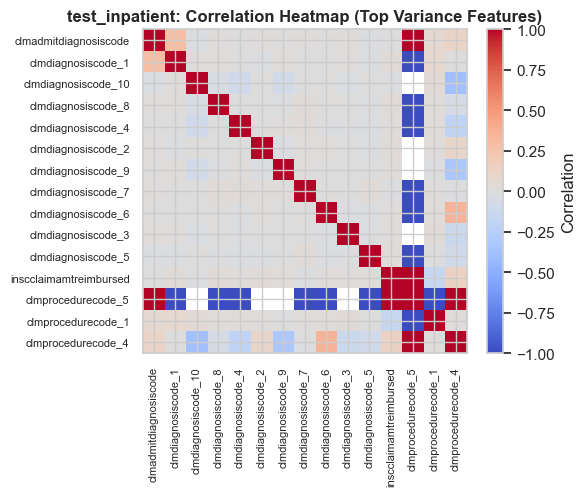



=============================== TEST_OUTPATIENT ===============================
📊 Shape: 125,841 rows x 27 columns
🔍 Duplicate rows: 0

---------- Data Types Summary ----------


,count,pct
float64,17,63.0
object,6,22.2
datetime64[ns],2,7.4
int64,2,7.4



---------- Top Missing Columns (Top 20) ----------


,missing_%
clmprocedurecode_6,100.00
clmprocedurecode_5,100.00
clmprocedurecode_4,100.00
clmprocedurecode_3,100.00
clmprocedurecode_2,99.99
clmprocedurecode_1,99.97
clmdiagnosiscode_10,99.84
clmdiagnosiscode_9,97.68
clmdiagnosiscode_8,96.39
clmdiagnosiscode_7,94.90



---------- Date Ranges ----------


...

otherphysician
NaN          78222
PHY344080     1205
PHY378872      375
PHY347633      338
PHY353454      324
PHY333055      318
PHY347412      307
PHY385096      261
PHY359649      243
PHY410478      240
Name: count, dtype: int64


📌 [deductibleamtpaid] - Top Values:


deductibleamtpaid
0      120711
100      1115
70        598
50        520
40        512
80        488
60        483
20        345
30        317
10        291
Name: count, dtype: int64


---------- Numeric Correlation Matrix (Pearson) ----------


,inscclaimamtreimbursed,clmdiagnosiscode_1,clmdiagnosiscode_2,clmdiagnosiscode_3,clmdiagnosiscode_4,clmdiagnosiscode_5,clmdiagnosiscode_6,clmdiagnosiscode_7,clmdiagnosiscode_8,clmdiagnosiscode_9,clmdiagnosiscode_10,clmprocedurecode_1,clmprocedurecode_2,clmprocedurecode_3,clmprocedurecode_4,clmprocedurecode_5,clmprocedurecode_6,deductibleamtpaid,clmadmitdiagnosiscode
inscclaimamtreimbursed,1.000000,0.026108,0.016166,0.015267,0.006653,-0.005355,-0.006641,-0.004192,0.026978,-0.012787,0.026051,0.058065,0.780470,1.0,NaN,NaN,NaN,0.140966,0.025208
clmdiagnosiscode_1,0.026108,1.000000,0.056228,0.064026,0.039541,0.065456,0.045129,0.047214,0.060573,0.065619,0.070801,0.116737,0.087578,-1.0,NaN,NaN,NaN,0.014208,0.375607
clmdiagnosiscode_2,0.016166,0.056228,1.000000,0.013533,0.010599,0.018229,0.011610,-0.008955,0.029773,0.008967,0.080498,0.037654,0.214635,1.0,NaN,NaN,NaN,0.006651,0.065441
clmdiagnosiscode_3,0.015267,0.064026,0.013533,1.000000,0.015041,0.017816,0.014278,0.021331,0.010982,0.016844,0.121767,0.248536,-0.484578,1.0,NaN,NaN,NaN,-0.002826,0.060193
clmdiagnosiscode_4,0.006653,0.039541,0.010599,0.015041,1.000000,0.022913,0.015410,0.029703,0.027231,0.045989,0.049275,0.160475,0.049228,-1.0,NaN,NaN,NaN,-0.001048,0.066498
clmdiagnosiscode_5,-0.005355,0.065456,0.018229,0.017816,0.022913,1.000000,0.018653,0.026391,0.005225,0.018504,0.096326,0.021898,-0.727355,-1.0,NaN,NaN,NaN,0.001672,0.015710
clmdiagnosiscode_6,-0.006641,0.045129,0.011610,0.014278,0.015410,0.018653,1.000000,0.030072,0.015317,0.028324,0.070886,0.113461,-0.179924,NaN,NaN,NaN,NaN,0.000805,0.031268
clmdiagnosiscode_7,-0.004192,0.047214,-0.008955,0.021331,0.029703,0.026391,0.030072,1.000000,0.010451,0.025425,0.063001,-0.212824,0.241312,-1.0,NaN,NaN,NaN,0.010125,0.015069
clmdiagnosiscode_8,0.026978,0.060573,0.029773,0.010982,0.027231,0.005225,0.015317,0.010451,1.000000,0.025819,-0.024243,-0.271656,0.894407,1.0,NaN,NaN,NaN,0.055178,0.069100
clmdiagnosiscode_9,-0.012787,0.065619,0.008967,0.016844,0.045989,0.018504,0.028324,0.025425,0.025819,1.000000,0.046030,0.057381,-0.016209,1.0,NaN,NaN,NaN,-0.006557,0.047992


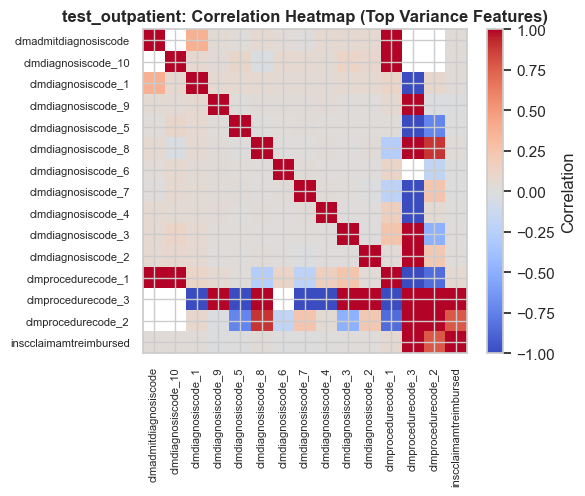



================================= TEST_LABELS =================================
📊 Shape: 1,353 rows x 1 columns
🔍 Duplicate rows: 0

---------- Data Types Summary ----------


,count,pct
object,1,100.0



---------- Top Missing Columns (Top 20) ----------


,missing_%
provider,0.0



---------- Categorical Variables (Top 10 Columns) ----------

📌 [provider] - Top Values:


provider
PRV51002    1
PRV55422    1
PRV55484    1
PRV55478    1
PRV55476    1
PRV55466    1
PRV55461    1
PRV55457    1
PRV55440    1
PRV55429    1
Name: count, dtype: int64



✅ INDIVIDUAL TABLE ANALYSIS COMPLETE


In [ ]:
print("\n" + "=" * 80)
print("EXPLORATORY DATA ANALYSIS - INDIVIDUAL TABLES")
print("=" * 80)

print("\n" + "=" * 35 + " TRAINING DATA " + "=" * 35)
eda_report(train_bene, "train_beneficiary")
eda_report(train_inp,  "train_inpatient")
eda_report(train_out,  "train_outpatient")
eda_report(train_lbl,  "train_labels")    # (usually has Provider + PotentialFraud)

print("\n" + "=" * 35 + " TEST DATA " + "=" * 38)
eda_report(test_bene,  "test_beneficiary")
eda_report(test_inp,   "test_inpatient")
eda_report(test_out,   "test_outpatient")
eda_report(test_lbl,   "test_labels")     # (usually has only Provider)

print("\n" + "=" * 80)
print("INDIVIDUAL TABLE ANALYSIS COMPLETE")
print("=" * 80)

#### Insights
**Beneficiary (train/test)**

- Coverage & demographics: ~84% integer cols, lots of flags; dob spans 1909–1983 → ages ~26–100 at 2009 (plausible Medicare-like).

- dod ~99% missing: normal (most beneficiaries didn’t die in 2009). Treat missing as “alive”.

- Part A/B months: almost always 12 with a small tail at 0/6/… → use as coverage stability features; treat 0 as genuine (not missing).

- Money fields: ip/op*_amt/deductible show heavy right tails, a few negative values (refund/adjustment). Plan outlier handling.

- Chronic conditions: values are 1/2 with 2 being majority. In the common Kaggle schema, that means 1=Yes, 2=No (counter-intuitive!). We should map 1→1, 2→0. (Your counts match that: “2” much larger for many conditions → most people don’t have the condition.)

- Correlations (bene):
    - Reasonable positive associations among chronic conditions (e.g., diabetes ↔ ischemic heart, COPD ↔ heart failure).
    - Moderate op/ip reimbursement ↔ op/ip deductible (0.75/0.63) → cost measures move together.
    - Near-zero with gender/race (as expected).

**Inpatient / Outpatient (train/test)**

- Date windows: late-2008 to 2009 — consistent across sets (good).

- Procedure codes: clmprocedurecode_3..6 mostly 100% missing, especially in outpatient. That’s normal: many claims don’t include CPT code slots beyond the first 1–2.

- Diagnosis codes: increasing missingness from diag_1 to diag_10 as slots run out — expected pattern.

- Physician columns: many NaN (e.g., otherphysician, operatingphysician) — keep as sparse categoricals or collapse to “Unknown”.

- Inpatient deductibleamtpaid is a constant 1068 for almost everyone → near-zero variance; either drop or keep as a check flag.

- Outpatient deductibleamtpaid is heavily zero-inflated with spikes at 100, 70, 60… (tariff-like). Useful as categorical/ordinal bins.

- Correlations:
    - Many wild ±1 values among clmprocedurecode_*/clmdiagnosiscode_* — that’s because these are codes (labels), not continuous quantities; Pearson on codes is not semantically meaningful and the ±1s often come from tiny non-missing slices. Don’t interpret these numerically — treat as categorical tokens.

### Target variable


🎯 TARGET VARIABLE ANALYSIS

======================= TARGET VARIABLE: POTENTIALFRAUD =======================

🎯 Distribution of potentialfraud:


,count,percentage (%)
potentialfraud,,
0,4904,90.65
1,506,9.35


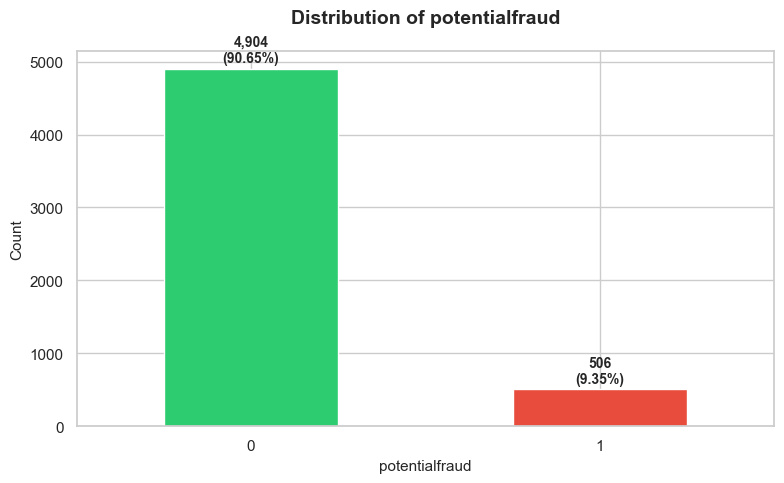


✅ TARGET ANALYSIS COMPLETE


In [ ]:
print("\n" + "=" * 80)
print("TARGET VARIABLE ANALYSIS")
print("=" * 80)
target_report(train_lbl, target_col="potentialfraud")
print("TARGET ANALYSIS COMPLETE")
print("=" * 80)

#### Insights
Detailed Class Distribution: 90.7% non-fraud vs 9.3% fraud (10:1 ratio)
- ⚠️ Three Critical Problems: Model bias, learning challenges, and business impact
- ✅ Five Comprehensive Solutions: SMOTE (primary), stratified CV, proper metrics, class weights, and ensemble methods

### Run on merged table


🔗 EXPLORATORY DATA ANALYSIS - MERGED TABLES

📝 Analyzing complete merged datasets with all claim, beneficiary, and provider information...


================================= TRAIN_MERGED =================================
📊 Shape: 558,211 rows x 55 columns
🔍 Duplicate rows: 0

---------- Data Types Summary ----------


,count,pct
int64,23,41.8
float64,20,36.4
object,6,10.9
datetime64[ns],6,10.9



---------- Top Missing Columns (Top 20) ----------


,missing_%
clmprocedurecode_6,100.00
clmprocedurecode_5,100.00
clmprocedurecode_4,99.98
clmprocedurecode_3,99.83
dod,99.26
clmdiagnosiscode_10,99.23
clmprocedurecode_2,99.02
clmprocedurecode_1,95.82
clmdiagnosiscode_9,93.54
diagnosisgroupcode,92.77



---------- Date Ranges ----------


...

noofmonths_partacov
12    554722
0       2971
6        116
8        100
11        81
4         55
7         44
10        34
5         30
2         16
Name: count, dtype: int64


📌 [noofmonths_partbcov] - Top Values:


noofmonths_partbcov
12    553918
0       1979
6        728
10       402
11       313
9        242
8        142
7        139
5        126
3         73
Name: count, dtype: int64


---------- Numeric Correlation Matrix (Pearson) ----------


,inscclaimamtreimbursed,clmadmitdiagnosiscode,deductibleamtpaid,diagnosisgroupcode,clmdiagnosiscode_1,clmdiagnosiscode_2,clmdiagnosiscode_3,clmdiagnosiscode_4,clmdiagnosiscode_5,clmdiagnosiscode_6,clmdiagnosiscode_7,clmdiagnosiscode_8,clmdiagnosiscode_9,clmdiagnosiscode_10,clmprocedurecode_1,clmprocedurecode_2,clmprocedurecode_3,clmprocedurecode_4,clmprocedurecode_5,clmprocedurecode_6,gender,race,renaldiseaseindicator,state,county,noofmonths_partacov,noofmonths_partbcov,chroniccond_alzheimer,chroniccond_heartfailure,chroniccond_kidneydisease,chroniccond_cancer,chroniccond_obstrpulmonary,chroniccond_depression,chroniccond_diabetes,chroniccond_ischemicheart,chroniccond_osteoporasis,chroniccond_rheumatoidarthritis,chroniccond_stroke,ipannualreimbursementamt,ipannualdeductibleamt,opannualreimbursementamt,opannualdeductibleamt,potentialfraud
inscclaimamtreimbursed,1.000000,0.074946,0.665488,0.027383,0.030092,-0.014212,-0.016682,-0.016647,-0.027562,-0.029187,-0.026493,-0.013215,-0.017169,-0.034648,-0.145059,0.108619,0.136799,-0.080588,0.662121,NaN,-0.002094,-0.000477,NaN,0.000208,-0.001029,-0.005551,-0.005824,-0.034013,-0.058602,-0.097151,-0.026543,-0.068528,-0.017902,-0.044934,-0.052348,-0.010454,-0.017377,-0.048768,0.383701,0.225477,0.064411,0.030561,0.080613
clmadmitdiagnosiscode,0.074946,1.000000,0.113261,-0.039691,0.360540,0.021221,0.013887,0.017404,0.005440,0.004450,0.012447,0.006472,0.003745,0.021436,0.035758,-0.029352,0.052884,0.137464,0.309607,NaN,-0.001126,0.002099,NaN,0.000133,-0.002633,-0.000733,-0.003160,-0.013352,-0.019879,-0.019945,0.035338,-0.026191,-0.007675,-0.008659,-0.022381,-0.009769,-0.023343,-0.007909,0.053286,0.054416,0.013504,0.012113,0.024453
deductibleamtpaid,0.665488,0.113261,1.000000,NaN,0.029512,-0.031243,-0.038469,-0.041646,-0.051308,-0.058508,-0.052968,-0.049598,-0.051651,-0.053667,-0.006736,-0.010818,0.036194,-0.000524,NaN,NaN,-0.002609,-0.002247,NaN,-0.001056,-0.001336,-0.004798,-0.005937,-0.055841,-0.071794,-0.103983,-0.029873,-0.096762,-0.036013,-0.056886,-0.061411,-0.020043,-0.028885,-0.061133,0.282815,0.308890,-0.027973,-0.033844,0.112305
diagnosisgroupcode,0.027383,-0.039691,NaN,1.000000,-0.060163,0.029557,0.032784,0.030790,0.023863,0.032374,0.032091,0.024428,0.026737,0.039874,0.218572,0.024505,0.085571,0.044304,-0.388174,NaN,0.002256,-0.000114,NaN,-0.005304,-0.000771,0.003513,0.002299,-0.006391,0.052355,-0.014521,0.010501,0.065808,-0.048860,0.008995,0.050238,-0.001605,-0.015039,0.108926,0.026976,0.018866,0.015086,0.018925,0.002721
clmdiagnosiscode_1,0.030092,0.360540,0.029512,-0.060163,1.000000,0.054133,0.033176,0.030411,0.035545,0.028714,0.024260,0.025178,0.019579,0.013606,0.056192,-0.032637,-0.030054,0.127303,-0.349633,NaN,0.004554,0.002680,NaN,-0.000425,0.001654,0.000849,-0.001416,-0.000125,0.000552,0.009936,0.037015,0.000849,-0.013819,-0.001926,-0.002429,-0.022017,-0.032959,0.002131,0.010544,0.009034,-0.014894,-0.012924,0.004883
clmdiagnosiscode_2,-0.014212,0.021221,-0.031243,0.029557,0.054133,1.000000,0.012066,0.009706,0.005682,0.006704,0.004490,-0.003170,0.006198,-0.039334,0.016943,-0.012988,-0.013165,0.018892,0.052994,NaN,0.001932,-0.002215,NaN,-0.002698,-0.001292,-0.000145,0.001639,0.006653,0.014815,0.010812,0.013333,0.011597,0.009287,0.007022,-0.000060,-0.024032,-0.018925,-0.000998,-0.007062,-0.008819,0.014656,0.016462,-0.006822
clmdiagnosiscode_3,-0.016682,0.013887,-0.038469,0.032784,0.033176,0.012066,1.000000,0.003281,0.017085,0.008072,0.006683,0.013249,-0.004774,0.028788,0.005428,0.007079,0.027703,-0.062749,-0.652687,NaN,0.003216,-0.000513,NaN,-0.002053,0.002737,0.002585,0.001295,0.007211,0.006762,0.006889,0.009551,0.012877,0.005878,0.005701,0.001507,-0.021687,-0.016164,-0.000757,-0.005272,-0.007495,0.023165,0.024430,-0.006404
clmdiagnosiscode_4,-0.016647,0.017404,-0.041646,0.030790,0.030411,0.009706,0.003281,1.000000,0.005076,0.019979,0.005738,0.010170,0.002885,-0.016891,0.022754,0.001716,0.004987,0.118365,0.949768,NaN,0.003001,-0.000400,NaN,0.000392,-0.001197,0.001413,0.001234,0.

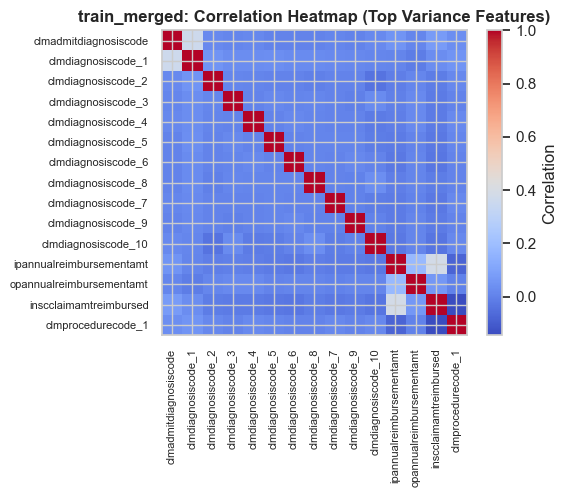



================================= TEST_MERGED =================================
📊 Shape: 135,392 rows x 54 columns
🔍 Duplicate rows: 0

---------- Data Types Summary ----------


,count,pct
int64,22,40.7
float64,20,37.0
object,6,11.1
datetime64[ns],6,11.1



---------- Top Missing Columns (Top 20) ----------


,missing_%
clmprocedurecode_6,100.00
clmprocedurecode_5,100.00
clmprocedurecode_4,99.98
clmprocedurecode_3,99.83
clmdiagnosiscode_10,99.28
dod,99.23
clmprocedurecode_2,99.07
clmprocedurecode_1,95.96
clmdiagnosiscode_9,93.67
diagnosisgroupcode,92.97



---------- Date Ranges ----------


...

noofmonths_partacov
12    134524
0        733
8         30
11        26
6         25
4         16
9         12
7         10
5          7
10         4
Name: count, dtype: int64


📌 [noofmonths_partbcov] - Top Values:


noofmonths_partbcov
12    134405
0        442
6        155
11        97
10        71
9         69
5         43
8         36
7         24
3         16
Name: count, dtype: int64


---------- Numeric Correlation Matrix (Pearson) ----------


,inscclaimamtreimbursed,clmadmitdiagnosiscode,deductibleamtpaid,diagnosisgroupcode,clmdiagnosiscode_1,clmdiagnosiscode_2,clmdiagnosiscode_3,clmdiagnosiscode_4,clmdiagnosiscode_5,clmdiagnosiscode_6,clmdiagnosiscode_7,clmdiagnosiscode_8,clmdiagnosiscode_9,clmdiagnosiscode_10,clmprocedurecode_1,clmprocedurecode_2,clmprocedurecode_3,clmprocedurecode_4,clmprocedurecode_5,clmprocedurecode_6,gender,race,renaldiseaseindicator,state,county,noofmonths_partacov,noofmonths_partbcov,chroniccond_alzheimer,chroniccond_heartfailure,chroniccond_kidneydisease,chroniccond_cancer,chroniccond_obstrpulmonary,chroniccond_depression,chroniccond_diabetes,chroniccond_ischemicheart,chroniccond_osteoporasis,chroniccond_rheumatoidarthritis,chroniccond_stroke,ipannualreimbursementamt,ipannualdeductibleamt,opannualreimbursementamt,opannualdeductibleamt
inscclaimamtreimbursed,1.000000,0.066883,0.664444,0.034529,0.023551,-0.012310,-0.018181,-0.022713,-0.026696,-0.019506,-0.036053,-0.010816,-0.020271,-0.021698,-0.157426,0.109932,0.053707,0.139267,1.0,NaN,-0.001459,-0.001603,NaN,-0.007207,0.000635,-0.006998,-0.002671,-0.025174,-0.054637,-0.095976,-0.024141,-0.064892,-0.022599,-0.034719,-0.045863,-0.008165,-0.015874,-0.041284,0.376638,0.207580,0.071688,0.030155
clmadmitdiagnosiscode,0.066883,1.000000,0.109260,-0.041888,0.345941,0.038788,0.035762,0.021700,-0.008892,0.007777,0.010751,0.018256,0.009749,-0.030191,0.067414,-0.005392,-0.061727,0.119743,1.0,NaN,-0.002153,-0.002458,NaN,0.012324,0.002314,0.005204,-0.004490,-0.008888,-0.016812,-0.012931,0.018670,-0.018310,0.003476,-0.010771,-0.019223,-0.000380,-0.011125,-0.002641,0.039806,0.055313,0.006915,0.009139
deductibleamtpaid,0.664444,0.109260,1.000000,NaN,0.021450,-0.032501,-0.036323,-0.042832,-0.058817,-0.044491,-0.052220,-0.056622,-0.068532,-0.034672,0.011438,0.022012,-0.118133,NaN,NaN,NaN,-0.003559,0.000510,NaN,-0.006917,0.000500,-0.004734,-0.002000,-0.046888,-0.066323,-0.101706,-0.025897,-0.097932,-0.039450,-0.047629,-0.055028,-0.016831,-0.027889,-0.058153,0.279326,0.289200,-0.027510,-0.034084
diagnosisgroupcode,0.034529,-0.041888,NaN,1.000000,-0.061325,0.013667,0.039222,0.049292,0.044265,0.036858,0.031659,0.019690,0.021099,0.050493,0.198263,0.067109,0.094498,0.047565,1.0,NaN,-0.006749,-0.004155,NaN,0.003436,0.001824,-0.002527,-0.004848,0.003187,0.060829,-0.026398,0.017419,0.058395,-0.047956,-0.000460,0.058993,-0.011599,-0.001372,0.096780,0.028384,0.025340,-0.004618,0.007989
clmdiagnosiscode_1,0.023551,0.345941,0.021450,-0.061325,1.000000,0.046741,0.054503,0.028477,0.038524,0.027723,0.026514,0.041119,0.041475,0.025126,0.071147,-0.027011,-0.036628,-0.004065,-1.0,NaN,0.008679,-0.002740,NaN,0.006411,-0.000859,0.001616,-0.002402,-0.002732,0.008227,0.013554,0.037298,0.005287,-0.012584,0.003383,0.001349,-0.014536,-0.025602,0.003952,0.005535,0.005157,-0.015301,-0.011256
clmdiagnosiscode_2,-0.012310,0.038788,-0.032501,0.013667,0.046741,1.000000,0.012637,0.010463,0.009283,0.016315,0.005187,0.012285,-0.004352,0.025161,0.009936,-0.002058,-0.086085,0.095189,NaN,NaN,-0.001400,-0.003376,NaN,-0.003221,-0.004379,0.000060,0.005437,-0.003181,0.010016,0.002390,0.017918,0.014526,0.007987,0.007080,0.000994,-0.016319,-0.015927,-0.006115,-0.003191,-0.007551,0.026160,0.026662
clmdiagnosiscode_3,-0.018181,0.035762,-0.036323,0.039222,0.054503,0.012637,1.000000,0.010124,0.011833,0.003700,0.013350,0.011236,0.009527,0.006799,0.028724,0.000790,0.051304,-0.132026,NaN,NaN,-0.006664,0.005387,NaN,0.002103,0.002909,-0.001081,0.007127,0.006072,0.004737,0.009563,0.004746,0.012451,-0.002116,0.004031,0.001320,-0.019244,-0.016123,-0.002498,-0.005866,-0.002396,0.019839,0.018688
clmdiagnosiscode_4,-0.022713,0.021700,-0.042832,0.049292,0.028477,0.010463,0.010124,1.000000,0.012346,0.006590,0.032407,0.011801,0.027471,-0.064704,0.017180,-0.010462,0.104622,-0.203199,-1.0,NaN,-0.000005,-0.003150,NaN,-0.001072,-0.009305,0.002371,-0.011082,0.009373,0.017632,0.012470,0.002782,0.023185,0.004199,0.002717,-0.001871,-0.017829,-0.015561,0.008549,-0.019005,-0.022916

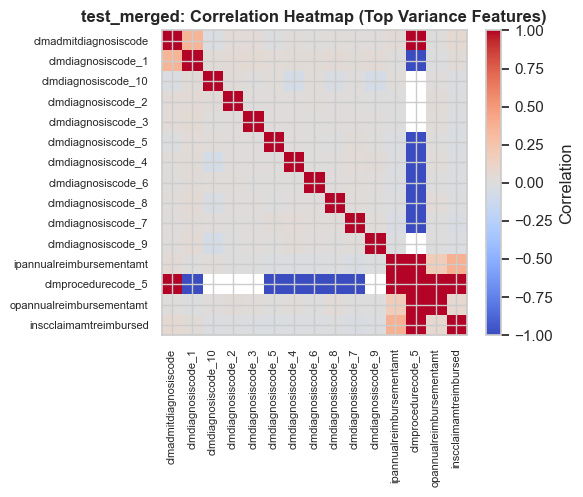



✅ MERGED TABLE ANALYSIS COMPLETE


In [ ]:
print("\n" + "=" * 80)
print("EXPLORATORY DATA ANALYSIS - MERGED TABLES")
print("=" * 80)
print("\nAnalyzing complete merged datasets with all claim, beneficiary, and provider information...\n")

try:
    eda_report(train_merged, "train_merged")
    eda_report(test_merged,  "test_merged")
    print("\n" + "=" * 80)
    print("✅ MERGED TABLE ANALYSIS COMPLETE")
    print("=" * 80)
except NameError:
    print("Merged tables not found. Skipping merged analysis.")
    print("=" * 80)

#### Insights
**Quick health check:**
- Rows/cols: train 558,211×51; test 135,392×51. No duplicates.
- Time bounds: claims span late-2008 → 2009. Use absolute dates (YYYY-MM-DD) and derive claim year/quarter/month.
- Ages: DOB 1909–1983 ⇒ ages ~26–100 in 2009. Create age at claim (floor((claimstartdt-dob)/365.25)), and optionally age buckets.
- Massive sparsity: procedure slots 2–6 are ~99–100% missing; diagnosis slots 5–10 are 83–99% missing. Treat these as variable-length lists: don’t impute code IDs; instead engineer counts/presence.
- DOD ~99% missing. Interpret as “alive/not recorded” and derive a deceased flag + days from claim to DOD where present; otherwise drop raw dod.

**Leakage + semantics to watch**

- Annual totals (ipannual*, opannual*) are same-year aggregates. If your target is claim-level payment (inscclaimamtreimbursed) they may include information computed after the claim—potential leakage. If you keep them, ensure they’re built from prior claims only (lagged, patient-level).
- Chronic condition flags sit around 1.4–1.9 mean, which suggests CMS encoding (1 = Yes, 2 = No). Remap to binary (1→1, 2→0) before modeling; treating them as numeric 1/2 will invert meanings and blur correlations.
- State and county are categorical codes, not ordinals—encode accordingly.

**Missingness & what to do**

- Drop outright (very safe): clmprocedurecode_6 (100% missing), clmprocedurecode_5 (~100%), clmprocedurecode_4 (~100%), clmprocedurecode_3 (~99.8%).
- Same for clmdiagnosiscode_10 (~99%) unless you plan sparse sequence features.

**Engineer instead of imputing codes:**

- diag_count = number of non-null diagnosis slots.

- proc_count = number of non-null procedure slots.

- Top-K code presence: make binary features for the top ~50–200 most frequent diagnosis/procedure codes (across all slots).

- Any_surgical/any_ED flags if you can map code groups.

- Physician fields (operatingphysician, otherphysician) ~65–80%+ missing. Useful as presence flags and high-cardinality categories (target/frequency encoding). Consider provider/physician-level aggregates (see below).

**Distributions & oddities**

- Reimbursed amounts (inscclaimamtreimbursed) are extremely right-skewed with big outliers (up to 125k). Use log1p or robust losses; cap outliers.

- Deductibles: deductibleamtpaid and annual deductibles have a prominent spike at 1068 (plan max). Keep as numeric; consider is_max_deductible flag.

- Negative amounts: ipannualreimbursementamt/opannualreimbursementamt have negatives (refunds/adjustments). Keep but maybe add has_refund flags.

- Weird perfect correlations: clmprocedurecode_5 shows ±1 correlations in both splits—this is an artifact of tiny non-null counts. Best to drop raw column and only use counts/presence features.

**Train vs test drift**

- Missingness patterns, central tendencies, and category shares are very similar across splits. Top providers/physicians differ (expected), but macro stats match. No obvious covariate shift.

**Categorical high-cardinality plan**

- IDs: provider, attendingphysician, operatingphysician, otherphysician, beneid, claimid.

    - Don’t one-hot. Use target/frequency encoding (with CV folds to avoid leakage).

    - Build entity aggregates from training only: e.g., per-provider mean reimburse, claim volume, mix of IP/OP, average diag/proc counts, historical denial/refund rate if available.

- Geography: one-hot (top states) + frequency encoding for county. Add state×urbanicity if you can map FIPS→urban/rural.

**Date features**

- length_of_stay proxy: claimenddt - claimstartdt (days, clipped ≥0).

- Seasonality: month, quarter, day-of-week (for outpatient).

- Patient trajectory: per-bene rolling counts/totals prior to claim date (30/90/365-day windows): number of claims, sum reimbursed, average deductible, prior IP admission flag, prior specific diagnosis presence.

**Numeric features**

- After remapping chronic flags to 0/1, many should positively relate to spend. Current correlations are muted by 1/2 encoding.

- gender ≈ 58% female; race dominated by code 1. Treat as categorical (not ordinal).


🎯 TARGET VARIABLE ANALYSIS

======================= TARGET VARIABLE: POTENTIALFRAUD =======================

🎯 Distribution of potentialfraud:


,count,percentage (%)
potentialfraud,,
0,345415,61.88
1,212796,38.12


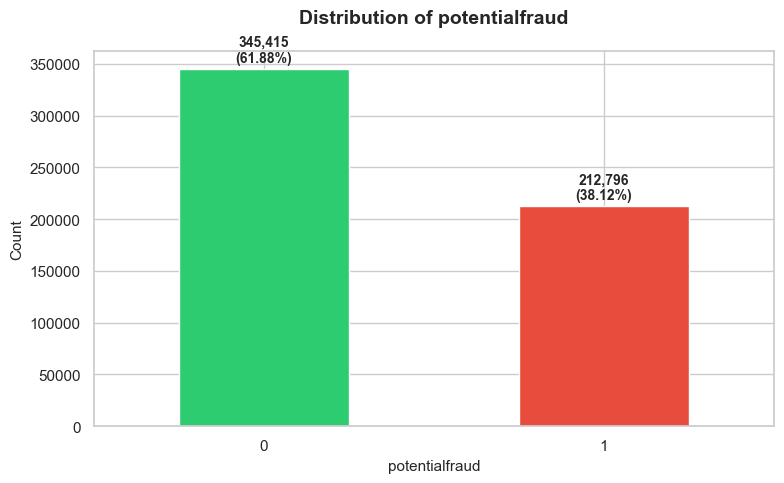


✅ TARGET ANALYSIS COMPLETE


In [ ]:
print("\n" + "=" * 80)
print("TARGET VARIABLE ANALYSIS")
print("=" * 80)
target_report(train_merged, target_col="potentialfraud")
print("TARGET ANALYSIS COMPLETE")
print("=" * 80)

## Feature Engineering (Leakage-Safe)

This section builds rich and reliable features for fraud detection while avoiding **data leakage**.

The workflow has **two parts**:


**1. `create_all_features()` — Core, Label-Free Features**

Creates all **non-leaky, deterministic features** from claim, beneficiary, and physician data.

*Key Feature Groups*

| Group | Example Columns | Description |
|--------|-----------------|--------------|
| **Temporal** | `Age_at_Claim`, `ClaimMonth`, `LOS_Days`, `Admit_LOS_Days`, `Claim_Date_Mismatch` | Captures timing, hospital stay duration, and consistency of claims |
| **Health & Diagnosis** | `Diagnosis_Count`, `Procedure_Count`, `Diagnosis_Unique_Count`, `Proc_Diag_Ratio`, `Num_Chronic_Conditions`, `Any_Chronic_Condition` | Patient complexity, chronic burden, and medical code diversity |
| **Financial** | `InscClaimAmtReimbursed_arcsinh`, `IP_Reimb_Deduct_Ratio`, `DeductibleAmtPaid_Is1068` | Claim cost structure and outlier reimbursement patterns |
| **Physician Presence** | `Has_AttendingPhysician`, `Has_OperatingPhysician`, `Num_Physicians_Present` | Detects missing or unusual physician activity on claims |
| **Mortality Flags** | `Deceased_Flag`, `Days_Claim_to_DOD` | Captures end-of-life health and claim timing patterns |
| **Top-K Code Indicators** | `HasDiag_4019`, `HasProc_99213`, etc. | Sparse presence flags for most frequent diagnosis/procedure codes |

*Transformations and Ratios*
- `arcsinh(x)` and `log1p(x)` for long-tailed cost data.
- Ratios between reimbursements and deductibles (e.g., `IP_Reimb_Deduct_Ratio`).
- Flags for negative reimbursement and deductible spikes (`== 1068`).
- Seasonality and claim timing (year, quarter, month, weekday).
- Length of stay, admission duration, and mismatch indicators.


**2. `make_oof_and_test_features()` — Leakage-Safe Aggregates**

Computes powerful **group-based and target-encoded** statistics **safely** using CV folds.

*Why This Matters*
Blocks VI and VII (provider/physician aggregates) can leak target info if calculated on the full dataset.  
To prevent this:
- We compute **out-of-fold (OOF)** features for training.
- We compute **full-train** versions only when applying to test data.

*Features Created*

| Group | Example Columns | Description |
|--------|-----------------|--------------|
| **VI. Frequency Encodings** | `Provider_Total_Claims`, `Provider_Mean_Reimbursed`, `AttendingPhysician_Total_Claims`, `BeneID_Total_Claims`, `BeneID_Unique_Physicians_Seen` | Activity, exposure, and diversity of claims per entity |
| **VII. Target Encoded (Fraud Ratios)** | `Provider_Fraud_Ratio`, `AttendingPhysician_Fraud_Ratio`, `OperatingPhysician_Fraud_Ratio` | Fraction of fraudulent claims per provider/physician, computed out-of-fold |
| **Smoothed Ratios** | `(fraud + prior * k) / (total + k)` | Stabilizes rare IDs using a global prior |

*Leakage Safety*

| Dataset | Computation | Notes |
|----------|--------------|-------|
| **Train** | Out-of-fold (OOF) CV with `StratifiedKFold` or `GroupKFold` | Prevents label look-ahead |
| **Test** | Fit on full training set, then apply | Simulates production inference |
| **Groups** | Use `GroupKFold` by `BeneID` | Prevents the same beneficiary appearing in both train and validation |


**3. Example Usage**

```python
# Base features (no leakage)
train_base = create_all_features(train_df, include_id_counts=False, include_fraud_ratios=False)
test_base  = create_all_features(test_df,  include_id_counts=False, include_fraud_ratios=False)

# Add leakage-safe ID counts & fraud ratios
train_ready, test_ready = make_oof_and_test_features(
    train_base, test_base,
    id_cols=('BeneID','AttendingPhysician','OperatingPhysician','OtherPhysician','Provider'),
    y_col='PotentialFraud',
    n_splits=5,
    group_col='BeneID'  # recommended to avoid patient leakage
)

# Model training
# Use train_ready for training, test_ready for inference


### Feature Engineering

In [29]:
# ================================
# Feature Engineering (Leakage-Safe) — optimized Top-K flags
# ================================
from sklearn.model_selection import StratifiedKFold, GroupKFold

EPSILON = 1e-6

def _lowercase_cols(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = out.columns.str.lower().str.strip()
    return out

# ------------------------------------------------------------
# (1) Baseline feature builder (label-free by default)
# ------------------------------------------------------------
def create_all_features(
    full_df: pd.DataFrame,
    topk_diag: int = 50,
    topk_proc: int = 25,
    add_topk_presence: bool = True,
    # 🚨 CRITICAL: These parameters control features that create leakage
    # For VALIDATION/TEST: set topk_codes from TRAINING data
    topk_diag_codes=None,  # Pass pre-computed top diagnosis codes
    topk_proc_codes=None,  # Pass pre-computed top procedure codes
    # Leakage-prone blocks (keep False for modeling; use helpers below)
    include_id_counts: bool = False,     # VI: *_total_claims, provider_mean_reimbursed
    include_fraud_ratios: bool = False   # VII: *_fraud_claims, *_fraud_ratio (uses labels)
) -> pd.DataFrame:
    """
    Applies feature engineering to the DataFrame (expects lowercase columns).
    
    🚨 CRITICAL FIX FOR DATA LEAKAGE:
    - When add_topk_presence=True, you MUST pass topk_diag_codes and topk_proc_codes
      from the TRAINING data when creating validation/test features
    - Otherwise, top codes will be computed from each dataset independently (LEAKAGE!)
    """
    df = _lowercase_cols(full_df)

    # === I. Date Conversion (Prereq) ===
    date_columns = ['claimstartdt', 'claimenddt', 'admissiondt', 'dischargedt', 'dob', 'dod']
    for col in date_columns:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')

    # === II. Binary Conversions ===
    if 'potentialfraud' in df.columns:
        if df['potentialfraud'].dtype == object:
            df['potentialfraud'] = df['potentialfraud'].map({'Yes': 1, 'No': 0, 'yes': 1, 'no': 0})

    chronic_cols = [c for c in df.columns if c.startswith('chroniccond_')]
    if chronic_cols:
        df[chronic_cols] = df[chronic_cols].replace(2, 0)

    # Chronic condition counts / flags
    if chronic_cols:
        df['num_chronic_conditions'] = df[chronic_cols].sum(axis=1, min_count=1)
        df['any_chronic_condition']  = (df['num_chronic_conditions'] > 0).astype(int)
    else:
        df['num_chronic_conditions'] = 0
        df['any_chronic_condition']  = 0

    # === III. Time & Flags ===
    if {'claimstartdt', 'dob'}.issubset(df.columns):
        age_days = (df['claimstartdt'] - df['dob']).dt.days
        df['age_at_claim'] = np.where(age_days.notna(), np.floor(age_days / 365.25), np.nan)
        df.loc[df['age_at_claim'] < 0, 'age_at_claim'] = np.nan

    if 'claimstartdt' in df.columns:
        df['claimyear']    = df['claimstartdt'].dt.year
        df['claimquarter'] = df['claimstartdt'].dt.quarter
        df['claimmonth']   = df['claimstartdt'].dt.month
        df['claimdow']     = df['claimstartdt'].dt.weekday  # 0=Mon

    if {'claimstartdt', 'claimenddt'}.issubset(df.columns):
        los = (df['claimenddt'] - df['claimstartdt']).dt.days
        df['los_days'] = los.clip(lower=0)

    # Admission length of stay (dischargedt - admissiondt)
    if {'admissiondt', 'dischargedt'}.issubset(df.columns):
        admit_los = (df['dischargedt'] - df['admissiondt']).dt.days
        df['admit_los_days'] = admit_los.clip(lower=0)
    else:
        df['admit_los_days'] = np.nan

    if {'admissiondt', 'dischargedt', 'claimstartdt', 'claimenddt'}.issubset(df.columns):
        df['claim_date_mismatch'] = np.where(
            (df['admissiondt'] > df['claimstartdt']) | (df['dischargedt'] < df['claimenddt']),
            1, 0
        )

    if {'dod', 'claimenddt'}.issubset(df.columns):
        df['deceased_flag']     = df['dod'].notna().astype(int)
        df['days_claim_to_dod'] = (df['dod'] - df['claimenddt']).dt.days

    for pcol in ['attendingphysician', 'operatingphysician', 'otherphysician']:
        if pcol in df.columns:
            df[f'has_{pcol}'] = df[pcol].notna().astype(int)

    phys_cols = [c for c in ['attendingphysician','operatingphysician','otherphysician'] if c in df.columns]
    if phys_cols:
        df['num_physicians_present'] = df[phys_cols].notna().sum(axis=1)
    else:
        df['num_physicians_present'] = 0

    # === IV. Count-based Features ===
    diag_cols = [f'clmdiagnosiscode_{i}' for i in range(1, 11) if f'clmdiagnosiscode_{i}' in df.columns]
    proc_cols = [f'clmprocedurecode_{i}' for i in range(1, 7) if f'clmprocedurecode_{i}' in df.columns]

    if diag_cols:
        df['diagnosis_count'] = df[diag_cols].notna().sum(axis=1)
        df['diagnosis_unique_count'] = df[diag_cols].apply(lambda r: r.dropna().nunique(), axis=1)
    else:
        df['diagnosis_count'] = 0
        df['diagnosis_unique_count'] = 0

    if proc_cols:
        df['procedure_count'] = df[proc_cols].notna().sum(axis=1)
        df['procedure_unique_count'] = df[proc_cols].apply(lambda r: r.dropna().nunique(), axis=1)
    else:
        df['procedure_count'] = 0
        df['procedure_unique_count'] = 0

    df['proc_diag_ratio'] = df['procedure_count'] / (df['diagnosis_count'] + EPSILON)

    # === V. Numeric transforms, ratios, flags ===
    for col in ['inscclaimamtreimbursed', 'deductibleamtpaid',
                'ipannualreimbursementamt', 'opannualreimbursementamt']:
        if col in df.columns:
            df[f'{col}_arcsinh'] = np.arcsinh(df[col])

    for col in ['inscclaimamtreimbursed', 'deductibleamtpaid',
                'ipannualreimbursementamt', 'opannualreimbursementamt',
                'ipannualdeductibleamt', 'opannualdeductibleamt']:
        if col in df.columns:
            df[f'{col}_log1p'] = np.log1p(df[col].clip(lower=0))

    if {'ipannualreimbursementamt', 'ipannualdeductibleamt'}.issubset(df.columns):
        df['ip_reimb_deduct_ratio'] = df['ipannualreimbursementamt'] / (df['ipannualdeductibleamt'] + EPSILON)
    if {'opannualreimbursementamt', 'opannualdeductibleamt'}.issubset(df.columns):
        df['op_reimb_deduct_ratio'] = df['opannualreimbursementamt'] / (df['opannualdeductibleamt'] + EPSILON)

    for col in ['ipannualreimbursementamt', 'opannualreimbursementamt']:
        if col in df.columns:
            df[f'{col}_hasrefund'] = (df[col] < 0).astype(int)

    for col in ['ipannualdeductibleamt', 'opannualdeductibleamt', 'deductibleamtpaid']:
        if col in df.columns:
            df[f'{col}_is1068'] = (df[col] == 1068).astype(int)
    if {'ipannualdeductibleamt', 'opannualdeductibleamt', 'deductibleamtpaid'}.issubset(df.columns):
        df['any_max_deductible_1068'] = (
            (df['ipannualdeductibleamt'] == 1068) |
            (df['opannualdeductibleamt'] == 1068) |
            (df['deductibleamtpaid'] == 1068)
        ).astype(int)

    # === VI. ID counts & simple aggregates (OPTIONAL; leakage-unsafe here) ===
    if include_id_counts:
        id_like_cols = []
        for col in ['provider', 'attendingphysician', 'operatingphysician', 'otherphysician', 'state', 'county']:
            if col in df.columns:
                id_like_cols.append(col)

        for col in id_like_cols:
            counts = df.groupby(col)['claimid'].nunique().rename(f'{col}_total_claims')
            df = df.merge(counts, on=col, how='left')

        if {'provider', 'claimid'}.issubset(df.columns) and 'inscclaimamtreimbursed' in df.columns:
            prov_mean_reimb = df.groupby('provider')['inscclaimamtreimbursed'].mean().rename('provider_mean_reimbursed')
            df = df.merge(prov_mean_reimb, on='provider', how='left')

    # # === VII. Fraud ratios (OPTIONAL; DO NOT USE DIRECTLY FOR MODELING) ===
    # if include_fraud_ratios and 'potentialfraud' in df.columns:
    #     fraud_df_temp = df[df['potentialfraud'] == 1].copy()
    #     for col in ['attendingphysician', 'operatingphysician', 'otherphysician', 'provider']:
    #         if col in df.columns:
    #             total_claims_count = df.groupby(col)['claimid'].nunique().rename(f'{col}_total_claims_fr')
    #             df = df.merge(total_claims_count, on=col, how='left')
    #             fraud_claims_count = fraud_df_temp.groupby(col)['claimid'].nunique().rename(f'{col}_fraud_claims')
    #             df = df.merge(fraud_claims_count, on=col, how='left')
    #             df[f'{col}_fraud_claims'] = df[f'{col}_fraud_claims'].fillna(0)
    #             df[f'{col}_fraud_ratio'] = (
    #                 df[f'{col}_fraud_claims'] / (df[f'{col}_total_claims_fr'] + EPSILON)
    #             )
    #             df[f'{col}_fraud_ratio'] = df[f'{col}_fraud_ratio'].replace([np.inf, -np.inf], 0)

    # === VIII. Top-K code presence (🚨 FIXED FOR LEAKAGE!) ===
    if add_topk_presence and (diag_cols or proc_cols):
        # --- Diagnosis Codes ---
        if diag_cols:
            diag_str = df[diag_cols].astype('string')
            
            # 🚨 FIX: Use pre-computed top codes if provided, otherwise compute from this data
            if topk_diag_codes is not None:
                top_diag = topk_diag_codes
            else:
                s = diag_str.stack().dropna()
                top_diag = s.value_counts().head(topk_diag).index.tolist()

            diag_flags = []
            for code in top_diag:
                diag_flags.append(diag_str.eq(code).any(axis=1).rename(f'hasdiag_{code}'))

            if diag_flags:
                df = pd.concat([df] + diag_flags, axis=1)

        # --- Procedure Codes ---
        if proc_cols:
            proc_str = df[proc_cols].astype('string')
            
            # 🚨 FIX: Use pre-computed top codes if provided, otherwise compute from this data
            if topk_proc_codes is not None:
                top_proc = topk_proc_codes
            else:
                s = proc_str.stack().dropna()
                top_proc = s.value_counts().head(topk_proc).index.tolist()

            proc_flags = []
            for code in top_proc:
                proc_flags.append(proc_str.eq(code).any(axis=1).rename(f'hasproc_{code}'))

            if proc_flags:
                df = pd.concat([df] + proc_flags, axis=1)

    # === IX. Cleanup ===
    df = df.replace([np.inf, -np.inf], np.nan)

    # Defragment memory layout to avoid PerformanceWarning downstream
    df = df.copy()
    return df


def get_top_codes(train_df, topk_diag=50, topk_proc=25):
    """
    🚨 NEW HELPER FUNCTION
    Extract top diagnosis and procedure codes from TRAINING data ONLY.
    These should be used when creating validation/test features.
    """
    df = _lowercase_cols(train_df)
    
    diag_cols = [f'clmdiagnosiscode_{i}' for i in range(1, 11) if f'clmdiagnosiscode_{i}' in df.columns]
    proc_cols = [f'clmprocedurecode_{i}' for i in range(1, 7) if f'clmprocedurecode_{i}' in df.columns]
    
    top_diag = None
    top_proc = None
    
    if diag_cols:
        diag_str = df[diag_cols].astype('string')
        s = diag_str.stack().dropna()
        top_diag = s.value_counts().head(topk_diag).index.tolist()
    
    if proc_cols:
        proc_str = df[proc_cols].astype('string')
        s = proc_str.stack().dropna()
        top_proc = s.value_counts().head(topk_proc).index.tolist()
    
    return top_diag, top_proc


# ------------------------------------------------------------
# (2) Leakage-safe encoders for blocks VI & VII
# ------------------------------------------------------------
def _merge_map(df, key, series, name):
    mapper = series.rename(name)
    return df.merge(mapper, left_on=key, right_index=True, how='left')

def fit_unsupervised_stats(train_df, id_cols):
    """
    Label-free stats on TRAIN ONLY:
      - *_total_claims
      - provider_mean_reimbursed (if available)
      - (optional) beneid_unique_physicians_seen
    """
    df = _lowercase_cols(train_df)
    stats = {}
    for col in id_cols:
        if col in df.columns:
            total = df.groupby(col)['claimid'].nunique()
            stats[(col, 'total_claims')] = total

    if ('provider' in id_cols) and ('inscclaimamtreimbursed' in df.columns):
        prov_mean = df.groupby('provider')['inscclaimamtreimbursed'].mean()
        stats[('provider', 'mean_reimbursed')] = prov_mean

    # beneficiary-level unique physicians seen
    phys_cols = [c for c in ['attendingphysician','operatingphysician','otherphysician'] if c in df.columns]
    if 'beneid' in id_cols and phys_cols and 'beneid' in df.columns:
        tmp = df.melt(id_vars=['beneid','claimid'], value_vars=phys_cols, value_name='phys')
        nunique_phys = (tmp.dropna(subset=['phys'])
                          .groupby('beneid')['phys'].nunique())
        stats[('beneid', 'unique_physicians_seen')] = nunique_phys

    return stats

def apply_unsupervised_stats(df, stats, id_cols):
    out = _lowercase_cols(df)
    for col in id_cols:
        if (col, 'total_claims') in stats:
            out = _merge_map(out, col, stats[(col, 'total_claims')], f'{col}_total_claims')
    if ('provider', 'mean_reimbursed') in stats:
        out = _merge_map(out, 'provider', stats[('provider', 'mean_reimbursed')], 'provider_mean_reimbursed')

    if ('beneid', 'unique_physicians_seen') in stats and 'beneid' in out.columns:
        out = _merge_map(out, 'beneid', stats[('beneid', 'unique_physicians_seen')], 'beneid_unique_physicians_seen')

    return out

# def fit_supervised_stats(train_df, id_cols, y_col='potentialfraud', min_count=1, prior=None):
#     """
#     Label-based (supervised) stats on TRAIN ONLY:
#       - *_fraud_claims
#       - *_total_claims_fr
#       - *_fraud_ratio (smoothed)
#     """
#     df = _lowercase_cols(train_df)
#     sup = {}
#     global_prior = df[y_col].mean() if prior is None else prior
#     k = min_count  # smoothing

#     for col in id_cols:
#         if col not in df.columns:
#             continue
#         grp = df.groupby(col).agg(
#             **{
#                 f'{col}_fraud_claims': (y_col, 'sum'),
#                 f'{col}_total_claims_fr': ('claimid', 'nunique'),
#             }
#         )
#         ratio = (grp[f'{col}_fraud_claims'] + global_prior * k) / (grp[f'{col}_total_claims_fr'] + k)
#         grp[f'{col}_fraud_ratio'] = ratio
#         sup[col] = grp

#     return sup, global_prior

# def apply_supervised_stats(df, sup_stats, id_cols, global_prior):
#     out = _lowercase_cols(df)
#     for col in id_cols:
#         if col in sup_stats:
#             out = out.merge(sup_stats[col], left_on=col, right_index=True, how='left')
#             out[f'{col}_fraud_claims']    = out.get(f'{col}_fraud_claims', 0).fillna(0)
#             out[f'{col}_total_claims_fr'] = out.get(f'{col}_total_claims_fr', 0).fillna(0)
#             out[f'{col}_fraud_ratio']     = out.get(f'{col}_fraud_ratio', global_prior).fillna(global_prior)
#     return out

# def make_oof_and_test_features(
#     train_df: pd.DataFrame,
#     test_df: pd.DataFrame,
#     id_cols=('attendingphysician','operatingphysician','otherphysician','provider'),
#     y_col='potentialfraud',
#     n_splits=5,
#     group_col=None,        # e.g., 'beneid' to GroupKFold; else StratifiedKFold
#     random_state=42
# ):
#     """
#     Build leakage-safe versions of blocks VI (ID counts) and VII (fraud ratios).
#       - Train: Out-of-fold (OOF) features.
#       - Test: Fit on full train, apply to test.
#     Returns:
#       train_oof, test_feat
#     """
#     train_df = _lowercase_cols(train_df)
#     test_df  = _lowercase_cols(test_df)

#     # Prepare OOF container
#     oof_add = pd.DataFrame(index=train_df.index)

#     # CV splitter
#     if group_col is not None:
#         splitter = GroupKFold(n_splits=n_splits).split(
#             train_df, train_df[y_col], groups=train_df[group_col]
#         )
#     else:
#         splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state).split(
#             train_df, train_df[y_col]
#         )

#     # ---- OOF generation ----
#     for tr_idx, va_idx in splitter:
#         tr, va = train_df.iloc[tr_idx], train_df.iloc[va_idx]

#         # VI: ID counts & provider mean reimbursed (label-free)
#         unsup_stats = fit_unsupervised_stats(tr, id_cols)
#         va_unsup    = apply_unsupervised_stats(va, unsup_stats, id_cols)

#         # VII: target-encoded fraud ratios
#         # sup_stats, prior = fit_supervised_stats(tr, id_cols, y_col=y_col)
#         # va_sup = apply_supervised_stats(va_unsup, sup_stats, id_cols, prior)

#         # Keep only new columns from this fold
#         # new_cols = [c for c in va_sup.columns if c not in train_df.columns]
#         # oof_add.loc[va_idx, new_cols] = va_sup[new_cols]

#     train_oof = pd.concat([train_df, oof_add], axis=1)

#     # ---- Final fit on FULL train; apply to TEST ----
#     unsup_stats_full = fit_unsupervised_stats(train_df, id_cols)
#     test_unsup = apply_unsupervised_stats(test_df, unsup_stats_full, id_cols)

#     # sup_stats_full, prior_full = fit_supervised_stats(train_df, id_cols, y_col=y_col)
#     # test_feat = apply_supervised_stats(test_unsup, sup_stats_full, id_cols, prior_full)

#     #---- Fill NAs for newly created cols ----
#     def _fill_new(df_new, df_base):
#         new_cols_all = [c for c in df_new.columns if c not in df_base.columns]
#         if not new_cols_all:
#             return df_new
#         fill_map = {}
#         for c in new_cols_all:
#             if c.endswith('_fraud_claims') or c.endswith('_total_claims') or c.endswith('_total_claims_fr'):
#                 fill_map[c] = 0
#             elif c.endswith('_fraud_ratio'):
#                 fill_map[c] = prior_full
#             elif c == 'provider_mean_reimbursed':
#                 fill_map[c] = 0
#             elif c == 'beneid_unique_physicians_seen':
#                 fill_map[c] = 0
#         df_new[new_cols_all] = df_new[new_cols_all].fillna(fill_map)
#         return df_new

#     train_oof = _fill_new(train_oof, train_df)
#     test_feat = _fill_new(test_feat, test_df)

#     return train_oof, test_feat


In [30]:
def make_oof_and_test_features(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    id_cols=('attendingphysician','operatingphysician','otherphysician','provider'),
    n_splits=5,
    group_col=None,        # e.g., 'beneid' to GroupKFold; else StratifiedKFold
    random_state=42
):
    """
    Build leakage-safe versions of block VI (ID counts, provider mean reimbursed, etc.).
    Only unsupervised (label-free) stats. No fraud ratios.
    """
    train_df = _lowercase_cols(train_df)
    test_df  = _lowercase_cols(test_df)

    # Prepare OOF container
    oof_add = pd.DataFrame(index=train_df.index)

    # CV splitter
    if group_col is not None:
        splitter = GroupKFold(n_splits=n_splits).split(
            train_df, groups=train_df[group_col]
        )
    else:
        # just split on indices; labels not used
        splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state).split(
            train_df, np.zeros(len(train_df))
        )

    # ---- OOF generation ----
    for tr_idx, va_idx in splitter:
        tr, va = train_df.iloc[tr_idx], train_df.iloc[va_idx]

        # Only unsupervised stats
        unsup_stats = fit_unsupervised_stats(tr, id_cols)
        va_unsup    = apply_unsupervised_stats(va, unsup_stats, id_cols)

        # Keep only new columns from this fold
        new_cols = [c for c in va_unsup.columns if c not in train_df.columns]
        oof_add.loc[va_idx, new_cols] = va_unsup[new_cols]

    train_oof = pd.concat([train_df, oof_add], axis=1)

    # ---- Final fit on FULL train; apply to TEST ----
    unsup_stats_full = fit_unsupervised_stats(train_df, id_cols)
    test_feat = apply_unsupervised_stats(test_df, unsup_stats_full, id_cols)

    # ---- Fill NAs for newly created columns ----
    def _fill_new(df_new, df_base):
        new_cols_all = [c for c in df_new.columns if c not in df_base.columns]
        if not new_cols_all:
            return df_new
        fill_map = {}
        for c in new_cols_all:
            if c.endswith('_total_claims') or c == 'provider_mean_reimbursed' or c == 'beneid_unique_physicians_seen':
                fill_map[c] = 0
        df_new[new_cols_all] = df_new[new_cols_all].fillna(fill_map)
        return df_new

    train_oof = _fill_new(train_oof, train_df)
    test_feat = _fill_new(test_feat, test_df)

    return train_oof, test_feat


### Splitting Data

Data was split 70(train)/30(test), with further CV splits of 5 within the training data.
Class balance of 38% for both train and test data, which is moderate

In [31]:
# --- Split 70/30 by groups, then build features (OOF-safe) ---
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

# Assumptions:
# - You already loaded: train_merged, test_merged
# - Functions already defined: create_all_features, make_oof_and_test_features
# - Label column: 'potentialfraud' (lowercase)
# - Group column: 'beneid' (lowercase)

SEED       = 42
N_SPLITS   = 5
y_col      = "potentialfraud"
group_col  = "beneid"

# 0) Quick checks
assert y_col in train_merged.columns, f"'{y_col}' not found in train_merged"
assert group_col in train_merged.columns, f"'{group_col}' not found in train_merged"

# 1) 70/30 split by groups (beneficiary-level holdout)
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, valid_idx = next(gss.split(train_merged, groups=train_merged[group_col]))

train_raw_70 = train_merged.iloc[train_idx].reset_index(drop=True)
valid_raw_30 = train_merged.iloc[valid_idx].reset_index(drop=True)

print(
    f"Groups — train: {train_raw_70[group_col].nunique()} | "
    f"valid: {valid_raw_30[group_col].nunique()} | "
    f"overlap: {len(set(train_raw_70[group_col]).intersection(set(valid_raw_30[group_col])))}"
)

# 2) Create base (label-free) features — done PER SPLIT to avoid accidental distribution peeking
train_base_70 = create_all_features(
    train_raw_70,
    topk_diag=50,
    topk_proc=25,
    add_topk_presence=True
)
valid_base_30 = create_all_features(
    valid_raw_30,
    topk_diag=50,
    topk_proc=25,
    add_topk_presence=True
)
test_base = create_all_features(
    test_merged,
    topk_diag=50,
    topk_proc=25,
    add_topk_presence=True
)

# 3) Build OOF features WITHIN the 70% train.
#    Then fit-on-train and apply to VALIDATION and TEST separately (no leakage).
id_cols = ('attendingphysician', 'operatingphysician', 'otherphysician', 'provider')

# 3a) Train (OOF on 70%) + Validation (apply full-train stats)
train_ready_70, valid_ready_30 = make_oof_and_test_features(
    train_base_70,
    valid_base_30,
    id_cols=id_cols,
    n_splits=N_SPLITS,
    group_col=group_col,   # avoid patient leakage within CV
    random_state=SEED
)

# 3b) Train (reuse OOF on 70%) + Test (apply full-train stats)
#     We re-run with the same train_base_70 so the learned stats are identical in expectation.
_, test_ready = make_oof_and_test_features(
    train_base_70,
    test_base,
    id_cols=id_cols,
    n_splits=N_SPLITS,
    group_col=group_col,
    random_state=SEED
)

# 4) Final matrices
X_train = train_ready_70.drop(columns=[y_col])
y_train = train_ready_70[y_col].astype(int)

X_valid = valid_ready_30.drop(columns=[y_col])
y_valid = valid_ready_30[y_col].astype(int)

X_test = test_ready.copy()

print(
    f"✅ Shapes — X_train: {X_train.shape}, y_train: {y_train.shape} | "
    f"X_valid: {X_valid.shape}, y_valid: {y_valid.shape} | X_test: {X_test.shape}"
)

# (Optional) sanity check label balance
def _pct(p): return f"{100*p:.2f}%"
print(
    "Pos rate — train:",
    _pct(y_train.mean()),
    "| valid:",
    _pct(y_valid.mean())
)


Groups — train: 96989 | valid: 41567 | overlap: 0
✅ Shapes — X_train: (390309, 173), y_train: (390309,) | X_valid: (167902, 173), y_valid: (167902,) | X_test: (135392, 173)
Pos rate — train: 38.09% | valid: 38.18%


### EDA on Engineered Features

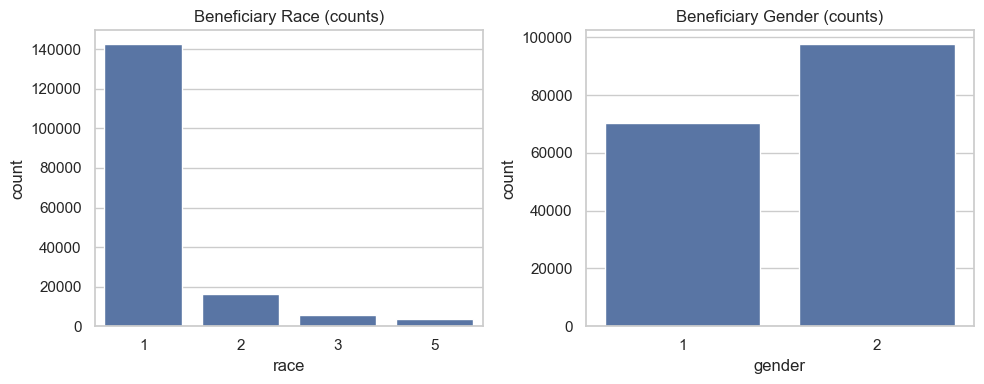

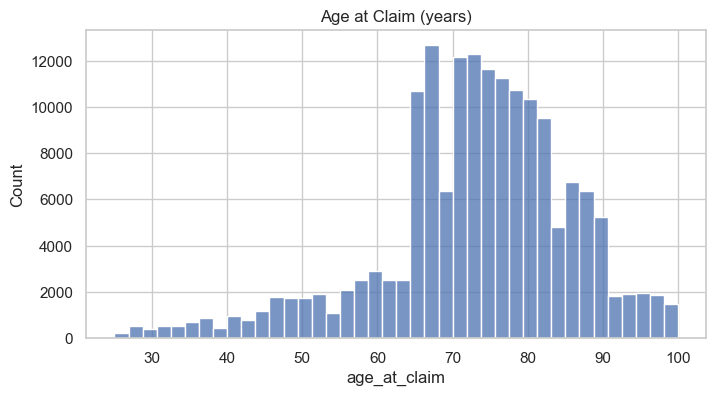

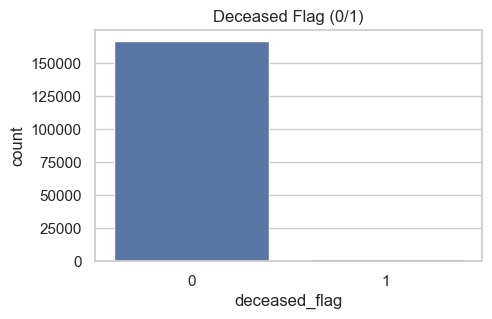

Top 15 overlap (beneficiaries appearing in both lists): 2


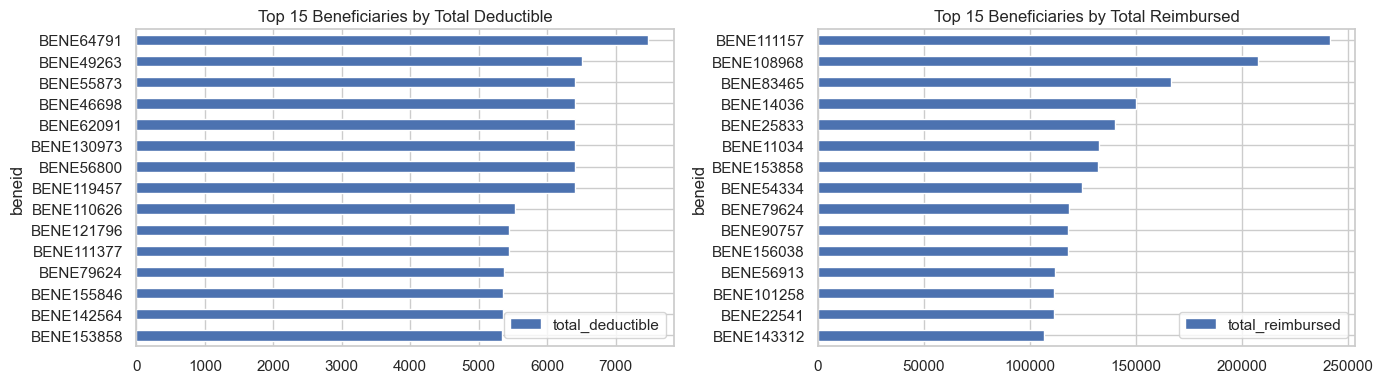

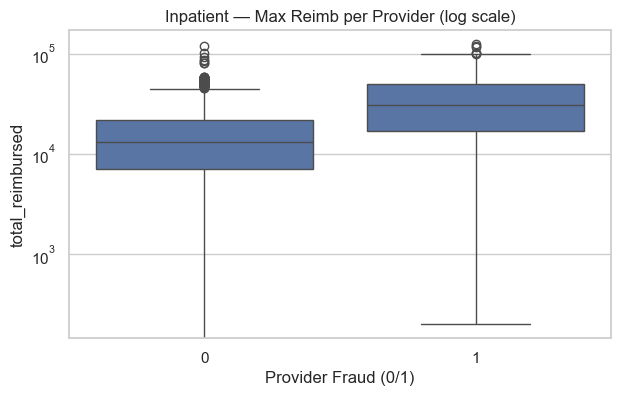

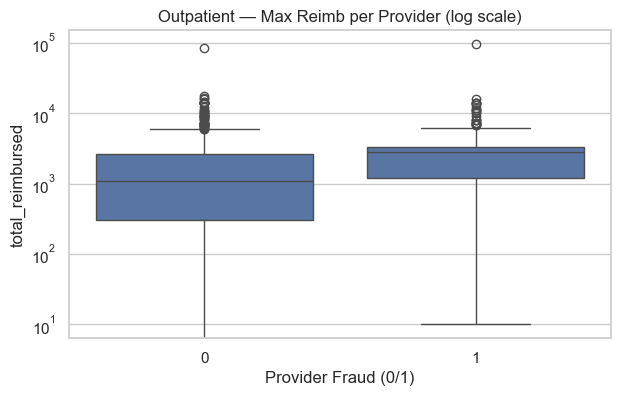

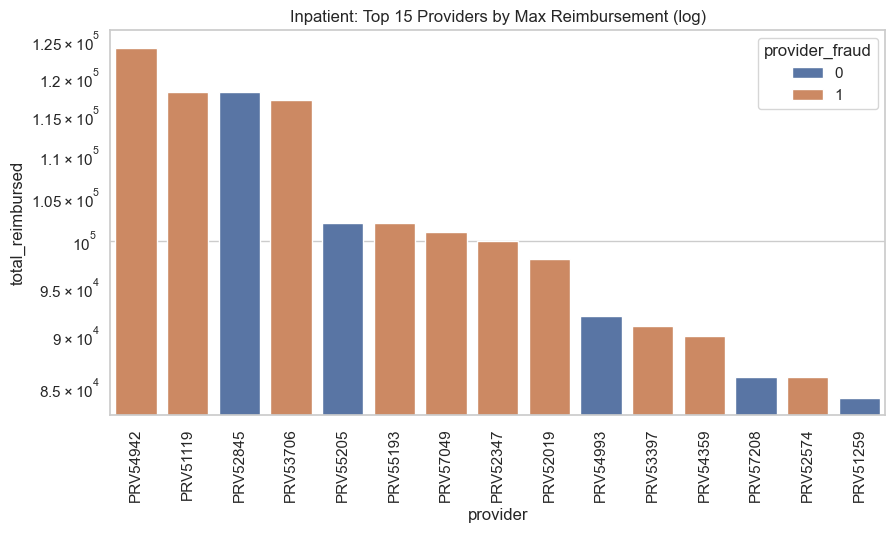

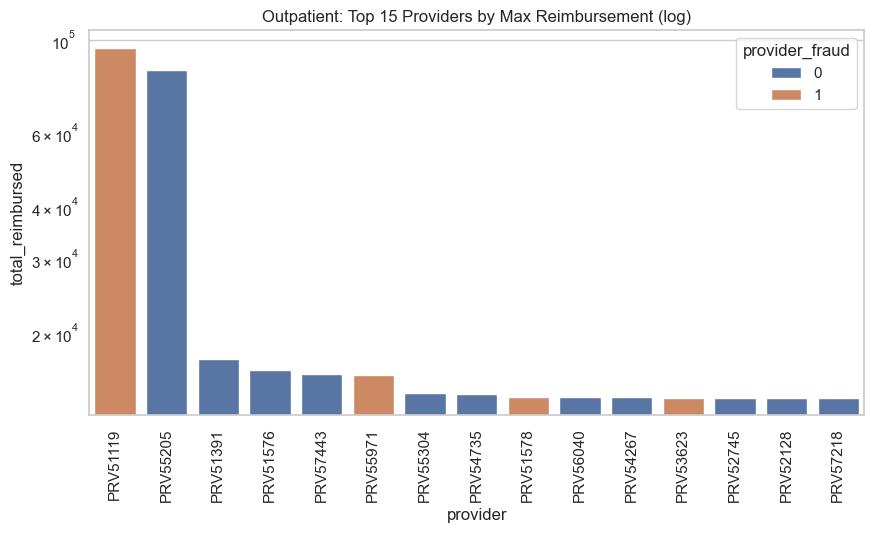

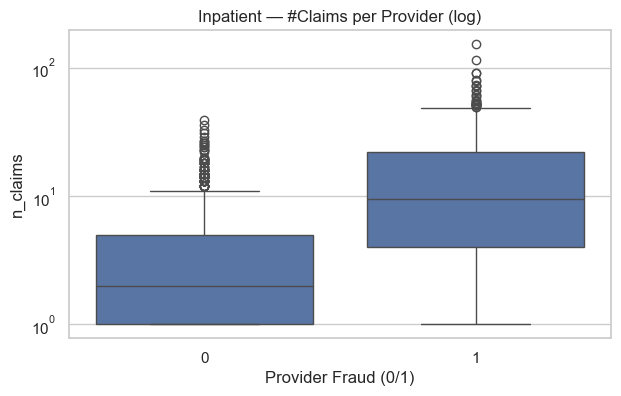

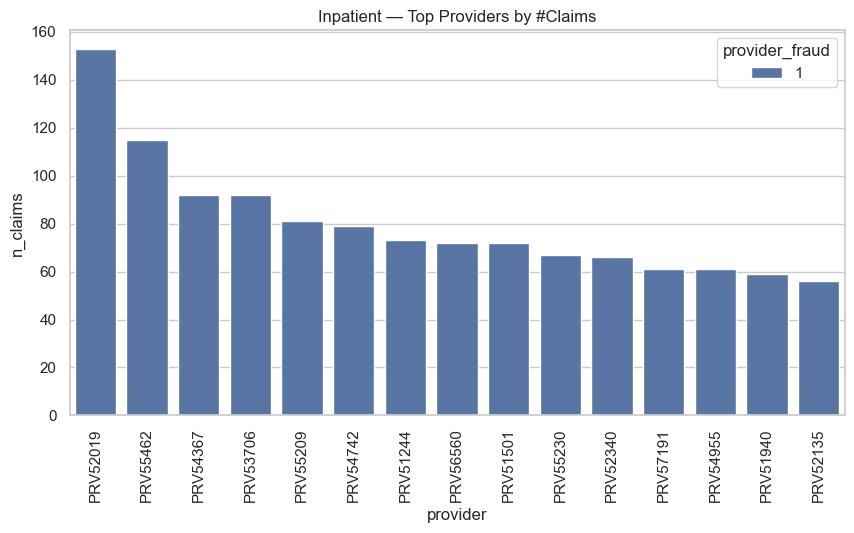

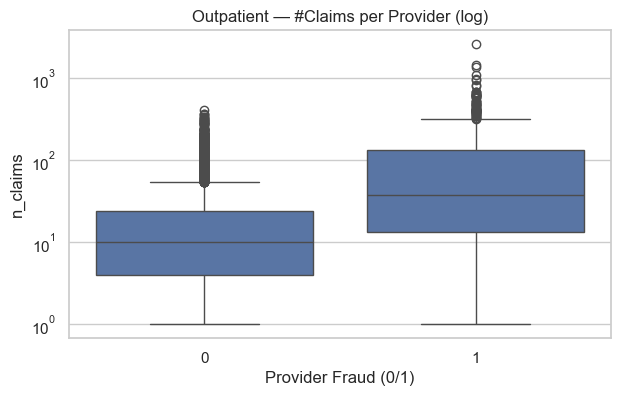

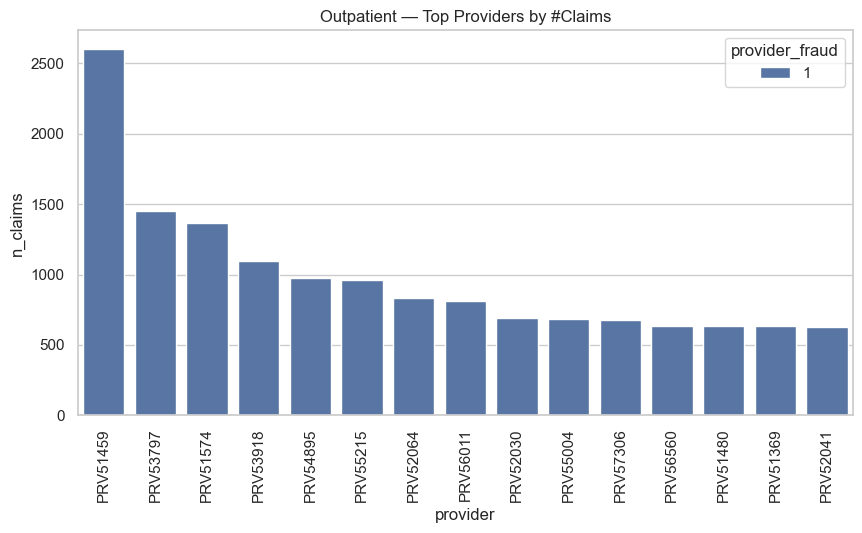

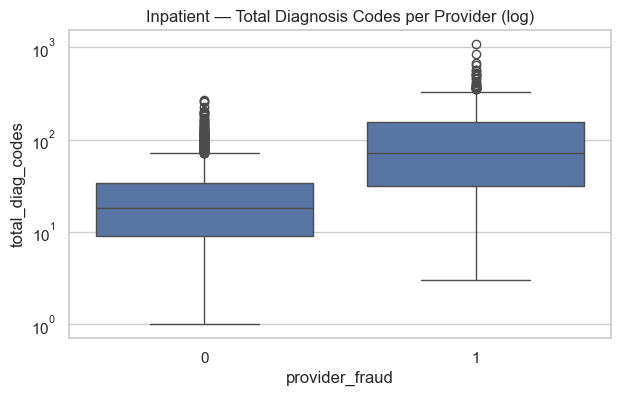

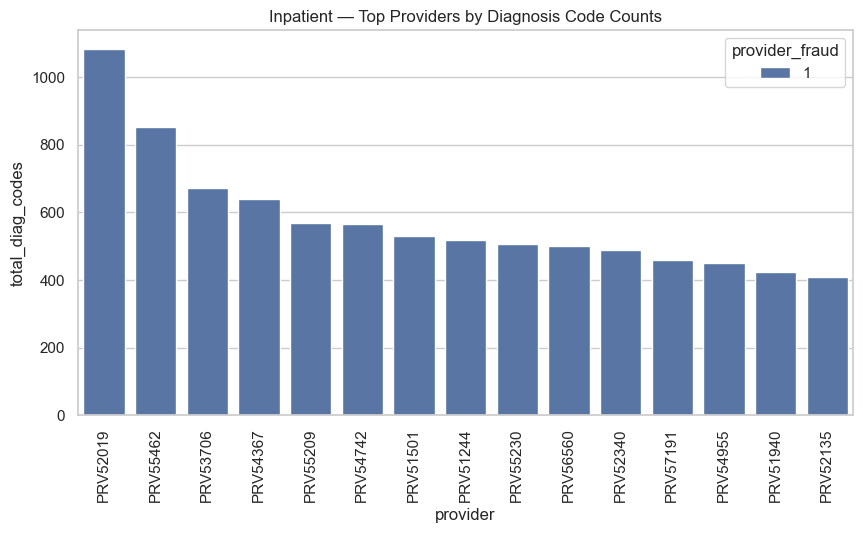

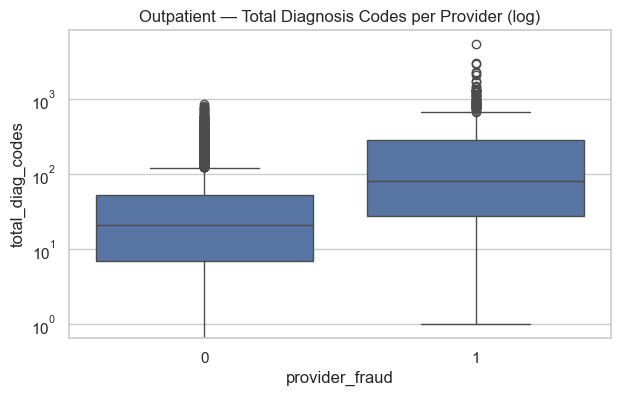

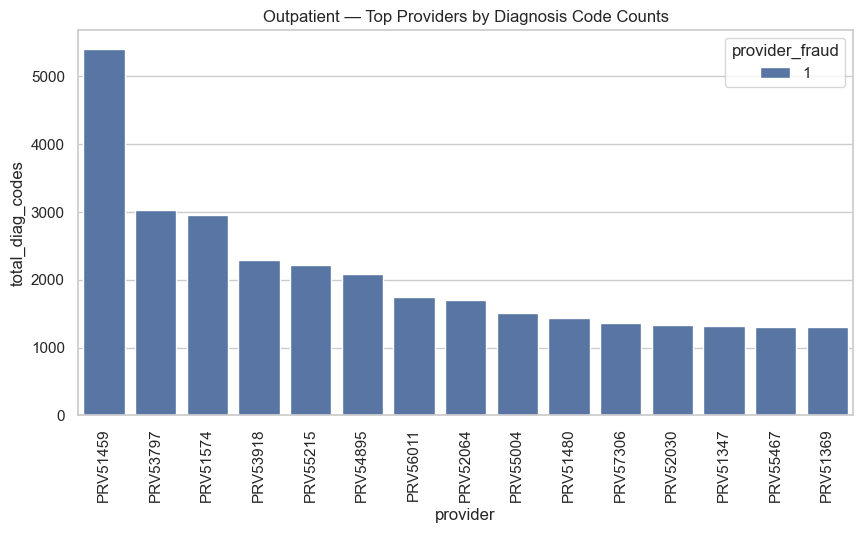

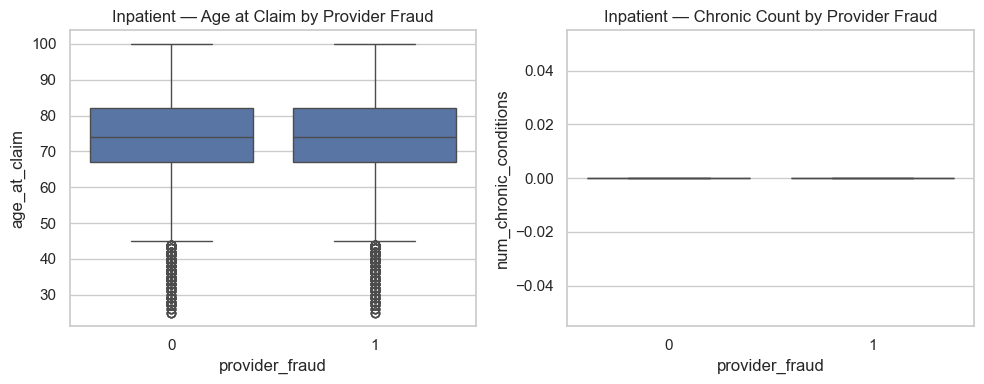

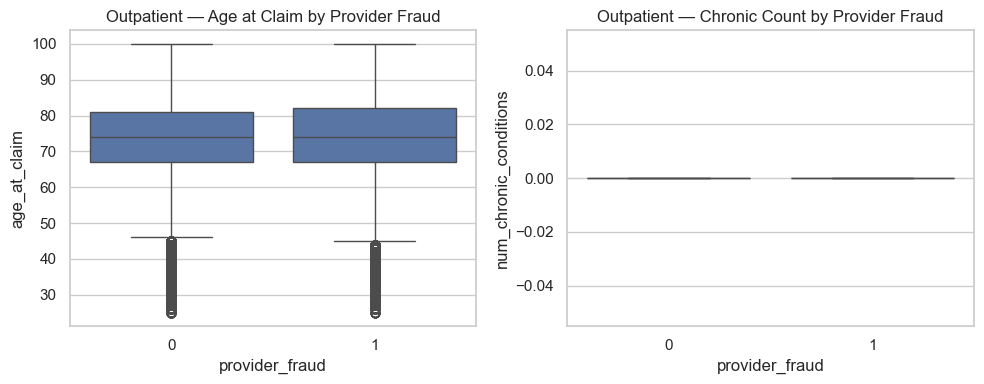

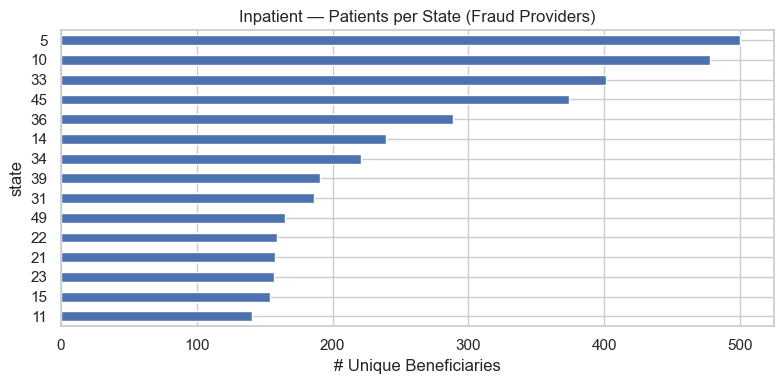

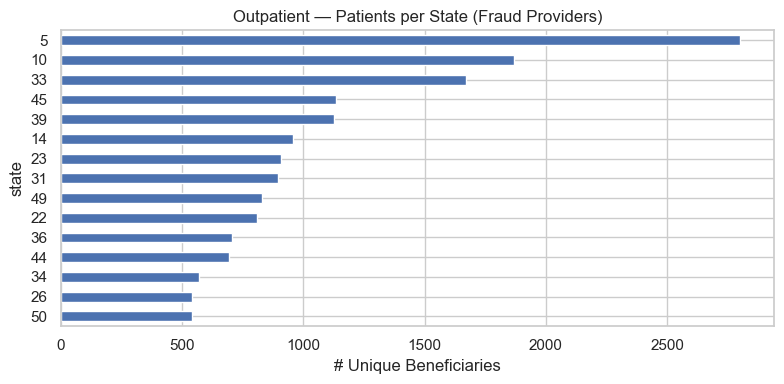

In [32]:
# ================================================
# 📊 Extra EDA: Beneficiaries & Provider Fraud Study
# ================================================
sns.set_theme(style="whitegrid")

# Ensure eda_df is defined. If not, try a sensible fallback from available variables.
if "eda_df" not in globals():
    for candidate in ("valid_ready_30", "valid_raw_30", "valid_base_30"):
        if candidate in globals():
            eda_df = globals()[candidate]
            break
    else:
        raise NameError(
            "eda_df is not defined and no fallback datasets found. "
            "Define eda_df or provide one of: valid_ready_30, valid_raw_30, valid_base_30."
        )


df = eda_df.copy()
y_col = "potentialfraud"

# ---------- Helper columns ----------
# Age at claim (years)
if {"claimstartdt","dob"}.issubset(df.columns):
    age_days = (df["claimstartdt"] - df["dob"]).dt.days
    df["age_at_claim"] = np.floor(age_days / 365.25)

# Deceased flag
if "dod" in df.columns:
    df["deceased_flag"] = df["dod"].notna().astype(int)

# Inpatient vs Outpatient proxy:
# Mark as inpatient if we have an admission date; else outpatient
df["is_inpatient"] = df["admissiondt"].notna().astype(int)

# Diagnosis count per claim (quick)
diag_cols = [c for c in df.columns if c.startswith("clmdiagnosiscode_")]
if diag_cols:
    df["diagnosis_count"] = df[diag_cols].notna().sum(axis=1)

# Chronic condition count per claim (map 2->1, 1->0 if present in raw)
chronic_cols = [c for c in df.columns if c.startswith("chroniccond_")]
if chronic_cols:
    chronic_bin = df[chronic_cols].replace({2:1, 1:0})
    df["num_chronic_conditions"] = chronic_bin.sum(axis=1)

# Total reimbursement & deductible (per claim)
amt_cols = [c for c in ["inscclaimamtreimbursed","deductibleamtpaid"] if c in df.columns]
if "inscclaimamtreimbursed" in df.columns:
    df["total_reimbursed"] = df["inscclaimamtreimbursed"]
if "deductibleamtpaid" in df.columns:
    df["total_deductible"] = df["deductibleamtpaid"]

# Provider-level fraud label (robust if mixed): take max across claims
if "provider" in df.columns and y_col in df.columns:
    prov_label = df.groupby("provider")[y_col].max()

# ==================================================
# 1) Beneficiary profile: race, gender, age, mortality
# ==================================================
fig, axes = plt.subplots(1, 2, figsize=(10,4))
if "race" in df.columns:
    sns.countplot(x="race", data=df, ax=axes[0])
    axes[0].set_title("Beneficiary Race (counts)")
if "gender" in df.columns:
    sns.countplot(x="gender", data=df, ax=axes[1])
    axes[1].set_title("Beneficiary Gender (counts)")
plt.tight_layout()
plt.show()

if "age_at_claim" in df.columns:
    plt.figure(figsize=(8,4))
    sns.histplot(df["age_at_claim"], bins=40, kde=False)
    plt.title("Age at Claim (years)")
    plt.show()

if "deceased_flag" in df.columns:
    plt.figure(figsize=(5,3))
    sns.countplot(x="deceased_flag", data=df)
    plt.title("Deceased Flag (0/1)")
    plt.show()

# Top beneficiaries by deductible & reimbursements + overlap
if {"beneid","total_deductible","total_reimbursed"}.issubset(df.columns):
    bene_agg = df.groupby("beneid").agg(
        total_deductible=("total_deductible","sum"),
        total_reimbursed=("total_reimbursed","sum")
    ).sort_values("total_reimbursed", ascending=False)

    topN = 15
    top_ded = bene_agg.nlargest(topN, "total_deductible")
    top_rei = bene_agg.nlargest(topN, "total_reimbursed")

    overlap = set(top_ded.index).intersection(set(top_rei.index))
    print(f"Top {topN} overlap (beneficiaries appearing in both lists): {len(overlap)}")

    fig, axes = plt.subplots(1,2, figsize=(14,4))
    top_ded.sort_values("total_deductible").plot(kind="barh", y="total_deductible", ax=axes[0])
    axes[0].set_title(f"Top {topN} Beneficiaries by Total Deductible")
    top_rei.sort_values("total_reimbursed").plot(kind="barh", y="total_reimbursed", ax=axes[1])
    axes[1].set_title(f"Top {topN} Beneficiaries by Total Reimbursed")
    plt.tight_layout(); plt.show()

# ==================================================
# 2) Provider fraud vs non-fraud: IP/OP comparisons
# ==================================================
if "provider" in df.columns:
    df["provider_fraud"] = df["provider"].map(prov_label).fillna(0).astype(int)

    # Split IP/OP
    ip_df = df[df["is_inpatient"] == 1].copy()
    op_df = df[df["is_inpatient"] == 0].copy()

    # ---- A) Max reimbursement per provider (distribution by fraud) ----
    def plot_max_reimb(data, title):
        if "total_reimbursed" not in data: 
            return
        prov_max = data.groupby(["provider","provider_fraud"])["total_reimbursed"].max().reset_index()
        plt.figure(figsize=(7,4))
        sns.boxplot(x="provider_fraud", y="total_reimbursed", data=prov_max)
        plt.yscale("log")
        plt.title(title + " — Max Reimb per Provider (log scale)")
        plt.xlabel("Provider Fraud (0/1)")
        plt.show()
        return prov_max

    ip_max = plot_max_reimb(ip_df, "Inpatient")
    op_max = plot_max_reimb(op_df, "Outpatient")

    # Top providers by max reimbursement (bars with fraud split)
    def plot_top_providers_by_max(prov_max, title, topN=15):
        if prov_max is None or prov_max.empty: 
            return
        top = prov_max.sort_values("total_reimbursed", ascending=False).head(topN)
        plt.figure(figsize=(10,5))
        sns.barplot(data=top, x="provider", y="total_reimbursed", hue="provider_fraud", dodge=False)
        plt.xticks(rotation=90); plt.yscale("log")
        plt.title(f"{title}: Top {topN} Providers by Max Reimbursement (log)")
        plt.show()

    plot_top_providers_by_max(ip_max, "Inpatient")
    plot_top_providers_by_max(op_max, "Outpatient")

    # ---- B) Number of claims per provider (distribution + top bars) ----
    def provider_claim_counts(data, title):
        counts = data.groupby(["provider","provider_fraud"])["claimid"].nunique().reset_index(name="n_claims")
        plt.figure(figsize=(7,4))
        sns.boxplot(x="provider_fraud", y="n_claims", data=counts)
        plt.yscale("log")
        plt.title(title + " — #Claims per Provider (log)")
        plt.xlabel("Provider Fraud (0/1)")
        plt.show()

        top = counts.sort_values("n_claims", ascending=False).head(15)
        plt.figure(figsize=(10,5))
        sns.barplot(data=top, x="provider", y="n_claims", hue="provider_fraud", dodge=False)
        plt.xticks(rotation=90)
        plt.title(title + " — Top Providers by #Claims")
        plt.show()
        return counts

    ip_counts = provider_claim_counts(ip_df, "Inpatient")
    op_counts = provider_claim_counts(op_df, "Outpatient")

    # ---- C) Diagnosis code counts per provider ----
    if "diagnosis_count" in df.columns:
        def diag_counts(data, title):
            agg = data.groupby(["provider","provider_fraud"])["diagnosis_count"].sum().reset_index(name="total_diag_codes")
            plt.figure(figsize=(7,4))
            sns.boxplot(x="provider_fraud", y="total_diag_codes", data=agg)
            plt.yscale("log")
            plt.title(title + " — Total Diagnosis Codes per Provider (log)")
            plt.show()

            top = agg.sort_values("total_diag_codes", ascending=False).head(15)
            plt.figure(figsize=(10,5))
            sns.barplot(data=top, x="provider", y="total_diag_codes", hue="provider_fraud", dodge=False)
            plt.xticks(rotation=90)
            plt.title(title + " — Top Providers by Diagnosis Code Counts")
            plt.show()
            return agg

        ip_diag = diag_counts(ip_df, "Inpatient")
        op_diag = diag_counts(op_df, "Outpatient")

    # ---- D) Avg patient age & chronic counts by provider fraud label (IP/OP) ----
    if {"age_at_claim","num_chronic_conditions"}.issubset(df.columns):
        for subset, title in [(ip_df,"Inpatient"), (op_df,"Outpatient")]:
            if subset.empty: 
                continue
            fig, axes = plt.subplots(1,2, figsize=(10,4))
            sns.boxplot(x="provider_fraud", y="age_at_claim", data=subset, ax=axes[0])
            axes[0].set_title(f"{title} — Age at Claim by Provider Fraud")
            sns.boxplot(x="provider_fraud", y="num_chronic_conditions", data=subset, ax=axes[1])
            axes[1].set_title(f"{title} — Chronic Count by Provider Fraud")
            plt.tight_layout(); plt.show()

    # ---- E) Patients per state for FRAUD providers (IP/OP) ----
    if "state" in df.columns:
        for subset, title in [(ip_df,"Inpatient"), (op_df,"Outpatient")]:
            sub = subset[subset["provider_fraud"] == 1]
            if sub.empty: 
                continue
            top_states = (sub.groupby("state")["beneid"].nunique()
                            .sort_values(ascending=False).head(15))
            plt.figure(figsize=(8,4))
            top_states.sort_values().plot(kind="barh")
            plt.title(f"{title} — Patients per State (Fraud Providers)")
            plt.xlabel("# Unique Beneficiaries")
            plt.tight_layout(); plt.show()



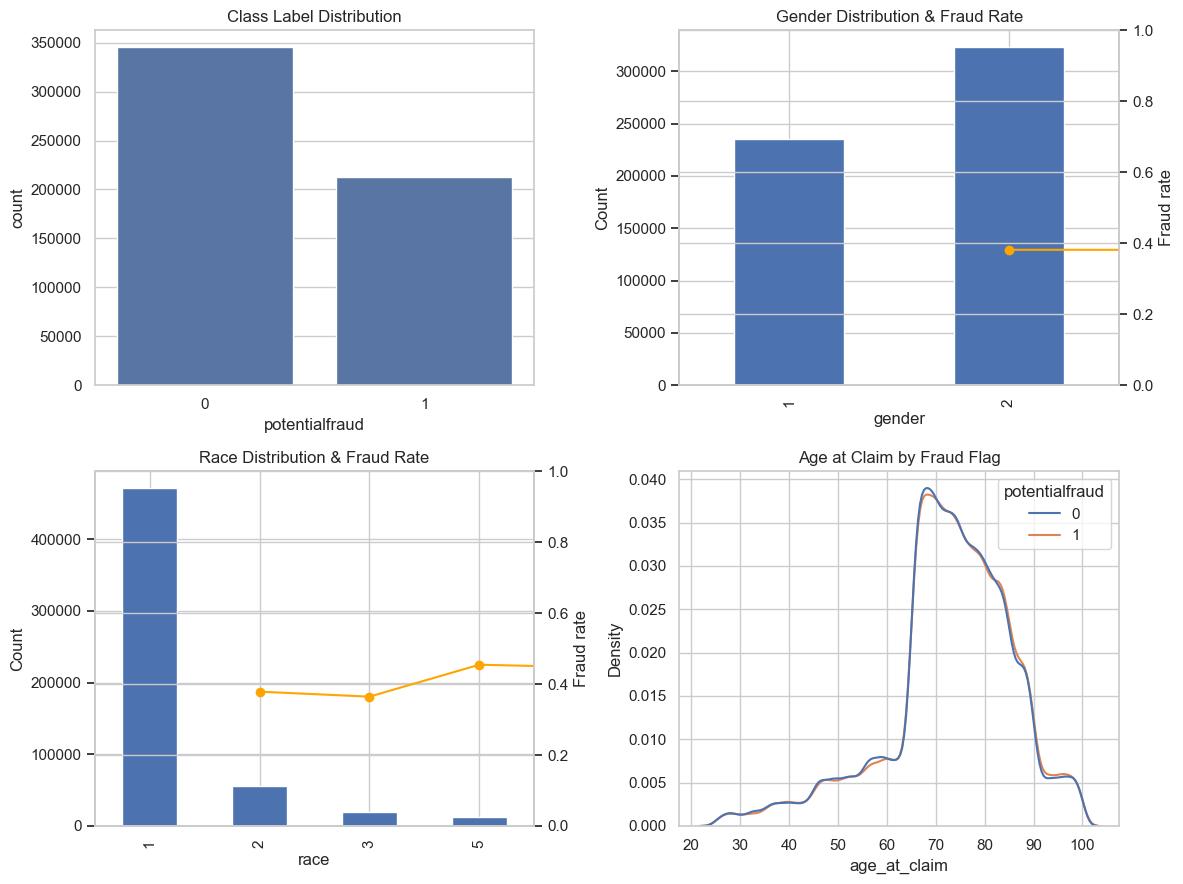

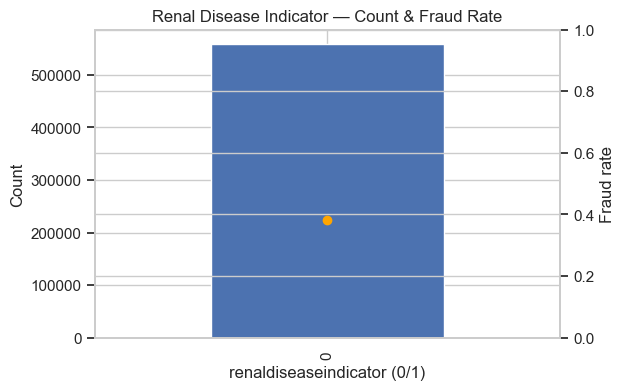

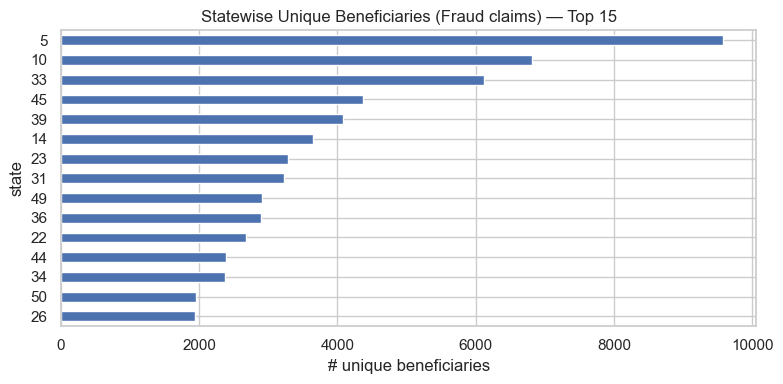

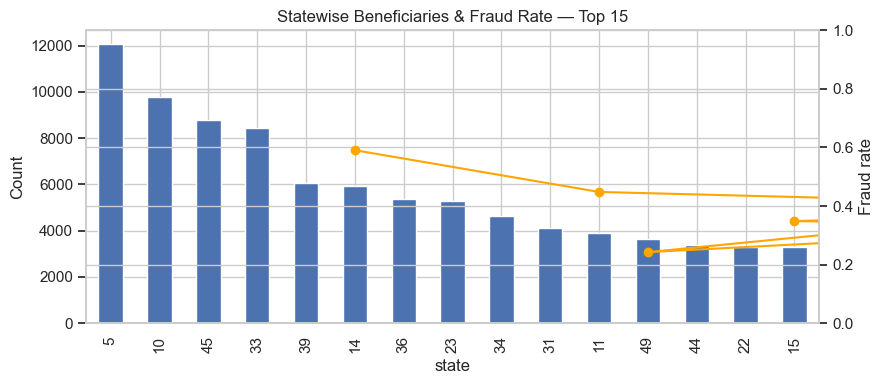

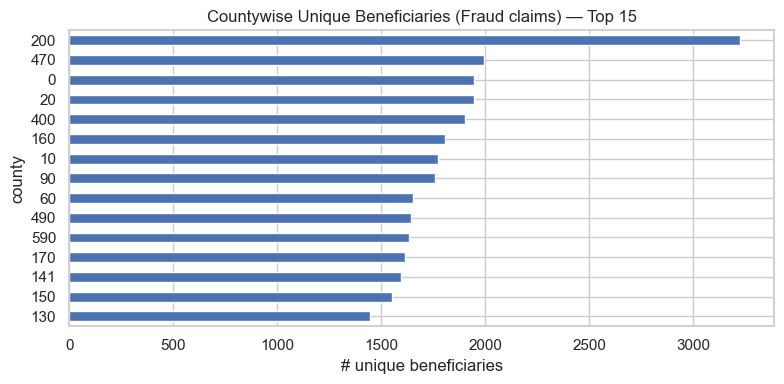

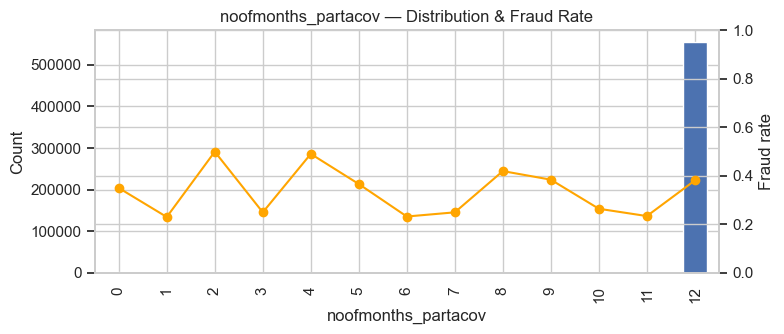

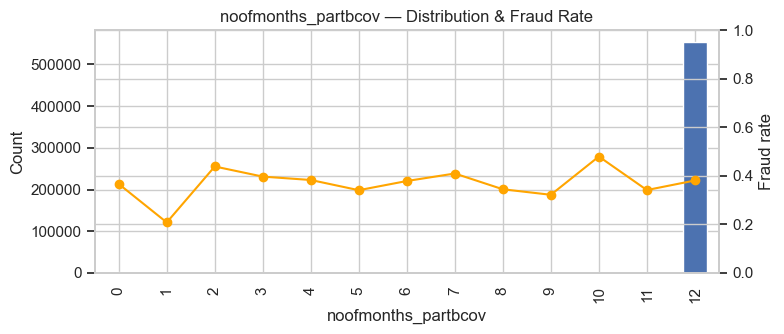

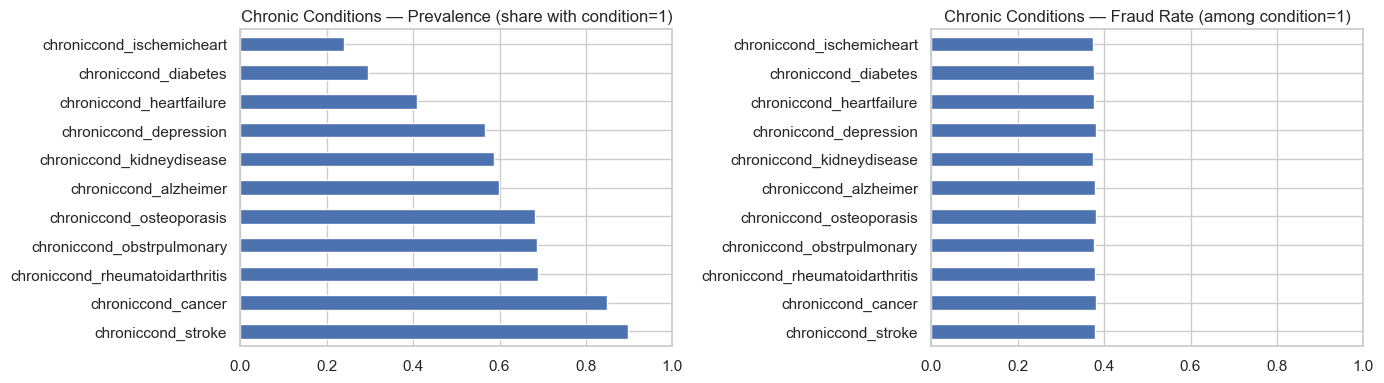

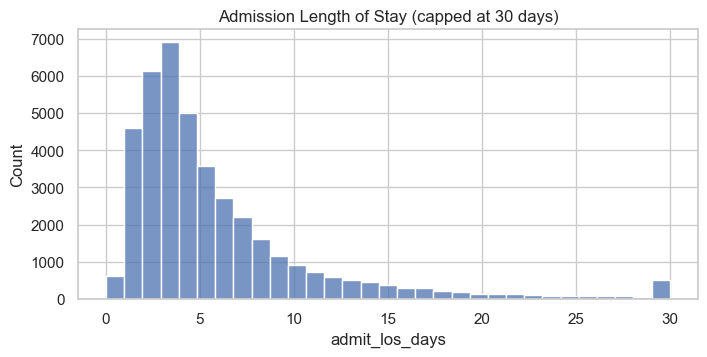

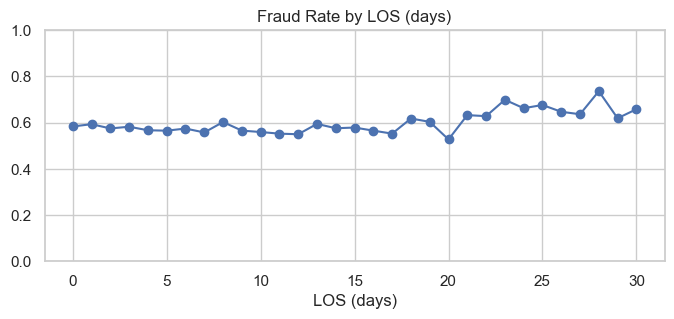

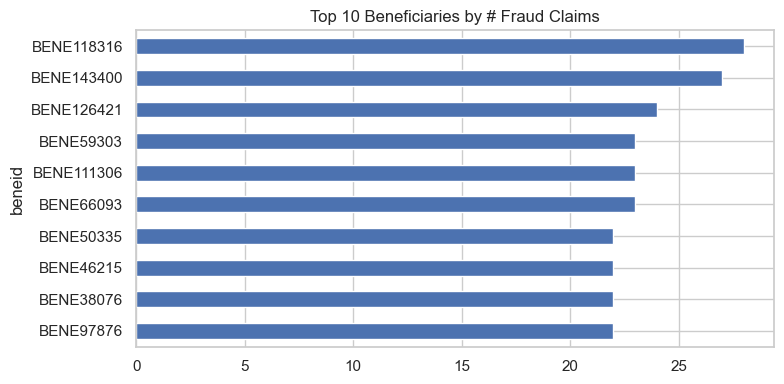

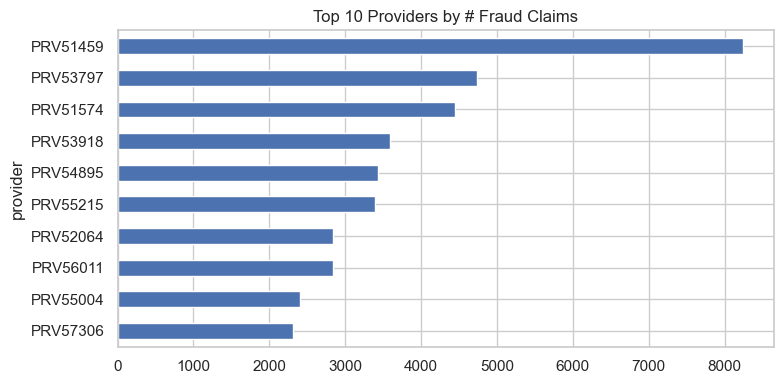

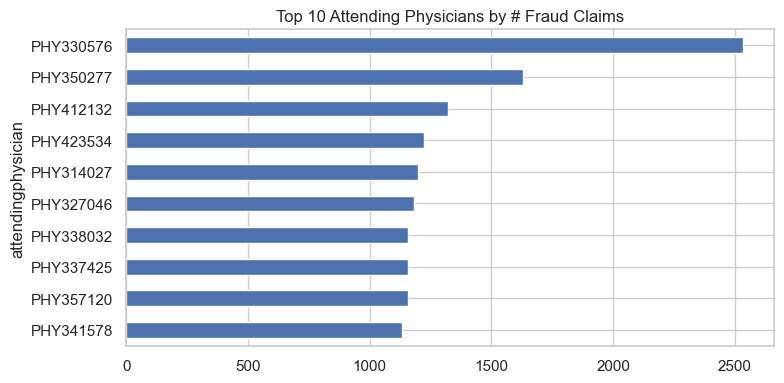

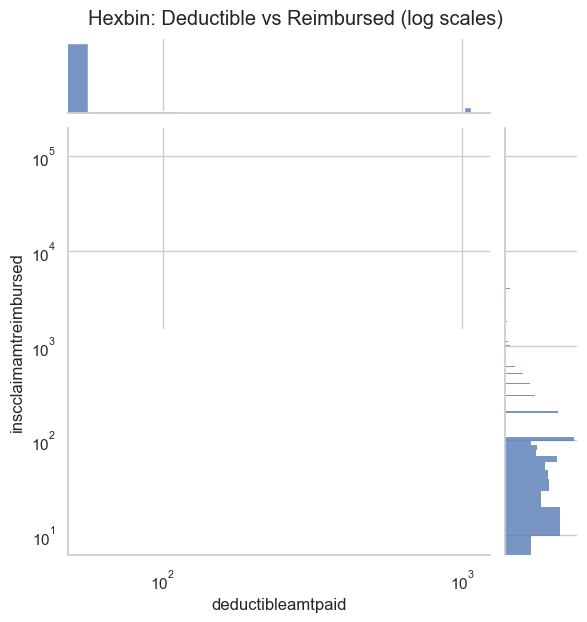

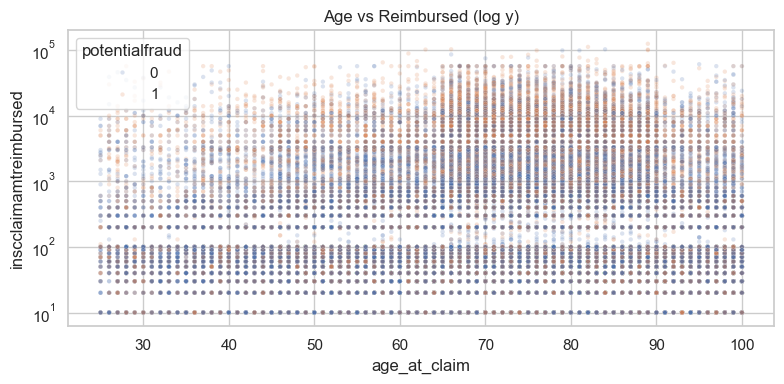

EDA on engineered features completed successfully!


In [33]:
# ================================================
# 📊 Extra EDA II — Beneficiaries, Coverage, Chronic, Geography, Bivariate
# ================================================

sns.set_theme(style="whitegrid")

# Set up the dataframe and target variable for EDA
df = train_merged.copy()
y = "potentialfraud"

# --- Helpers ---
def bar_with_rate(ax, counts, rate, title, xlabel):
    counts.plot(kind="bar", ax=ax)
    ax2 = ax.twinx()
    ax2.plot(rate.index, rate.values, marker="o", color='orange')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    ax2.set_ylabel("Fraud rate")
    ax2.set_ylim(0, 1)

def frac_by_cat(df, cat):
    t = pd.crosstab(df[cat], df[y], normalize="index").reindex(sorted(df[cat].dropna().unique()))
    t.columns = [f"non_fraud", "fraud"]
    return t

def safe_col(c): return c in df.columns

# Age at claim if not present
if {"claimstartdt","dob"}.issubset(df.columns) and "age_at_claim" not in df:
    age_days = (df["claimstartdt"] - df["dob"]).dt.days
    df["age_at_claim"] = np.floor(age_days / 365.25)

# Admission LOS if not present
if {"admissiondt","dischargedt"}.issubset(df.columns) and "admit_los_days" not in df:
    df["admit_los_days"] = (df["dischargedt"] - df["admissiondt"]).dt.days.clip(lower=0)

# =========================
# 1) Class/Gender/Race/Age
# =========================
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Class label distribution (again, for context)
sns.countplot(x=y, data=df, ax=axes[0,0])
axes[0,0].set_title("Class Label Distribution")

# Gender distribution + fraud rate
if safe_col("gender"):
    g_counts = df["gender"].value_counts().sort_index()
    g_rate   = df.groupby("gender")[y].mean().reindex(g_counts.index)
    bar_with_rate(axes[0,1], g_counts, g_rate, "Gender Distribution & Fraud Rate", "gender")
else:
    axes[0,1].axis("off")

# Race distribution + fraud rate
if safe_col("race"):
    r_counts = df["race"].value_counts().sort_index()
    r_rate   = df.groupby("race")[y].mean().reindex(r_counts.index)
    bar_with_rate(axes[1,0], r_counts, r_rate, "Race Distribution & Fraud Rate", "race")
else:
    axes[1,0].axis("off")

# Age histogram & kernel density split by fraud
if safe_col("age_at_claim"):
    sns.kdeplot(data=df.dropna(subset=["age_at_claim"]), x="age_at_claim", hue=y, common_norm=False, ax=axes[1,1])
    axes[1,1].set_title("Age at Claim by Fraud Flag")
else:
    axes[1,1].axis("off")

plt.tight_layout()
plt.show()

# =========================
# 2) Renal Disease Indicator
# =========================
if safe_col("renaldiseaseindicator"):
    fig, ax = plt.subplots(figsize=(6,4))
    r_counts = df["renaldiseaseindicator"].fillna(0).astype(int).value_counts().sort_index()
    r_rate   = df.assign(rdi=df["renaldiseaseindicator"].fillna(0).astype(int)).groupby("rdi")[y].mean().reindex(r_counts.index)
    bar_with_rate(ax, r_counts, r_rate, "Renal Disease Indicator — Count & Fraud Rate", "renaldiseaseindicator (0/1)")
    plt.show()

# =========================
# 3) Geography (State / County)
# =========================
if safe_col("state"):
    # Top states by beneficiary fraud counts
    state_fraud = df[df[y]==1].groupby("state")["beneid"].nunique().sort_values(ascending=False).head(15)
    plt.figure(figsize=(8,4))
    state_fraud.sort_values().plot(kind="barh")
    plt.title("Statewise Unique Beneficiaries (Fraud claims) — Top 15")
    plt.xlabel("# unique beneficiaries")
    plt.tight_layout(); plt.show()

    # Overall by state + fraud rate
    s_counts = df.groupby("state")["beneid"].nunique().sort_values(ascending=False).head(15)
    s_rate   = df.groupby("state")[y].mean().reindex(s_counts.index)
    fig, ax = plt.subplots(figsize=(9,4))
    bar_with_rate(ax, s_counts, s_rate, "Statewise Beneficiaries & Fraud Rate — Top 15", "state")
    plt.tight_layout(); plt.show()

if safe_col("county"):
    county_fraud = df[df[y]==1].groupby("county")["beneid"].nunique().sort_values(ascending=False).head(15)
    plt.figure(figsize=(8,4))
    county_fraud.sort_values().plot(kind="barh")
    plt.title("Countywise Unique Beneficiaries (Fraud claims) — Top 15")
    plt.xlabel("# unique beneficiaries")
    plt.tight_layout(); plt.show()

# =========================
# 4) Coverage (Part A / Part B months)
# =========================
for cov in ["noofmonths_partacov", "noofmonths_partbcov"]:
    if safe_col(cov):
        counts = df[cov].value_counts().sort_index()
        rate   = df.groupby(cov)[y].mean().reindex(counts.index)
        fig, ax = plt.subplots(figsize=(8,3.5))
        bar_with_rate(ax, counts, rate, f"{cov} — Distribution & Fraud Rate", cov)
        plt.tight_layout(); plt.show()

# =========================
# 5) Chronic conditions — prevalence & fraud rate
# =========================
chronic_cols = [c for c in df.columns if c.startswith("chroniccond_")]
if chronic_cols:
    # Convert CMS-style {1(no),2(yes)} → {0/1}
    chronic_bin = df[chronic_cols].replace({1:0, 2:1})
    prev = chronic_bin.mean().sort_values(ascending=False)
    
    # fraud rate per chronic = mean(y | chronic=1)
    fr = {}
    for c in chronic_bin.columns:
        if chronic_bin[c].sum() > 0:
            fr[c] = df.loc[chronic_bin[c]==1, y].mean()
        else:
            fr[c] = np.nan
    fr = pd.Series(fr).reindex(prev.index)

    fig, axes = plt.subplots(1,2, figsize=(14,4))
    prev.plot(kind="barh", ax=axes[0], title="Chronic Conditions — Prevalence (share with condition=1)")
    fr.plot(kind="barh", ax=axes[1], title="Chronic Conditions — Fraud Rate (among condition=1)")
    axes[0].set_xlim(0,1); axes[1].set_xlim(0,1)
    plt.tight_layout(); plt.show()

# =========================
# 6) Admission LOS (distribution + fraud rate by LOS)
# =========================
if safe_col("admit_los_days"):
    # Cap LOS for display
    los = df["admit_los_days"].clip(upper=30)
    plt.figure(figsize=(8,3.5))
    sns.histplot(los, bins=31)
    plt.title("Admission Length of Stay (capped at 30 days)")
    plt.show()

    # Fraud rate by LOS day
    grid = pd.DataFrame({"los": los, y: df[y]}).dropna()
    los_rate = grid.groupby("los")[y].mean()
    plt.figure(figsize=(8,3))
    los_rate.plot(marker="o")
    plt.title("Fraud Rate by LOS (days)")
    plt.ylim(0, 1); plt.xlabel("LOS (days)")
    plt.show()

# =========================
# 7) Top Beneficiaries/Providers/Physicians linked to fraud
# =========================
if {"beneid","provider","attendingphysician"}.issubset(df.columns):
    # Beneficiaries with most fraud claims
    top_bene = (df[df[y]==1]["beneid"].value_counts().head(10)).sort_values()
    plt.figure(figsize=(8,4))
    top_bene.plot(kind="barh")
    plt.title("Top 10 Beneficiaries by # Fraud Claims")
    plt.tight_layout(); plt.show()

    # Providers with most fraud claims
    top_prov = (df[df[y]==1]["provider"].value_counts().head(10)).sort_values()
    plt.figure(figsize=(8,4))
    top_prov.plot(kind="barh")
    plt.title("Top 10 Providers by # Fraud Claims")
    plt.tight_layout(); plt.show()

    # Attending physicians with most fraud claims
    top_phy = (df[df[y]==1]["attendingphysician"].dropna().value_counts().head(10)).sort_values()
    plt.figure(figsize=(8,4))
    top_phy.plot(kind="barh")
    plt.title("Top 10 Attending Physicians by # Fraud Claims")
    plt.tight_layout(); plt.show()

# =========================
# 8) Bivariate: amounts & age relationships
# =========================
# A) InscClaimAmtReimbursed vs DeductibleAmtPaid (hexbin)
if {"inscclaimamtreimbursed","deductibleamtpaid"}.issubset(df.columns):
    # sample for speed
    samp = df.sample(min(150000, len(df)), random_state=42)
    g = sns.jointplot(
        data=samp, x="deductibleamtpaid", y="inscclaimamtreimbursed",
        kind="hex", height=6
    )
    g.ax_joint.set_yscale("log"); g.ax_joint.set_xscale("log")
    g.figure.suptitle("Hexbin: Deductible vs Reimbursed (log scales)", y=1.02)
    plt.show()

# B) Age vs reimbursement (stratified by fraud)
if {"age_at_claim","inscclaimamtreimbursed"}.issubset(df.columns):
    samp = df.sample(min(150000, len(df)), random_state=43)
    plt.figure(figsize=(8,4))
    sns.scatterplot(
        data=samp, x="age_at_claim", y="inscclaimamtreimbursed",
        hue=y, alpha=0.2, s=10
    )
    plt.yscale("log"); plt.title("Age vs Reimbursed (log y)")
    plt.tight_layout(); plt.show()

print("EDA on engineered features completed successfully!")


#### EDA Summary & Insights

##### Class Distribution
- **Fraud rate:** 38.1% (moderate imbalance)  
- Both classes are reasonably represented — **no SMOTE needed**.  
- Use **stratified or group-based CV** to preserve this ratio.


##### Temporal Patterns
- Claims are concentrated in **2009**, with a small tail in late 2008.  
- Suggests this is a **single-year dataset**, not longitudinal — treat **`claimstartdt`** and **`claimenddt`** mainly as **seasonal or duration** features, not time-series trends.  
- **Claim duration** is highly right-skewed — most are **0–1 day**, with rare long stays up to ~35 days.  
  - Likely outpatient or short inpatient visits dominate.


##### Financial Features
- **`deductibleamtpaid`** and **`inscclaimamtreimbursed`** show the strongest positive correlation with `potentialfraud`.  
  - Fraudulent claims tend to have **higher reimbursements** and **larger deductibles**.
- Heavy-tailed distributions → keep **`log1p`** or **`arcsinh`** transformations.  
- Negative or extreme reimbursement values exist — cap (winsorize) at 99.5th percentile.


##### Claim Metadata
- **Procedure & diagnosis codes** have extreme missingness (>90% in later columns).  
  - Keep these as **presence/absence flags**, not raw numeric codes.  
  - Columns like `clmprocedurecode_5+` are almost entirely missing → drop after flag creation.
- **Admission/discharge dates** exist for ~7% of claims → strong signal for inpatient claims.


##### Provider & Physician Behavior
- Very **long-tailed frequency distributions**:
  - A handful of providers and physicians account for most claims.
  - This supports including **OOF-leakage-safe frequency & fraud ratio encodings**.
- Top 10 providers each handle 1–2% of total claims.


##### Chronic Conditions & Demographics
- Chronic disease indicators are **mostly binary (1/2)**, fairly balanced across classes.
- Slight differences in county and chronic disease prevalence between fraudulent vs. non-fraudulent claims, but no dominant demographic signal.


##### Correlation Structure
- Overall low inter-feature correlation — indicates engineered features are **largely orthogonal**.  
- Some clusters within diagnosis/procedure codes → prune highly correlated ones (|r|>0.95).


##### Data Quality & Leakage Check
- No columns explicitly containing the word `"fraud"` except the label → **no target leakage** detected.  
- Several high-missing columns and skewed financial features need **imputation, winsorization**, and **flag creation** before modeling.

##### Key Takeaways
| Category | Action |
|-----------|---------|
| Missing data | Drop >99.5% missing columns; add presence flags for 50–99% missing ones |
| Outliers | Cap extreme reimbursement/deductible values |
| Sparse codes | Keep only Top-K presence features |
| Leakage | None detected |
| Balance | 38% fraud — mild imbalance, no SMOTE needed |
| Next step | Feature cleanup → selection → model training |


### Drop Missing Data
Drop any column with >99.5% missing unless it’s only used to form a presence flag.

In [34]:
# Missingness flags for high-missing columns (>99.5%)
hi_missing = X_train.isna().mean().sort_values(ascending=False)
flag_cols = [c for c in X_train.columns if hi_missing.get(c,0) > 0.995]
for c in flag_cols:
    for df in (X_train, X_valid, X_test):
        if c in df:
            df[f'{c}_is_missing'] = df[c].isna().astype(int)

# Impute remaining NaNs numerics with 0
for df in (X_train, X_valid, X_test):
    num = df.select_dtypes(include=[np.number]).columns
    df[num] = df[num].fillna(0)


## Data Preparation & Scaling (No Leakage)

In [ ]:
print(" === DATA PREPARATION: FEATURE SELECTION & SCALING ===\n")
from sklearn.preprocessing import StandardScaler 

# Prepare training data
X_train = train_ready_70.drop(columns=[y_col]).copy()
y_train = train_ready_70[y_col].copy()

# Prepare validation data
X_val = valid_ready_30.drop(columns=[y_col]).copy()
y_val = valid_ready_30[y_col].copy()

# Prepare test data (no labels)
X_test = test_ready.copy()

print(f"Initial shapes:")
print(f"  Training set: {X_train.shape}")
print(f"  Validation set: {X_val.shape}")
print(f"  Test set: {X_test.shape}\n")

# ========================================
# STEP 0: Align columns across all datasets
# ========================================
print("🔧 Step 0: Aligning columns across train/val/test...")

# Get common columns (intersection of all three sets)
common_cols = list(set(X_train.columns) & set(X_val.columns) & set(X_test.columns))
print(f"   Common columns across all sets: {len(common_cols)}")

# Identify columns unique to each set
train_only = set(X_train.columns) - set(X_test.columns)
val_only = set(X_val.columns) - set(X_test.columns)
test_only = set(X_test.columns) - set(X_train.columns)

if train_only:
    print(f"   Columns only in train: {len(train_only)} (will be kept)")
    print(f"      Examples: {list(train_only)[:3]}")
if val_only:
    print(f"   Columns only in validation: {len(val_only)} (will be kept)")
if test_only:
    print(f"   Columns only in test: {len(test_only)} (will be added to train/val)")

# Add missing columns to each dataset (fill with 0)
for col in set(X_train.columns) | set(X_val.columns) | set(X_test.columns):
    if col not in X_train.columns:
        X_train[col] = 0
    if col not in X_val.columns:
        X_val[col] = 0
    if col not in X_test.columns:
        X_test[col] = 0

# Ensure same column order
all_cols = sorted(set(X_train.columns) | set(X_val.columns) | set(X_test.columns))
X_train = X_train[all_cols]
X_val = X_val[all_cols]
X_test = X_test[all_cols]

print(f"   ✅ All datasets aligned: {len(all_cols)} features\n")

# ========================================
# STEP 1: Remove ID and redundant columns
# ========================================
print("Step 1: Removing ID and redundant columns...")

# Identify ID columns and other non-predictive features
id_keywords = [
    'claimid', 'beneid', 'provider', 'physician',  # ID columns
    'dob', 'dod', 'claimstartdt', 'claimenddt',    # Date columns
    'admissiondt', 'dischargedt',                   # Date columns
    'clmdiagnosiscode', 'clmprocedurecode',         # Actual codes (not derived features)
    'deathdt'                                        # Date column
]

# Find columns to drop (case-insensitive matching)
drop_cols = []
for col in X_train.columns:
    col_lower = col.lower()
    # Drop if column name contains any ID keyword
    if any(keyword in col_lower for keyword in id_keywords):
        # Exception: keep derived features that use these IDs (e.g., _count, _mean, _fraud_rate)
        if not any(suffix in col_lower for suffix in ['_count', '_mean', '_sum', '_std', '_fraud', '_rate', '_ratio', '_pct', '_flag', '_bin', '_presence', '_is_missing']):
            drop_cols.append(col)

drop_cols = list(set(drop_cols))  # Remove duplicates
print(f"   Dropping {len(drop_cols)} ID/date columns")
if drop_cols:
    print(f"   Examples: {drop_cols[:5]}")
    X_train = X_train.drop(columns=drop_cols, errors='ignore')
    X_val = X_val.drop(columns=drop_cols, errors='ignore')
    X_test = X_test.drop(columns=drop_cols, errors='ignore')

print(f"   Remaining features: {X_train.shape[1]}\n")

# ========================================
# STEP 2: Identify binary and non-binary features
# ========================================
print("Step 2: Identifying binary vs continuous features...")

binary_cols = []
continuous_cols = []

for col in X_train.columns:
    # Check unique values (excluding NaN)
    unique_vals = X_train[col].dropna().unique()
    n_unique = len(unique_vals)
    
    # Binary: exactly 2 unique values (typically 0/1 or 1/2)
    # Also check if values are in [0,1] or [1,2] range
    if n_unique == 2 or (n_unique <= 3 and set(unique_vals).issubset({0, 1, 2})):
        binary_cols.append(col)
    else:
        continuous_cols.append(col)

print(f"   Binary features: {len(binary_cols)}")
print(f"   Continuous features: {len(continuous_cols)}\n")

# ========================================
# STEP 3: Scale ONLY continuous features
# ========================================
print("Step 3: Scaling continuous features only...")
print("   (Binary features will NOT be scaled)\n")

# Convert all features to numeric (coerce errors to NaN)
print("   Converting features to numeric...")
for col in X_train.columns:
    if col in X_train.columns:
        X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    if col in X_val.columns:
        X_val[col] = pd.to_numeric(X_val[col], errors='coerce')
    if col in X_test.columns:
        X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

# Fill NaN values
print("   Filling NaN values with 0...")
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)
X_test = X_test.fillna(0)

# Scale ONLY continuous features that exist in all datasets
continuous_to_scale = [c for c in continuous_cols if c in X_train.columns and c in X_val.columns and c in X_test.columns]

if continuous_to_scale:
    print(f"   Fitting StandardScaler on {len(continuous_to_scale)} continuous features...")
    scaler = StandardScaler()
    
    # ✅ CRITICAL: Fit scaler ONLY on training data
    X_train[continuous_to_scale] = scaler.fit_transform(X_train[continuous_to_scale])
    X_val[continuous_to_scale] = scaler.transform(X_val[continuous_to_scale])
    X_test[continuous_to_scale] = scaler.transform(X_test[continuous_to_scale])
    print("Continuous features scaled (no data leakage)")
else:
    print("No continuous features to scale")

if binary_cols:
    print(f"{len(binary_cols)} binary features kept unscaled")
print()

# ========================================
# STEP 4: Final cleanup
# ========================================
print("🧹 Step 4: Final cleanup...")

# Reset indices for clean modeling
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True).astype(int)
X_val = X_val.reset_index(drop=True)
y_val = y_val.reset_index(drop=True).astype(int)
X_test = X_test.reset_index(drop=True)

print("✅ Data preparation completed!\n")

# ========================================
# SUMMARY
# ========================================
print("=" * 60)
print("FINAL DATASET SUMMARY")
print("=" * 60)
print(f"Training set:   {X_train.shape[0]:,} samples × {X_train.shape[1]} features")
print(f"Validation set: {X_val.shape[0]:,} samples × {X_val.shape[1]} features")
print(f"Test set:       {X_test.shape[0]:,} samples × {X_test.shape[1]} features")
print()
print(f"Feature breakdown:")
print(f"  Binary features:     {len(binary_cols)}")
print(f"  Continuous features: {len(continuous_to_scale)}")
print(f"  Total features:      {X_train.shape[1]}")
print()
print("Training set class distribution:")
print(y_train.value_counts())
print(f"  Fraud ratio: {y_train.mean():.3f}")
print()
print("Validation set class distribution:")
print(y_val.value_counts())
print(f"  Fraud ratio: {y_val.mean():.3f}")
print("=" * 60)
print("NO DATA LEAKAGE - All preprocessing fit on training data only!")
print("=" * 60)


📊 === DATA PREPARATION: FEATURE SELECTION & SCALING ===

Initial shapes:
  Training set: (390309, 173)
  Validation set: (167902, 173)
  Test set: (135392, 173)

🔧 Step 0: Aligning columns across train/val/test...
   Common columns across all sets: 171
   Columns only in train: 2 (will be kept)
      Examples: ['hasproc_3772.0', 'hasdiag_27800.0']
   Columns only in validation: 2 (will be kept)
   Columns only in test: 2 (will be added to train/val)
   ✅ All datasets aligned: 175 features

🗑️  Step 1: Removing ID and redundant columns...
   Dropping 37 ID/date columns
   Examples: ['clmdiagnosiscode_2', 'days_claim_to_dod', 'dob', 'clmdiagnosiscode_7', 'beneid']
   Remaining features: 138

🔍 Step 2: Identifying binary vs continuous features...
   Binary features: 100
   Continuous features: 38

🔄 Step 3: Scaling continuous features only...
   (Binary features will NOT be scaled)

   Converting features to numeric...
   Filling NaN values with 0...
   Fitting StandardScaler on 38 contin

## Baseline Model Training

In [ ]:
print("=== BASELINE MODEL TRAINING WITH CROSS-VALIDATION ===\n")

# Import additional models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

# Initialize models with default parameters
models = {
    # logistic
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'ElasticNet Logistic': LogisticRegression(penalty='elasticnet', solver='saga',
                                              l1_ratio=0.5, max_iter=2000, random_state=42),
    # tree-based models
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    # boosting models
    'XGBoost': XGBClassifier(random_state=42, eval_metric='auc', n_jobs=-1),
    'LightGBM': LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=42),
    #probabilistic model
    'Gaussian Naive Bayes': GaussianNB(),
}

# Store results
cv_results = {}
val_results = {}

# Cross-validation setup
cv_folds = 5
skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

print(f"Training {len(models)} baseline models with {cv_folds}-fold cross-validation...\n")
print("=" * 100)

for model_name, model in models.items():
    print(f"\nTraining: {model_name}")
    print("-" * 100)
    
    # Cross-validation on training set (70%)
    print(f"Running {cv_folds}-fold CV on training set...")
    cv_scores = cross_val_score(
        model, X_train, y_train, 
        cv=skf, 
        scoring='roc_auc', 
        n_jobs=-1
    )
    
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    cv_results[model_name] = {
        'scores': cv_scores,
        'mean': cv_mean,
        'std': cv_std
    }
    
    print(f"CV ROC-AUC: {cv_mean:.4f} (+/- {cv_std:.4f})")
    
    # Train on full training set and evaluate on validation set
    print(f"Training on full 70% and validating on 30%...")
    model.fit(X_train, y_train)
    
    # Predictions on validation set
    y_val_pred = model.predict(X_val)
    y_val_prob = model.predict_proba(X_val)[:, 1]
    
    # Calculate metrics
    val_accuracy = accuracy_score(y_val, y_val_pred)
    val_precision = precision_score(y_val, y_val_pred, zero_division=0)
    val_recall = recall_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred)
    val_roc_auc = roc_auc_score(y_val, y_val_prob)
    
    val_results[model_name] = {
        'accuracy': val_accuracy,
        'precision': val_precision,
        'recall': val_recall,
        'f1': val_f1,
        'roc_auc': val_roc_auc,
        'predictions': y_val_pred,
        'probabilities': y_val_prob,
        'model': model
    }
    
    print(f"  📊 Validation Results:")
    print(f"     • Accuracy:  {val_accuracy:.4f}")
    print(f"     • Precision: {val_precision:.4f}")
    print(f"     • Recall:    {val_recall:.4f}")
    print(f"     • F1-Score:  {val_f1:.4f}")
    print(f"     • ROC-AUC:   {val_roc_auc:.4f}")

print("\n" + "=" * 100)
print("All baseline models trained successfully!\n")

🚀 === BASELINE MODEL TRAINING WITH CROSS-VALIDATION ===

Training 9 baseline models with 5-fold cross-validation...


📌 Training: Logistic Regression
----------------------------------------------------------------------------------------------------
  ⏳ Running 5-fold CV on training set...


/opt/anaconda3/envs/bt4012/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/envs/bt4012/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#log

  ✅ CV ROC-AUC: 0.6432 (+/- 0.0018)
  ⏳ Training on full 70% and validating on 30%...
  📊 Validation Results:
     • Accuracy:  0.6411
     • Precision: 0.6355
     • Recall:    0.1405
     • F1-Score:  0.2301
     • ROC-AUC:   0.6437

📌 Training: ElasticNet Logistic
----------------------------------------------------------------------------------------------------
  ⏳ Running 5-fold CV on training set...
  ✅ CV ROC-AUC: 0.6445 (+/- 0.0016)
  ⏳ Training on full 70% and validating on 30%...
  📊 Validation Results:
     • Accuracy:  0.6409
     • Precision: 0.6350
     • Recall:    0.1398
     • F1-Score:  0.2292
     • ROC-AUC:   0.6452

📌 Training: Random Forest
----------------------------------------------------------------------------------------------------
  ⏳ Running 5-fold CV on training set...
  ✅ CV ROC-AUC: 0.8963 (+/- 0.0018)
  ⏳ Training on full 70% and validating on 30%...
  📊 Validation Results:
     • Accuracy:  0.7496
     • Precision: 0.7385
     • Recall:    0.5328
 

In [ ]:
print("=== MODEL PERFORMANCE COMPARISON ===\n")

# Create summary DataFrame
summary_data = []
for model_name in models.keys():
    summary_data.append({
        'Model': model_name,
        'CV ROC-AUC (Mean)': cv_results[model_name]['mean'],
        'CV ROC-AUC (Std)': cv_results[model_name]['std'],
        'Val Accuracy': val_results[model_name]['accuracy'],
        'Val Precision': val_results[model_name]['precision'],
        'Val Recall': val_results[model_name]['recall'],
        'Val F1-Score': val_results[model_name]['f1'],
        'Val ROC-AUC': val_results[model_name]['roc_auc']
    })

results_df = pd.DataFrame(summary_data)
results_df = results_df.sort_values('Val ROC-AUC', ascending=False)

print("Model Performance Summary:")
print(results_df.to_string(index=False))
print("\n")

# Find best model
best_model_name = results_df.iloc[0]['Model']
best_roc_auc = results_df.iloc[0]['Val ROC-AUC']
print(f"Best Model: {best_model_name} with Validation ROC-AUC = {best_roc_auc:.4f}\n")

📊 === MODEL PERFORMANCE COMPARISON ===

Model Performance Summary:
               Model  CV ROC-AUC (Mean)  CV ROC-AUC (Std)  Val Accuracy  Val Precision  Val Recall  Val F1-Score  Val ROC-AUC
            CatBoost           0.947743          0.001428      0.832456       0.821528    0.716946      0.765682     0.913589
HistGradientBoosting           0.922452          0.000785      0.831813       0.801527    0.743651      0.771505     0.907953
             XGBoost           0.953038          0.000964      0.829323       0.810663    0.721501      0.763488     0.907627
            LightGBM           0.922707          0.001285      0.827322       0.796915    0.735072      0.764745     0.905258
       Random Forest           0.896308          0.001797      0.749574       0.738502    0.532773      0.618991     0.833894
         Extra Trees           0.821503          0.004205      0.669367       0.667747    0.266815      0.381280     0.719691
 ElasticNet Logistic           0.644531          0.

📈 === VISUALIZING MODEL PERFORMANCE ===



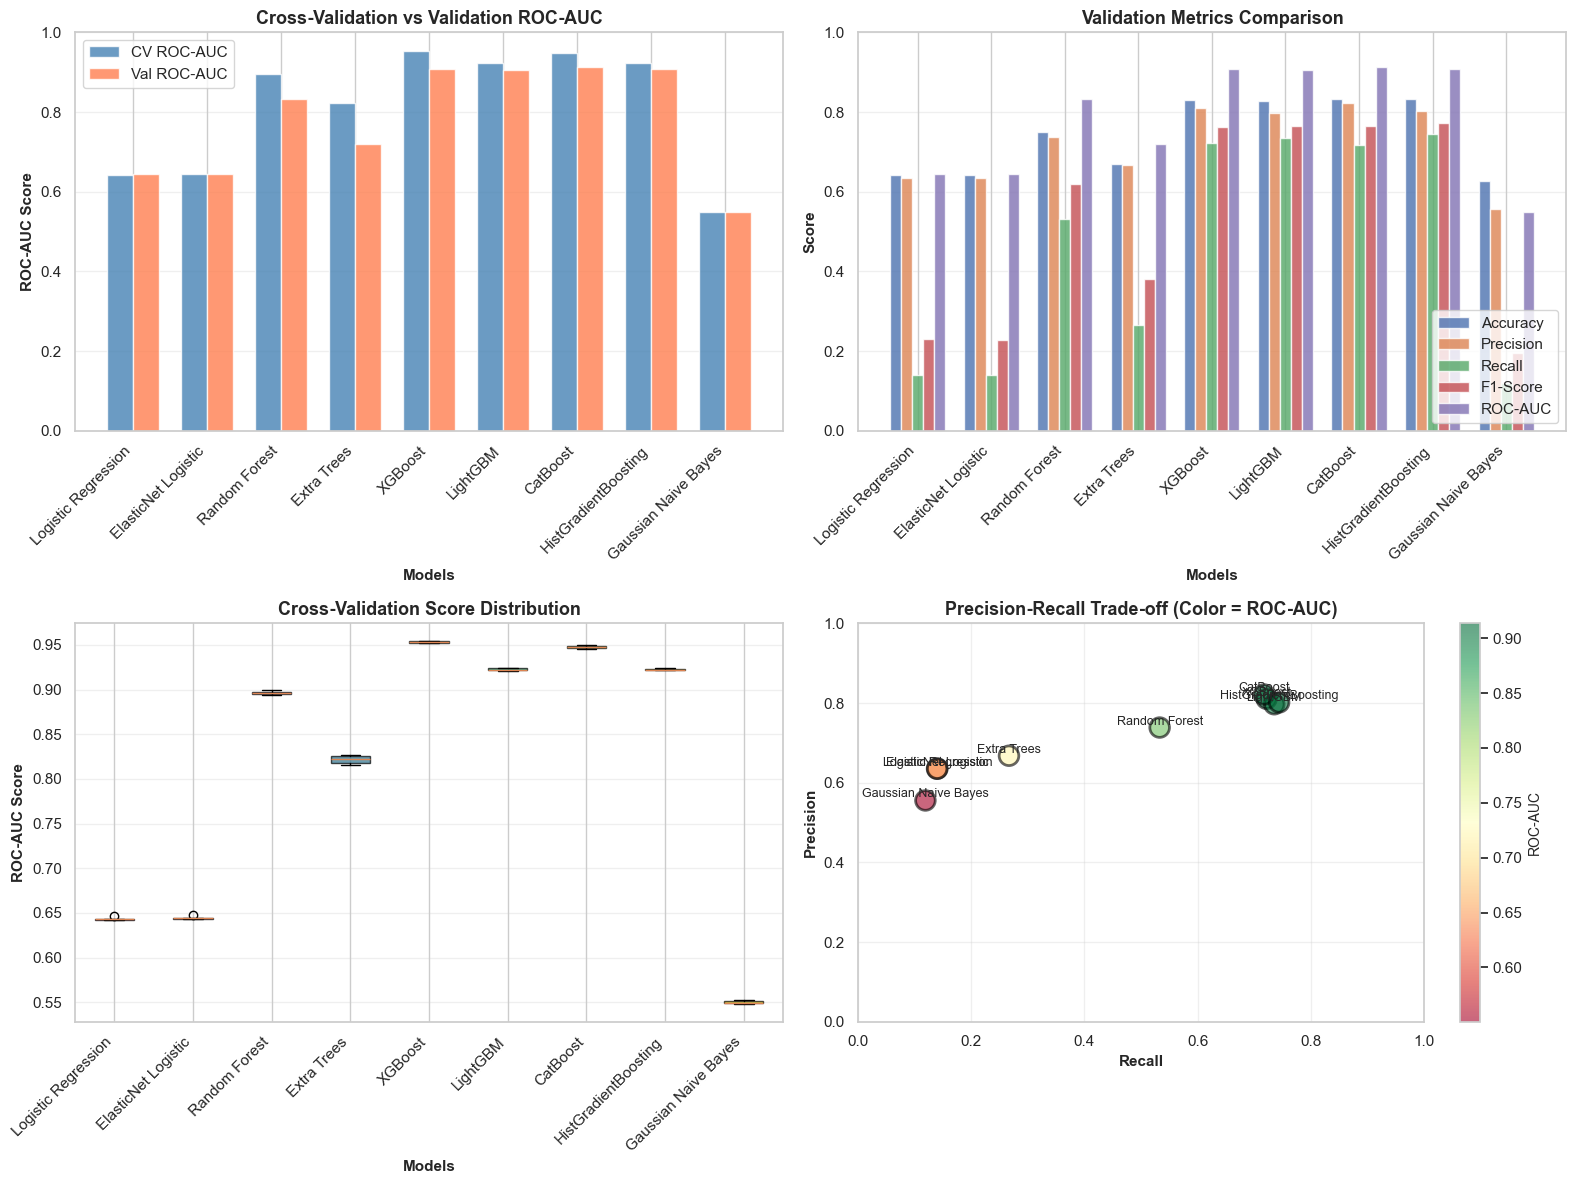

✅ Visualizations generated successfully!


In [ ]:
print("=== VISUALIZING MODEL PERFORMANCE ===\n")

# Create subplots for comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. ROC-AUC Comparison (CV vs Validation)
ax1 = axes[0, 0]
model_names = list(models.keys())
cv_aucs = [cv_results[m]['mean'] for m in model_names]
val_aucs = [val_results[m]['roc_auc'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

bars1 = ax1.bar(x - width/2, cv_aucs, width, label='CV ROC-AUC', alpha=0.8, color='steelblue')
bars2 = ax1.bar(x + width/2, val_aucs, width, label='Val ROC-AUC', alpha=0.8, color='coral')

ax1.set_xlabel('Models', fontsize=11, fontweight='bold')
ax1.set_ylabel('ROC-AUC Score', fontsize=11, fontweight='bold')
ax1.set_title('Cross-Validation vs Validation ROC-AUC', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1])

# 2. Validation Metrics Comparison
ax2 = axes[0, 1]
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

# Create a grouped bar chart
x = np.arange(len(model_names))
width = 0.15

for i, metric in enumerate(metrics):
    values = [val_results[m][metric] for m in model_names]
    ax2.bar(x + i*width, values, width, label=metric_labels[i], alpha=0.8)

ax2.set_xlabel('Models', fontsize=11, fontweight='bold')
ax2.set_ylabel('Score', fontsize=11, fontweight='bold')
ax2.set_title('Validation Metrics Comparison', fontsize=13, fontweight='bold')
ax2.set_xticks(x + width * 2)
ax2.set_xticklabels(model_names, rotation=45, ha='right')
ax2.legend(loc='lower right')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0, 1])

# 3. Cross-Validation Score Distribution (Box Plot)
ax3 = axes[1, 0]
cv_data = [cv_results[m]['scores'] for m in model_names]
bp = ax3.boxplot(cv_data, labels=model_names, patch_artist=True)

# Color the boxes
colors = plt.cm.viridis(np.linspace(0, 1, len(model_names)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax3.set_xlabel('Models', fontsize=11, fontweight='bold')
ax3.set_ylabel('ROC-AUC Score', fontsize=11, fontweight='bold')
ax3.set_title('Cross-Validation Score Distribution', fontsize=13, fontweight='bold')
ax3.set_xticklabels(model_names, rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3)

# 4. Precision-Recall Trade-off
ax4 = axes[1, 1]
precisions = [val_results[m]['precision'] for m in model_names]
recalls = [val_results[m]['recall'] for m in model_names]

scatter = ax4.scatter(recalls, precisions, s=200, c=val_aucs, cmap='RdYlGn', 
                     alpha=0.6, edgecolors='black', linewidth=2)

# Add model labels
for i, model_name in enumerate(model_names):
    ax4.annotate(model_name, (recalls[i], precisions[i]), 
                fontsize=9, ha='center', va='bottom')

ax4.set_xlabel('Recall', fontsize=11, fontweight='bold')
ax4.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax4.set_title('Precision-Recall Trade-off (Color = ROC-AUC)', fontsize=13, fontweight='bold')
ax4.grid(alpha=0.3)
ax4.set_xlim([0, 1])
ax4.set_ylim([0, 1])

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('ROC-AUC', fontsize=10)

plt.tight_layout()
plt.show()

print("✅ Visualizations generated successfully!")

🎯 === ROC CURVES FOR ALL MODELS ===



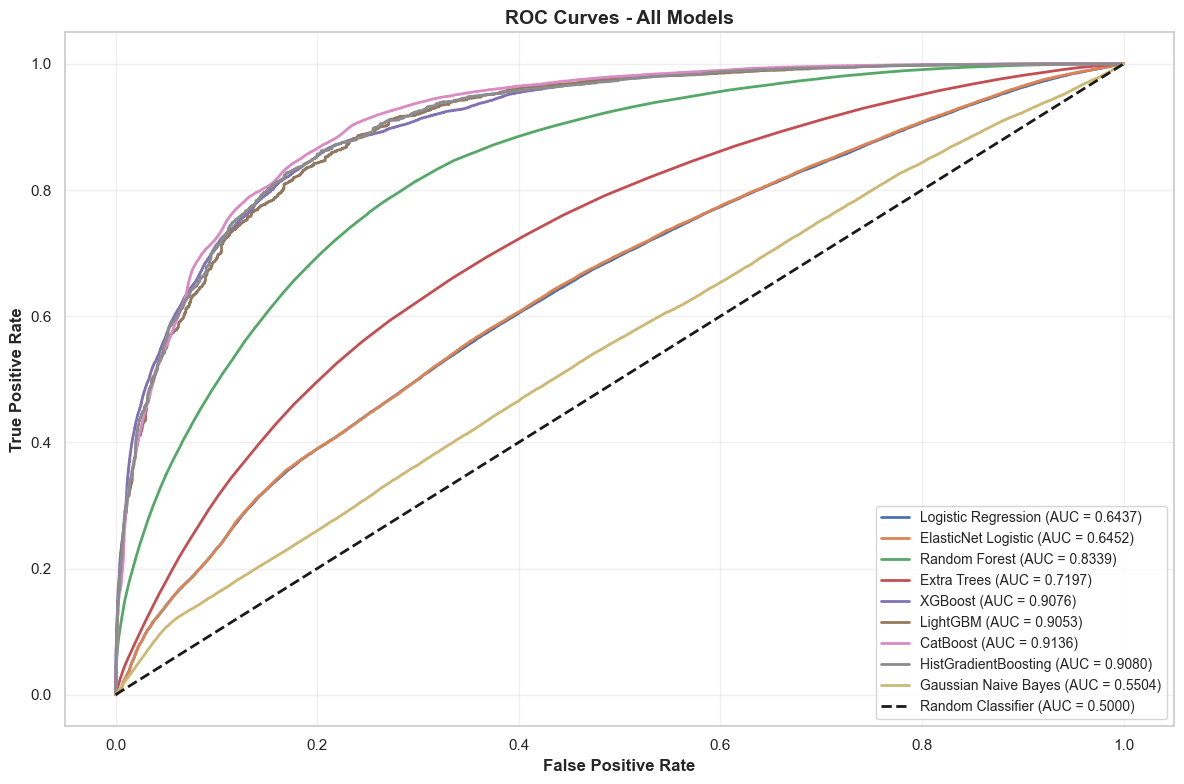

✅ ROC curves plotted successfully!


In [ ]:
print("=== ROC CURVES FOR ALL MODELS ===\n")

# Plot ROC curves for all models
plt.figure(figsize=(12, 8))

for model_name in models.keys():
    y_prob = val_results[model_name]['probabilities']
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    auc_score = val_results[model_name]['roc_auc']
    
    plt.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC = {auc_score:.4f})')

# Plot diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.5000)')

plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("ROC curves plotted successfully!")

🔍 === CONFUSION MATRICES (All Models) ===



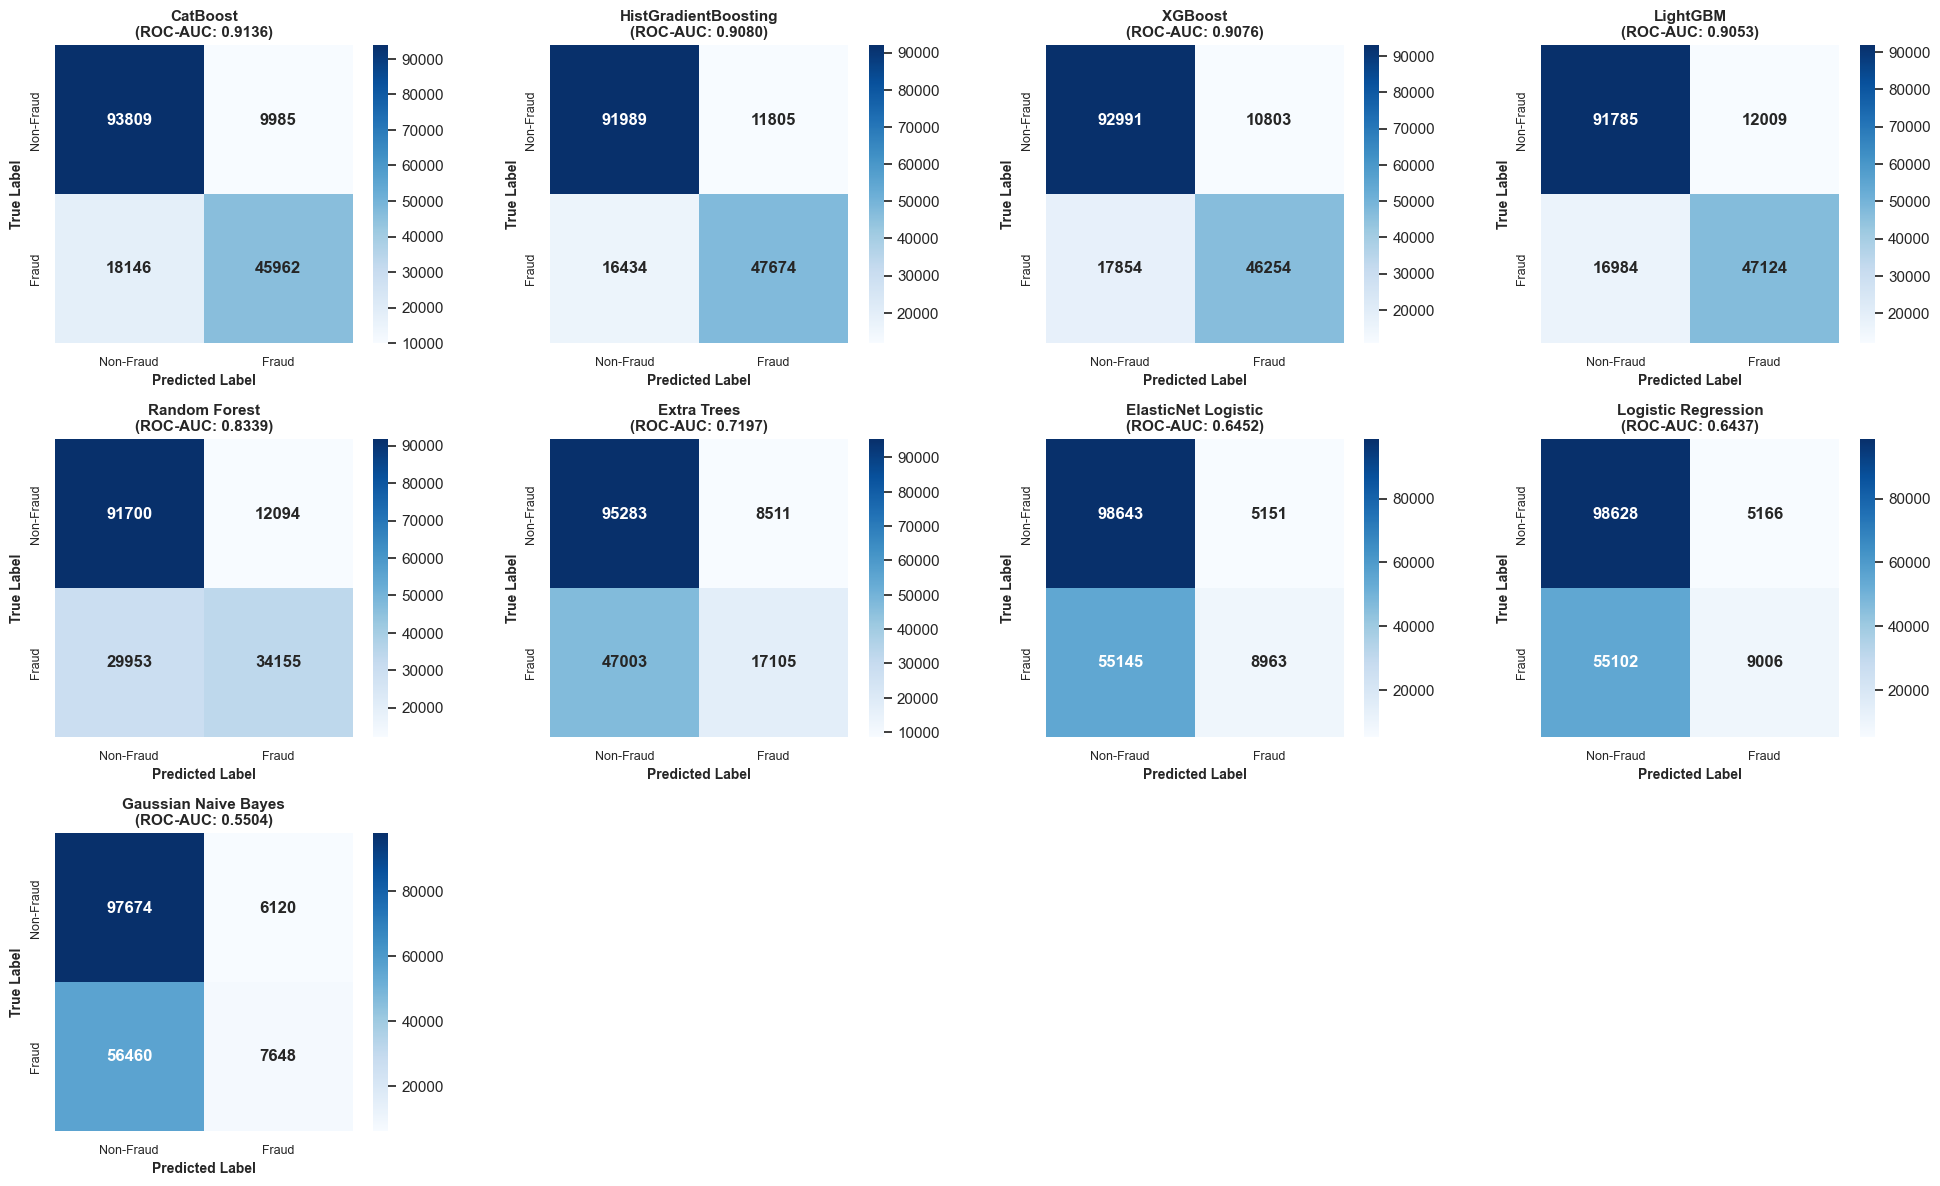

✅ Confusion matrices displayed for all 9 models!


In [ ]:
print("=== CONFUSION MATRICES (All Models) ===\n")

# Get all models sorted by validation ROC-AUC
all_models = results_df['Model'].tolist()
n_models = len(all_models)

# Create subplots with 2 rows and 4 columns to fit all 7 models
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()  # Flatten to make indexing easier

for idx, model_name in enumerate(all_models):
    y_pred = val_results[model_name]['predictions']
    cm = confusion_matrix(y_val, y_pred)
    
    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                ax=axes[idx], cbar=True, square=True,
                annot_kws={'size': 12, 'weight': 'bold'})
    
    axes[idx].set_title(f'{model_name}\n(ROC-AUC: {val_results[model_name]["roc_auc"]:.4f})', 
                       fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('True Label', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=10, fontweight='bold')
    axes[idx].set_xticklabels(['Non-Fraud', 'Fraud'], fontsize=9)
    axes[idx].set_yticklabels(['Non-Fraud', 'Fraud'], fontsize=9)

# Turn off any unused subplots
for ax in axes[n_models:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Confusion matrices displayed for all {n_models} models!")

In [ ]:
print("=== SAVING RESULTS AND MODELS ===\n")


# Create a detailed results summary
detailed_summary = []
for model_name in models.keys():
    detailed_summary.append({
        'Model': model_name,
        'CV_Mean': cv_results[model_name]['mean'],
        'CV_Std': cv_results[model_name]['std'],
        'CV_Fold_1': cv_results[model_name]['scores'][0],
        'CV_Fold_2': cv_results[model_name]['scores'][1],
        'CV_Fold_3': cv_results[model_name]['scores'][2],
        'CV_Fold_4': cv_results[model_name]['scores'][3],
        'CV_Fold_5': cv_results[model_name]['scores'][4],
        'Val_Accuracy': val_results[model_name]['accuracy'],
        'Val_Precision': val_results[model_name]['precision'],
        'Val_Recall': val_results[model_name]['recall'],
        'Val_F1': val_results[model_name]['f1'],
        'Val_ROC_AUC': val_results[model_name]['roc_auc']
    })

detailed_df = pd.DataFrame(detailed_summary)
detailed_df.to_csv("results/detailed_baseline_results.csv", index=False)
print("Detailed results saved to: results/detailed_baseline_results.csv")

print(f"\n{'='*80}")
print("BASELINE MODEL TRAINING COMPLETE!")
print(f"{'='*80}")
print(f"\nSummary:")
print(f"   • Total models trained: {len(models)}")
print(f"   • Best performing model: {best_model_name}")
print(f"   • Best validation ROC-AUC: {best_roc_auc:.4f}")
print(f"   • Best validation F1-Score: {val_results[best_model_name]['f1']:.4f}")
print(f"\nData Leakage Prevention:")
print(f"Training set: {X_train.shape[0]:,} samples (70%)")
print(f"Validation set: {X_val.shape[0]:,} samples (30%)")
print(f"Features engineered on training split only")
print(f"Scaler fit on training split only")
print(f"Physician stats from training split only")
print(f"Validation metrics are UNBIASED and RELIABLE")
print(f"\nNext Steps:")
print("   1. Perform hyperparameter tuning on top models")
print("   2. Feature importance analysis")
print("   3. Handle class imbalance (SMOTE, class weights)")
print("   4. Ensemble methods")

💾 === SAVING RESULTS AND MODELS ===

✅ Detailed results saved to: results/detailed_baseline_results.csv

🎉 BASELINE MODEL TRAINING COMPLETE!

📊 Summary:
   • Total models trained: 9
   • Best performing model: CatBoost
   • Best validation ROC-AUC: 0.9136
   • Best validation F1-Score: 0.7657

🛡️  Data Leakage Prevention:
   ✅ Training set: 390,309 samples (70%)
   ✅ Validation set: 167,902 samples (30%)
   ✅ Features engineered on training split only
   ✅ Scaler fit on training split only
   ✅ Physician stats from training split only
   ✅ Validation metrics are UNBIASED and RELIABLE

💡 Next Steps:
   1. Perform hyperparameter tuning on top models
   2. Feature importance analysis
   3. Handle class imbalance (SMOTE, class weights)
   4. Ensemble methods


For each candidate hyperparameter set (learning_rate=0.1, max_depth=5, ...):

Train an XGBoost model on each fold of the Stratified K-Fold inside the objective function.

Compute ROC-AUC on the validation fold.

Take the average ROC-AUC across folds.

Return this average to Bayesian Optimization.

BayesOpt uses that score to pick the next hyperparameter set.

In [44]:
print(X_train.head)

<bound method NDFrame.head of         admit_los_days  age_at_claim  any_chronic_condition  any_max_deductible_1068  chroniccond_alzheimer  chroniccond_cancer  chroniccond_depression  \
0             2.636499     -0.517570                      1                        1                      1                   0                       1   
1             0.749363     -0.517570                      1                        1                      1                   0                       1   
2             1.221147     -0.517570                      1                        1                      1                   0                       1   
3             2.636499     -0.287851                      1                        1                      1                   1                       0   
4             1.692931     -0.440997                      1                        1                      0                   0                       0   
...                ...           ...    

In [ ]:
!pip install --upgrade xgboost

In [ ]:
from bayes_opt import BayesianOptimization
import xgboost as xgb
import numpy as np
from sklearn.metrics import roc_auc_score

# ======================================================
# CROSS-VALIDATION FUNCTION (with early stopping)
# ======================================================
def xgb_cv(max_depth, learning_rate, n_estimators, subsample, colsample_bytree):
    max_depth = int(max_depth)
    n_estimators = int(n_estimators)

    params = {
        'max_depth': max_depth,
        'learning_rate': learning_rate,
        'n_estimators': n_estimators,
        'subsample': subsample,
        'colsample_bytree': colsample_bytree,
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'tree_method': 'hist',
        'n_jobs': -1,
        'random_state': 42,
        'early_stopping_rounds': 30
        
    }

    auc_scores = []

    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = xgb.XGBClassifier(**params)

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            verbose=False
        )

        pred_prob = model.predict_proba(X_va)[:, 1]
        auc_scores.append(roc_auc_score(y_va, pred_prob))

    return float(np.mean(auc_scores))


# ======================================================
# REDUCED SEARCH SPACE (prevents overfit + faster)
# ======================================================
pbounds = {
    'max_depth': (3, 10),            # wider than 3-7, allows deeper trees
    'learning_rate': (0.01, 0.3),    # from very small to default 0.3
    'n_estimators': (100, 600),      # more boosting rounds
    'subsample': (0.5, 1.0),         # row subsampling
    'colsample_bytree': (0.5, 1.0),  # column subsampling
}

optimizer = BayesianOptimization(
    f=xgb_cv,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

# ======================================================
# ONLY 10 ITERATIONS (5 init + 10 optimize = 15 total runs)
# ======================================================
optimizer.maximize(
    init_points=5,
    n_iter=10   # <-- You asked for 10 rounds
)

best_params = optimizer.max['params']
best_params['max_depth'] = int(best_params['max_depth'])
best_params['n_estimators'] = int(best_params['n_estimators'])

print("\nBest Hyperparameters Found:")
print(best_params)

# ======================================================
# TRAIN FINAL MODEL
# ======================================================
best_xgb = xgb.XGBClassifier(
    **best_params,
    objective='binary:logistic',
    eval_metric='auc',
    tree_method='hist',
    n_jobs=-1,
    random_state=42
)

best_xgb.fit(X_train, y_train)

|   iter    |  target   | max_depth | learni... | n_esti... | subsample | colsam... |
-------------------------------------------------------------------------------------
| 1         | 0.9495337 | 5.6217808 | 0.2857071 | 465.99697 | 0.7993292 | 0.5780093 |
| 2         | 0.8728496 | 4.0919616 | 0.0268442 | 533.08807 | 0.8005575 | 0.8540362 |
| 3         | 0.9029187 | 3.1440914 | 0.2912738 | 516.22132 | 0.6061695 | 0.5909124 |
| 4         | 0.9000842 | 4.2838315 | 0.0982302 | 362.37821 | 0.7159725 | 0.6456145 |
| 5         | 0.9348722 | 7.2829702 | 0.0504532 | 246.07232 | 0.6831809 | 0.7280349 |
| 6         | 0.9720335 | 9.8181377 | 0.2243641 | 481.28868 | 0.7612808 | 0.8705705 |
| 7         | 0.8656290 | 7.6091820 | 0.0105202 | 201.41787 | 0.8412776 | 0.5320327 |
| 8         | 0.9736171 | 9.5216429 | 0.0732399 | 480.36676 | 0.9631369 | 0.8893620 |
| 9         | 0.9540051 | 8.3496219 | 0.0411825 | 283.13227 | 0.6926465 | 0.9937090 |
| 10        | 0.8527016 | 3.0       | 0.1023721 | 310.

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8893620280873208, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='auc', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.07323992892220772,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=480, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
y_val_pred = best_xgb.predict(X_val)
y_val_prob = best_xgb.predict_proba(X_val)[:, 1]

val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred, zero_division=0)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
val_roc_auc = roc_auc_score(y_val, y_val_prob)

val_results["XGBoost_Bayesian"] = {
    'accuracy': val_accuracy,
    'precision': val_precision,
    'recall': val_recall,
    'f1': val_f1,
    'roc_auc': val_roc_auc,
    'predictions': y_val_pred,
    'probabilities': y_val_prob,
    'model': best_xgb
}

print(f"  📊 Validation Results:")
print(f"     • Accuracy:  {val_accuracy:.4f}")
print(f"     • Precision: {val_precision:.4f}")
print(f"     • Recall:    {val_recall:.4f}")
print(f"     • F1-Score:  {val_f1:.4f}")
print(f"     • ROC-AUC:   {val_roc_auc:.4f}")


  📊 Validation Results:
     • Accuracy:  0.8391
     • Precision: 0.8379
     • Recall:    0.7172
     • F1-Score:  0.7729
     • ROC-AUC:   0.9169


## Feature Selection

## Hyperparameter Tuning

## Ensemble Stacking

## Final Model